
===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====
User inputs loaded.
Analysis folder: G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis

NI continuous (absolute): 10.754773 → 4137.268407 s
NP continuous (absolute): 10.752000 → 4081.653967 s

Canonical t0 = NP stream start = 10.752000 s (absolute)
NI stream starts +0.002773 s relative to t0

===== NP ↔ NI SYNC ALIGNMENT =====
NI TTL folder: G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\experiment2\recording1\events\NI-DAQmx-109.PXIe-6341\TTL
NP TTL folder: G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\experiment2\recording1\events\Neuropix-PXI-100.ProbeA-AP\TTL
NI sync pulses (bit 3): 4127
NP sync pulses (bit 0): 4071

Linear fit: t_NI = 0.999999996 * t_NP + 0.000003719
Residuals  mean=0.0000 ms  std=0.0181 ms  max=0.0630 ms

Saved alignment metadata.

Recording

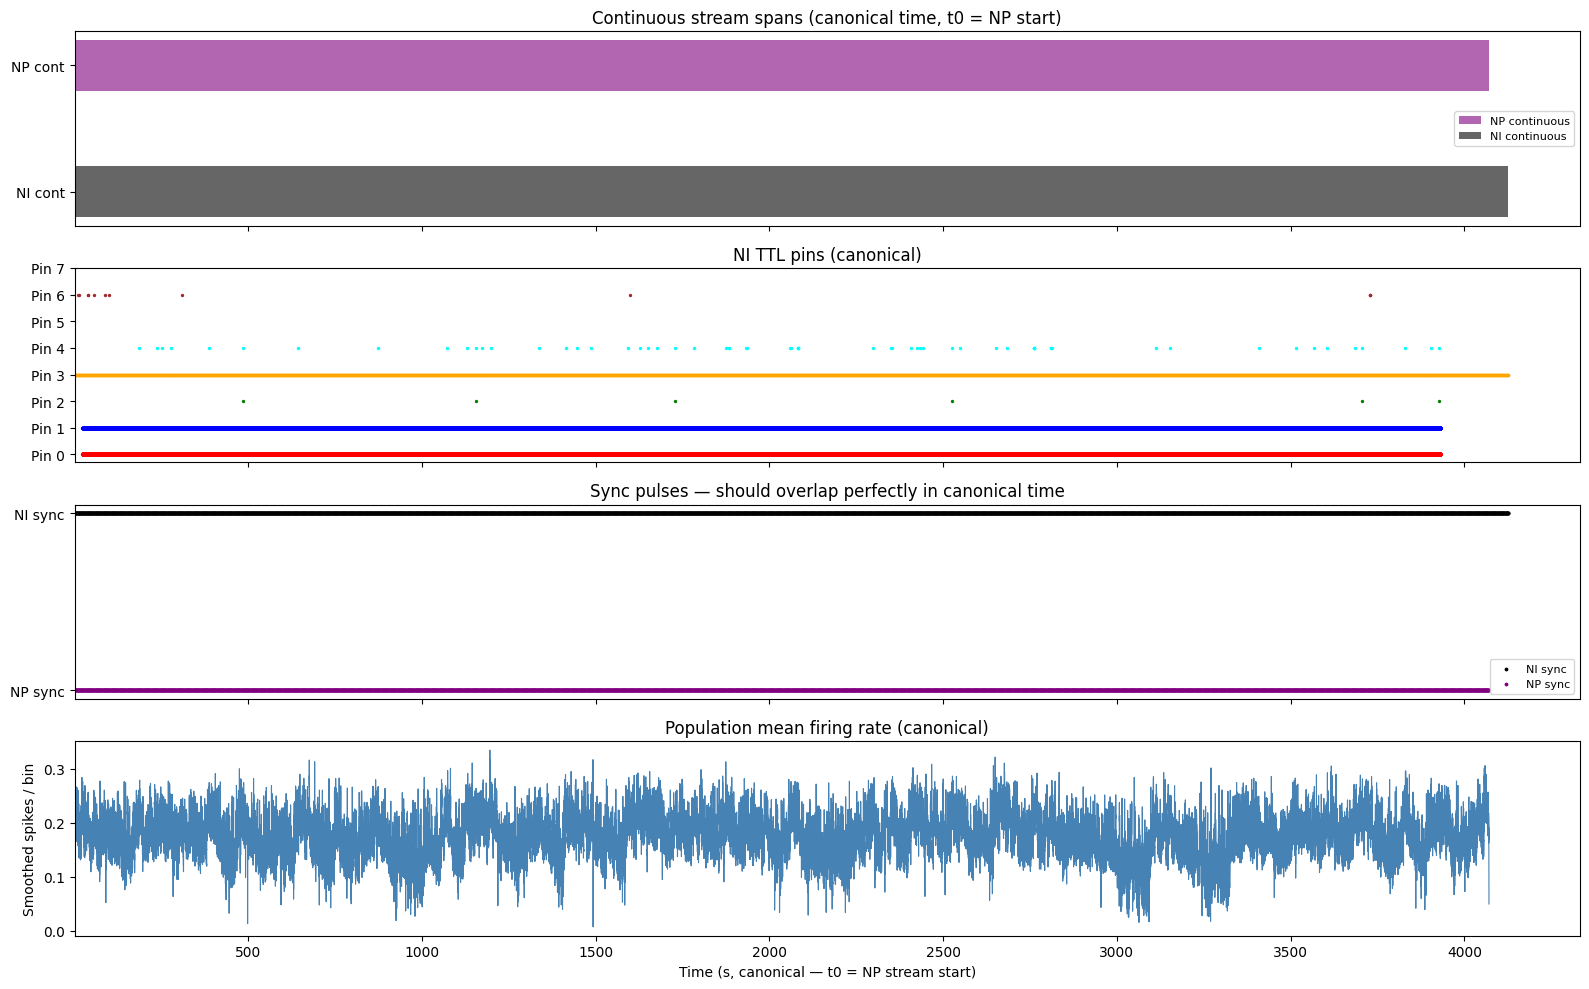

===== CELL A COMPLETE =====



In [2]:
# ============================================================
# =======================  CELL A  ============================
# ========== ROOT CELL — TTLs + QC + PORTABLE SPIKES =========
# ========== WITH NP ↔ NI CLOCK ALIGNMENT (SYNC) =============
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====")

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------


NI_TTL_FOLDER = r"G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\experiment2\recording1\events\NI-DAQmx-109.PXIe-6341\TTL"
PROBEA_PATH   = r"G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\experiment2\recording1\continuous\Neuropix-PXI-100.ProbeA-AP\kilosort4"

EXPERIMENT_NUMBER = 2

CAMERA_TTL_PIN = 0
EXPECTED_RATE_HZ = 200
MISSING_TTL_THRESHOLD = 60
MIN_BLOCK_LENGTH = 500

FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"

NI_SYNC_BIT = 3
NP_SYNC_BIT = 0

NP_SAMPLE_RATE = 30000.0

print("User inputs loaded.")

# ------------------------------------------------------------
# UNIFIED ANALYSIS FOLDER
# ------------------------------------------------------------

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        if "record node" in path.name.lower():
            return path
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find 'Record Node' folder above given path")
        path = parent

def build_analysis_folder(session_root, experiment_number):
    experiment_folders = sorted(
        [f for f in session_root.iterdir()
         if f.is_dir() and f.name.lower().startswith("experiment")],
        key=lambda p: p.name
    )
    if experiment_number < 1 or experiment_number > len(experiment_folders):
        raise RuntimeError(f"Experiment {experiment_number} not found.")
    experiment_folder = experiment_folders[experiment_number - 1]
    recording_folders = sorted(
        [f for f in experiment_folder.iterdir()
         if f.is_dir() and f.name.lower().startswith("recording")],
        key=lambda p: p.name
    )
    if not recording_folders:
        raise RuntimeError("No recording folder found.")
    recording_folder = recording_folders[0]
    session_date = session_root.parent.name
    folder_name = f"{session_date}_{experiment_folder.name}_{recording_folder.name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)
    for sf in ["qc","camera_alignment","dlc_alignment","behavior_ttls",
               "peak_detection","metadata","ttls","spikes"]:
        (analysis_folder / sf).mkdir(exist_ok=True)
    print(f"Analysis folder: {analysis_folder}")
    return analysis_folder

analysis_folder = build_analysis_folder(
    find_session_root(PROBEA_PATH), EXPERIMENT_NUMBER
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def save_incrementing(folder, base_name, array):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)
    path = folder / f"{base_name}.npy"
    if not path.exists():
        np.save(path, array)
        return path
    counter = 1
    while True:
        path = folder / f"{base_name}_{counter}.npy"
        if not path.exists():
            np.save(path, array)
            return path
        counter += 1

def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0
    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False
    rising = (~bit_prev) & bit_on
    return timestamps[rising]

# ------------------------------------------------------------
# LOAD CONTINUOUS TIMESTAMPS
# ------------------------------------------------------------

ni_ttl_folder    = Path(NI_TTL_FOLDER)
ni_device_name   = ni_ttl_folder.parent.name            # NI-DAQmx-106.PXIe-6341
recording_root   = ni_ttl_folder.parents[2]             # .../experiment2/recording1
ni_cont_folder   = recording_root / "continuous" / ni_device_name
probe_cont_folder = Path(PROBEA_PATH).parent            # .../Neuropix-PXI-107.ProbeA

ni_cont_timestamps = np.load(ni_cont_folder   / "timestamps.npy")
np_cont_timestamps = np.load(probe_cont_folder / "timestamps.npy")

ni_start_abs = float(ni_cont_timestamps[0])
ni_end_abs   = float(ni_cont_timestamps[-1])
np_start_abs = float(np_cont_timestamps[0])
np_end_abs   = float(np_cont_timestamps[-1])

print(f"\nNI continuous (absolute): {ni_start_abs:.6f} → {ni_end_abs:.6f} s")
print(f"NP continuous (absolute): {np_start_abs:.6f} → {np_end_abs:.6f} s")

# ============================================================
# CANONICAL TIMEBASE DECISION
# ============================================================
# We use the NP continuous start as t0 (our ground truth).
# Everything — spikes, TTLs, DLC — will be expressed as seconds
# elapsed since the NP recording began.
#
# Why NP and not NI?
#   - Kilosort spike_times.npy is in NP samples from NP stream start.
#   - The NP stream is always the longest / most complete signal.
#   - All other signals get mapped into this frame.
# ============================================================

t0 = np_start_abs   # canonical zero = NP stream start (absolute clock)

print(f"\nCanonical t0 = NP stream start = {t0:.6f} s (absolute)")
print(f"NI stream starts {ni_start_abs - t0:+.6f} s relative to t0")
# Positive → NI started after NP (common if NP armed first)

# ------------------------------------------------------------
# SYNC PULSE ALIGNMENT: verify NP↔NI are on same clock
# ------------------------------------------------------------

print("\n===== NP ↔ NI SYNC ALIGNMENT =====")

timestamps_ni_ttl = np.load(ni_ttl_folder / "timestamps.npy")
full_words_ni     = np.load(ni_ttl_folder / "full_words.npy")

# Derive NP TTL folder from PROBEA_PATH, not hardcoded.
np_device_name    = probe_cont_folder.name                # Neuropix-PXI-XXX.ProbeA
np_recording_root = probe_cont_folder.parents[1]          # .../experimentN/recording1
np_ttl_folder     = np_recording_root / "events" / np_device_name / "TTL"

print(f"NI TTL folder: {ni_ttl_folder}")
print(f"NP TTL folder: {np_ttl_folder}")

if not np_ttl_folder.exists():
    raise FileNotFoundError(
        f"NP TTL folder not found:\n  {np_ttl_folder}\n"
        f"Check that PROBEA_PATH points to the correct kilosort4 folder."
    )

timestamps_np_ttl = np.load(np_ttl_folder / "timestamps.npy")
full_words_np     = np.load(np_ttl_folder / "full_words.npy")

sync_times_ni_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, NI_SYNC_BIT)
sync_times_np_abs = extract_rising_edges(full_words_np, timestamps_np_ttl, NP_SYNC_BIT)

print(f"NI sync pulses (bit {NI_SYNC_BIT}): {len(sync_times_ni_abs)}")
print(f"NP sync pulses (bit {NP_SYNC_BIT}): {len(sync_times_np_abs)}")

if len(sync_times_ni_abs) == 0:
    raise RuntimeError("No NI sync pulses found.")
if len(sync_times_np_abs) == 0:
    raise RuntimeError("No NP sync pulses found.")

n_common = min(len(sync_times_np_abs), len(sync_times_ni_abs))
sync_np  = sync_times_np_abs[:n_common]
sync_ni  = sync_times_ni_abs[:n_common]

A_mat = np.vstack([sync_np, np.ones_like(sync_np)]).T
a_fit, b_fit = np.linalg.lstsq(A_mat, sync_ni, rcond=None)[0]
residuals = sync_ni - (a_fit * sync_np + b_fit)

print(f"\nLinear fit: t_NI = {a_fit:.9f} * t_NP + {b_fit:.9f}")
print(f"Residuals  mean={np.mean(residuals)*1000:.4f} ms  "
      f"std={np.std(residuals)*1000:.4f} ms  "
      f"max={np.max(np.abs(residuals))*1000:.4f} ms")

# With a≈1 and b≈0 (same clock), the fit confirms the two streams share
# the OpenEphys master clock.  We still apply it for correctness in case
# there is any tiny drift.

# Save alignment metadata
align_meta = {
    "np_to_ni_a": float(a_fit),
    "np_to_ni_b": float(b_fit),
    "n_pulses": int(n_common),
    "residual_mean_s": float(np.mean(residuals)),
    "residual_std_s":  float(np.std(residuals)),
    "residual_max_abs_s": float(np.max(np.abs(residuals))),
    "ni_sync_bit": int(NI_SYNC_BIT),
    "np_sync_bit": int(NP_SYNC_BIT),
    "t0_abs": float(t0),
    "ni_start_abs": float(ni_start_abs),
    "np_start_abs": float(np_start_abs),
    "ni_start_rel": float(ni_start_abs - t0),
    "ni_end_rel":   float(ni_end_abs   - t0),
    "np_start_rel": 0.0,
    "np_end_rel":   float(np_end_abs   - t0),
}
with open(analysis_folder / "metadata" / "np_ni_alignment.json", "w") as f:
    json.dump(align_meta, f, indent=2)
print(f"\nSaved alignment metadata.")

# ============================================================
# UNIFIED CONVERSION FUNCTIONS
# ============================================================
# All downstream code should use these — never subtract t0 manually.

def np_samples_to_canonical(samples):
    """Kilosort spike_times (NP samples) → canonical seconds."""
    # samples / sample_rate  → seconds from NP stream start (already = t0)
    # No further offset needed because t0 IS np_start_abs and
    # OpenEphys sample indices start at the stream start.
    return samples / NP_SAMPLE_RATE

def np_abs_to_canonical(t_np_abs):
    """NP absolute time → canonical seconds."""
    return t_np_abs - t0

def ni_abs_to_canonical(t_ni_abs):
    """NI absolute time → canonical seconds."""
    return t_ni_abs - t0

# Canonical duration = full NP recording
recording_duration = float(np_end_abs - t0)
print(f"\nRecording duration (canonical): {recording_duration:.3f} s")

# ============================================================
# CRITICAL DIAGNOSTIC: verify spike time anchor
# ============================================================
# Load spike_times.npy and check that the first and last spikes
# fall within [0, recording_duration].  If they fall within
# [-ni_start_rel, recording_duration - ni_start_rel] instead,
# that means Kilosort spike_times are in NI-absolute samples,
# and you need to subtract the NP stream start offset.
# ============================================================

spike_times_raw = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
spike_times_sec_raw = spike_times_raw / NP_SAMPLE_RATE

ni_start_rel = ni_start_abs - t0   # typically a small positive number

print(f"\n===== SPIKE TIME ANCHOR DIAGNOSTIC =====")
print(f"NI stream offset from NP start: {ni_start_rel:+.6f} s")
print(f"First 5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[:5]}")
print(f"Last  5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[-5:]}")
print(f"Expected canonical range: 0 → {recording_duration:.3f} s")
print(f"If spikes appear in range {-ni_start_rel:.3f} → "
      f"{recording_duration - ni_start_rel:.3f} s")
print(f"  → spike_times are anchored to NI start, not NP start.")
print(f"  → You need: spike_canonical = spikes_sec - {ni_start_rel:.6f}")
print(f"If spikes appear in range 0 → {recording_duration:.3f} s")
print(f"  → spike_times are anchored to NP start (correct, no adjustment).")

# Auto-detect anchor and apply correct conversion
spike_min = float(spike_times_sec_raw.min())
spike_max = float(spike_times_sec_raw.max())

if abs(spike_min) < 5.0 and spike_max <= recording_duration + 5.0:
    print("\n→ AUTO-DETECTED: spikes anchored to NP start. No offset needed.")
    spike_anchor_offset = 0.0
elif abs(spike_min - ni_start_rel) < 5.0:
    print(f"\n→ AUTO-DETECTED: spikes anchored to NI start. "
          f"Applying offset of -{ni_start_rel:.6f} s.")
    spike_anchor_offset = ni_start_rel
else:
    print(f"\n→ WARNING: spike anchor unclear. "
          f"spike_min={spike_min:.3f}, ni_start_rel={ni_start_rel:.6f}. "
          f"Defaulting to 0 offset — PLEASE VERIFY MANUALLY.")
    spike_anchor_offset = 0.0

print(f"spike_anchor_offset = {spike_anchor_offset:.6f} s")

def spikes_to_canonical(spike_samples):
    """Full pipeline: NP samples → canonical seconds."""
    return spike_samples / NP_SAMPLE_RATE - spike_anchor_offset

# ============================================================
# NI TTL EXTRACTION → canonical time
# ============================================================

print("\n===== EXTRACTING NI TTLs → CANONICAL TIME =====")

ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}   # canonical seconds

for pin in range(8):
    ttls_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, pin)
    ttls_can = ni_abs_to_canonical(ttls_abs)
    all_pin_ttls[pin] = ttls_can
    save_incrementing(ttls_dir, f"TTL_Pin_{pin}", ttls_can)
    print(f"  Pin {pin}: {len(ttls_can)} TTLs", end="")
    if len(ttls_can):
        print(f"  range {ttls_can[0]:.3f} → {ttls_can[-1]:.3f} s")
    else:
        print()

ni_meta = {
    "canonical_t0_is": "NP stream start (np_start_abs)",
    "t0_abs": float(t0),
    "ni_start_canonical": float(ni_start_abs - t0),
    "ni_end_canonical":   float(ni_end_abs   - t0),
    "np_start_canonical": 0.0,
    "np_end_canonical":   float(np_end_abs   - t0),
    "recording_duration": float(recording_duration),
    "camera_ttl_pin": int(CAMERA_TTL_PIN),
    "expected_rate_hz": EXPECTED_RATE_HZ,
    "spike_anchor_offset_s": float(spike_anchor_offset),
}
with open(analysis_folder / "metadata" / "ttl_metadata.json", "w") as f:
    json.dump(ni_meta, f, indent=2)
print("Saved TTL metadata.")

# ============================================================
# TTL BLOCK DETECTION
# ============================================================

print("\n===== TTL BLOCK DETECTOR =====")

rising_times = all_pin_ttls[CAMERA_TTL_PIN]
print(f"Camera pin {CAMERA_TTL_PIN}: {len(rising_times)} rising edges")

ipi           = np.diff(rising_times)
expected_ipi  = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD
gap_indices   = np.where(ipi > gap_threshold)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

ttl_blocks = []
block_info = []
cam_align_dir = analysis_folder / "camera_alignment"

saved_block_idx = 0  # consecutive numbering for kept blocks
for b_idx, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1
    if block_len < MIN_BLOCK_LENGTH:
        print(f"  Skipping block {b_idx} (too short: {block_len})")
        continue
    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)
    info = {
        "block_index": saved_block_idx,
        "raw_block_index": b_idx,
        "n_ttls": int(block_len),
        "start_canonical": float(block_times[0]),
        "end_canonical":   float(block_times[-1]),
        "duration_s":      float(block_times[-1] - block_times[0]),
    }
    block_info.append(info)
    save_incrementing(cam_align_dir, f"ttl_times_block{saved_block_idx}", block_times)
    print(f"  Block {saved_block_idx} (raw {b_idx}): {block_len} TTLs, "
          f"{block_times[0]:.3f} → {block_times[-1]:.3f} s (canonical)")
    saved_block_idx += 1

with open(analysis_folder / "metadata" / "block_info.json", "w") as f:
    json.dump(block_info, f, indent=2)

# ============================================================
# QC: FIRING-RATE MATRIX
# ============================================================

print("\n===== QC: FIRING-RATE MATRIX =====")

qc_dir        = analysis_folder / "qc"
spikes_dir    = analysis_folder / "spikes"

rate_path          = qc_dir / "rate_matrix.npy"
good_units_path    = qc_dir / "good_units.npy"
centers_path       = qc_dir / "centers.npy"
duration_path      = qc_dir / "recording_duration.json"
noise_units_path   = qc_dir / "noise_units.npy"
noise_rate_path    = qc_dir / "noise_rate_matrix.npy"
spike_anchor_path  = qc_dir / "spike_anchor_offset.json"

all_qc_exist = all(p.exists() for p in [
    rate_path, good_units_path, centers_path, duration_path,
    noise_units_path, noise_rate_path
])

if all_qc_exist:
    print("QC files already exist — skipping.")
else:
    print("Computing QC...")

    spike_times_raw  = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
    spike_clusters   = np.load(Path(PROBEA_PATH) / "spike_clusters.npy").flatten()
    spike_times_can  = spikes_to_canonical(spike_times_raw)  # canonical seconds

    print(f"Spike time canonical range: "
          f"{spike_times_can.min():.3f} → {spike_times_can.max():.3f} s")
    print(f"Recording duration:          0.000 → {recording_duration:.3f} s")

    if spike_times_can.max() < recording_duration * 0.9:
        print("WARNING: spikes end well before recording end — "
              "check spike_anchor_offset!")
    if spike_times_can.min() < -1.0:
        print("WARNING: spikes start before t=0 — check spike_anchor_offset!")

    df_info    = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
    good_units = df_info[df_info["group"] == "good"]["id"].values
    np.save(good_units_path, good_units)
    print(f"Good units: {len(good_units)}")

    for unit in good_units:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"unit_{unit}.npy", unit_spikes)

# Sample noise units matched to the number of good units
# (so downstream noise-vs-real comparisons have equal sample sizes)
    noise_units_all = df_info[df_info["group"] == "noise"]["id"].values
    print(f"Total noise units available: {len(noise_units_all)}")

# Filter noise units by minimum firing rate, same way good units would be
# filtered downstream. This ensures the noise pool we sample from is
# comparable in firing-rate distribution to the good pool.
    noise_rates = np.array([
        (spike_clusters == u).sum() / recording_duration
        for u in noise_units_all
    ])
    NOISE_MIN_RATE_HZ = 0.5  # matches a permissive floor; tightened downstream
    eligible_noise = noise_units_all[noise_rates >= NOISE_MIN_RATE_HZ]
    print(f"Noise units with ≥{NOISE_MIN_RATE_HZ} Hz: {len(eligible_noise)}")

# Sample N_target noise units matched to good unit count
    N_target = len(good_units)
    np.random.seed(0)
    if len(eligible_noise) >= N_target:
        sampled_noise = np.random.choice(eligible_noise, size=N_target, replace=False)
        print(f"Sampled {N_target} noise units (matched to good unit count).")
    else:
        sampled_noise = eligible_noise
        print(f"WARNING: only {len(eligible_noise)} eligible noise units available "
              f"(wanted {N_target}). Using all available.")

    np.save(noise_units_path, sampled_noise)

    for unit in sampled_noise:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"noise_unit_{unit}.npy", unit_spikes)
    print(f"Saved {len(sampled_noise)} noise unit spike trains to disk.")

    # Save spike anchor for downstream cells
    with open(spike_anchor_path, "w") as f:
        json.dump({"spike_anchor_offset_s": float(spike_anchor_offset),
                   "t0_abs": float(t0)}, f, indent=2)

    # Time bins over full NP recording
    bin_size = 0.02
    bins    = np.arange(0, recording_duration + bin_size, bin_size)
    centers = bins[:-1] + bin_size / 2
    np.save(centers_path, centers)
    with open(duration_path, "w") as f:
        json.dump({"recording_duration": recording_duration,
                   "t0_abs": float(t0)}, f, indent=2)

    # Rate matrices
    def make_rate_matrix(unit_list, label):
        mat = np.zeros((len(unit_list), len(centers)), float)
        for i, unit in enumerate(unit_list):
            spk = spike_times_can[spike_clusters == unit]
            h, _ = np.histogram(spk, bins=bins)
            mat[i] = gaussian_filter1d(h.astype(float), sigma=2)
        return mat

    rate_matrix       = make_rate_matrix(good_units,   "good")
    noise_rate_matrix = make_rate_matrix(sampled_noise,"noise")
    np.save(rate_path,       rate_matrix)
    np.save(noise_rate_path, noise_rate_matrix)
    print(f"Saved rate_matrix {rate_matrix.shape}")
    print(f"Saved noise_rate_matrix {noise_rate_matrix.shape}")

# ============================================================
# DIAGNOSTIC PLOT — canonical timeline
# ============================================================

print("\n===== CANONICAL TIMELINE DIAGNOSTIC =====")

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# Row 0: NP and NI continuous spans
for ax in axes[:1]:
    ax.barh(1, recording_duration,       left=0,
            height=0.4, color='purple', alpha=0.6, label="NP continuous")
    ax.barh(0, ni_end_abs - t0,          left=ni_start_abs - t0,
            height=0.4, color='black',  alpha=0.6, label="NI continuous")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["NI cont", "NP cont"])
    ax.legend(fontsize=8)
    ax.set_title("Continuous stream spans (canonical time, t0 = NP start)")

# Row 1: TTL pins
colors8 = ['red','blue','green','orange','cyan','magenta','brown','gray']
ax1 = axes[1]
for pin in range(8):
    tt = all_pin_ttls[pin]
    ax1.scatter(tt, np.full_like(tt, pin), s=2, color=colors8[pin],
                label=f"Pin {pin}")
ax1.set_yticks(range(8))
ax1.set_yticklabels([f"Pin {p}" for p in range(8)])
ax1.set_title("NI TTL pins (canonical)")

# Row 2: sync pulses overlap check
ax2 = axes[2]
sync_ni_can  = ni_abs_to_canonical(sync_times_ni_abs)
sync_np_can  = np_abs_to_canonical(sync_times_np_abs)
ax2.scatter(sync_ni_can, np.ones_like(sync_ni_can)*1,
            s=3, color='black', label="NI sync")
ax2.scatter(sync_np_can, np.ones_like(sync_np_can)*0,
            s=3, color='purple', label="NP sync")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["NP sync","NI sync"])
ax2.set_title("Sync pulses — should overlap perfectly in canonical time")
ax2.legend(fontsize=8)

# Row 3: spike density
ax3 = axes[3]
if centers_path.exists():
    centers_saved = np.load(centers_path)
    rm = np.load(rate_path)
    ax3.plot(centers_saved, rm.mean(axis=0), color='steelblue', lw=0.8)
    ax3.set_title("Population mean firing rate (canonical)")
    ax3.set_ylabel("Smoothed spikes / bin")

axes[-1].set_xlabel("Time (s, canonical — t0 = NP stream start)")
plt.tight_layout()
plt.show()

print("===== CELL A COMPLETE =====\n")

In [4]:
# ============================================================
# CELL B — FRAME ALIGNMENT (FLIR/PySpin) — FINAL VERSION
# ============================================================
# Replaces the old Basler per-frame-file Cell B.
#
# FLIR acquisition produces per session folder:
#   {view}_counters.csv  — columns: counter, saved, host_ns, chunk_ts
#     counter  : camera hardware FrameID (free-running, NOT reset each session)
#     saved    : 1 if frame written to .raw file, 0 if dropped
#     host_ns  : PC clock time of retrieval (nanoseconds, for diagnostics only)
#     chunk_ts : camera internal hardware timestamp (nanoseconds, ~5ns res)
#
# Alignment method:
#   - Cell A detected N rising edges on CAMERA_TTL_PIN → N trigger pulses
#   - TTL block i has ttl_times_block[i] = canonical time of trigger i
#   - counter[row] - counter[0] = trigger index within the block
#   - saved frames (saved==1) get canonical_time = ttl_times_block[trigger_index]
#   - dropped frames (saved==0) are excluded; their trigger slots just have no frame
#
# Outputs to analysis_folder/camera_alignment/:
#   frame_canonical_times_block{N}.npy  — canonical time for each SAVED frame
#   frame_cnt_block{N}.npy              — trigger index for each saved frame
#   ttl_times_block{N}.npy              — full TTL block (already saved by Cell A,
#                                         but Cell C needs the path — see note)
#
# Outputs to analysis_folder/metadata/:
#   frame_alignment.json  — per-block summary Cell C reads
#
# REQUIREMENTS:
#   - Run Cell A first (provides analysis_folder, ttl_blocks, block_info)
#   - Counters CSV must be accessible from this machine
#   - analysis_folder must be accessible (same machine or network share)
#
# PORTABLE AFTER THIS CELL:
#   Everything from Cell C onward only needs analysis_folder.
# ============================================================

import numpy as np
import pandas as pd
import json
from pathlib import Path

print("\n===== CELL B — FRAME ALIGNMENT (FLIR) =====")

required_vars = ["analysis_folder", "ttl_blocks", "block_info"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"'{v}' missing — run Cell A first.")

# ============================================================
# USER EDIT — one entry per CAMERA TTL block
# ============================================================
# Map block_index → (counters_csv_path, camera_view_name)
# Block 0 is usually the short pre-session block — if you didn't
# record camera data for it, set its csv to None to skip alignment.
# Cell C will still have a session entry for it (0 frames).
#
# For freely moving sessions there is typically one real block (block 1).
# block_index matches what Cell A called them (0-indexed by TTL gaps).

CAMERA_BLOCKS = {
    0: None,                                   # short pre-session block — skip
    1: (r"E:\DATA\16092026-3\paw_angled_counters.csv",  "paw_angled"),
}
# ============================================================

cam_align_dir = analysis_folder / "camera_alignment"
cam_align_dir.mkdir(exist_ok=True)
metadata_dir  = analysis_folder / "metadata"
metadata_dir.mkdir(exist_ok=True)

# Validate block count
n_blocks = len(ttl_blocks)
if set(CAMERA_BLOCKS.keys()) != set(range(n_blocks)):
    raise ValueError(
        f"CAMERA_BLOCKS keys must be {set(range(n_blocks))} "
        f"(one entry per TTL block, even if None). Got: {set(CAMERA_BLOCKS.keys())}"
    )

frame_alignment = {}   # filled per block, saved as frame_alignment.json

for block_index, ttl_times_block in enumerate(ttl_blocks):

    print(f"\n--- Block {block_index} ---")
    n_ttls = len(ttl_times_block)
    print(f"  TTLs in block: {n_ttls}  "
          f"({ttl_times_block[0]:.3f} → {ttl_times_block[-1]:.3f} s canonical)")

    cfg = CAMERA_BLOCKS[block_index]

    # ── Skipped block ──────────────────────────────────────────────────────
    if cfg is None:
        print(f"  Skipping (no camera data for this block).")
        frame_alignment[str(block_index)] = {
            "skipped":       True,
            "n_ttls":        int(n_ttls),
            "n_saved_frames": 0,
            "note":          "No camera CSV provided — block skipped."
        }
        # Write stub arrays so Cell C paths don't crash
        stub = np.array([], dtype=np.int64)
        np.save(cam_align_dir / f"frame_cnt_block{block_index}.npy", stub)
        np.save(cam_align_dir / f"frame_canonical_times_block{block_index}.npy",
                stub.astype(np.float64))
        continue

    # ── Real block ────────────────────────────────────────────────────────
    counters_csv, camera_view = cfg

    if not Path(counters_csv).exists():
        raise FileNotFoundError(
            f"Block {block_index}: counters CSV not found: {counters_csv}\n"
            f"If this machine doesn't have the camera data, copy the CSV "
            f"here or run Cell B on the camera PC."
        )

    print(f"  Camera view: {camera_view}")
    print(f"  Loading: {counters_csv}")

    df = pd.read_csv(counters_csv)

    # Validate columns
    required_cols = {"counter", "saved"}
    missing = required_cols - set(df.columns)
    if missing:
        raise RuntimeError(
            f"Block {block_index}: counters CSV missing columns: {missing}. "
            f"Found: {list(df.columns)}"
        )

    counter_arr = df["counter"].to_numpy(dtype=np.int64)
    saved_arr   = df["saved"].to_numpy(dtype=np.int64)

    n_rows      = len(df)
    n_saved     = int((saved_arr == 1).sum())
    n_dropped   = n_rows - n_saved
    first_ctr   = int(counter_arr[0])
    last_ctr    = int(counter_arr[-1])
    ctr_span    = last_ctr - first_ctr + 1   # total triggers received by camera

    print(f"  CSV rows:      {n_rows}")
    print(f"  Saved frames:  {n_saved}")
    print(f"  Dropped:       {n_dropped}  ({100*n_dropped/n_rows:.3f}%)")
    print(f"  Counter range: {first_ctr} → {last_ctr}  (span={ctr_span})")

    # ── Sanity: counter span vs TTL block ─────────────────────────────────
    if ctr_span > n_ttls:
        raise RuntimeError(
            f"Block {block_index}: counter span ({ctr_span}) exceeds TTL count "
            f"({n_ttls}). Camera received more triggers than TTL detector found. "
            f"Check block boundaries in Cell A or that CAMERA_BLOCK_INDEX is correct."
        )

    trailing = n_ttls - ctr_span
    print(f"  Trailing TTLs (after camera stopped): {trailing}  "
          f"(~{ttl_times_block[-1] - ttl_times_block[ctr_span-1]:.2f} s)")
    if trailing > n_ttls * 0.10:
        print(f"  WARNING: >10% trailing TTLs — did the camera stop well "
              f"before OpenEphys? Check recording end times.")

    # ── Core mapping ──────────────────────────────────────────────────────
    # trigger_index[i] = which TTL pulse row i in the CSV corresponds to
    trigger_index = counter_arr - first_ctr   # shape (n_rows,)

    # Only keep saved frames
    saved_mask     = saved_arr == 1
    saved_triggers = trigger_index[saved_mask]   # shape (n_saved,)

    # Look up canonical times
    frame_canonical_times = ttl_times_block[saved_triggers]   # shape (n_saved,)

    # Validate: must be strictly increasing (guaranteed if counters are
    # monotone, but check anyway)
    if not np.all(np.diff(frame_canonical_times) > 0):
        raise RuntimeError(
            f"Block {block_index}: canonical times are not strictly increasing. "
            f"Counter values are non-monotone or there is a block mismatch."
        )

    # ── Interval QC ──────────────────────────────────────────────────────
    intervals_ms = np.diff(frame_canonical_times) * 1000.0
    mean_iv  = float(intervals_ms.mean())
    std_iv   = float(intervals_ms.std())
    min_iv   = float(intervals_ms.min())
    max_iv   = float(intervals_ms.max())
    print(f"\n  Frame interval stats (saved frames):")
    print(f"    Mean: {mean_iv:.4f} ms  (expected 5.0000 ms at 200 Hz)")
    print(f"    Std:  {std_iv:.5f} ms")
    print(f"    Min:  {min_iv:.4f} ms    Max: {max_iv:.4f} ms")

    large_gaps = np.where(intervals_ms > 15.0)[0]  # >3× expected interval
    if len(large_gaps) == 0:
        print(f"    No large gaps — frame sequence is clean.")
    else:
        print(f"    Large gaps (>15ms): {len(large_gaps)}")
        for gi in large_gaps[:5]:
            print(f"      gap at saved-frame {gi}: {intervals_ms[gi]:.1f} ms")
        if len(large_gaps) > 5:
            print(f"      ... and {len(large_gaps)-5} more")

    # ── Save arrays ───────────────────────────────────────────────────────
    # These names match exactly what Cell C expects
    path_canonical = cam_align_dir / f"frame_canonical_times_block{block_index}.npy"
    path_cnt       = cam_align_dir / f"frame_cnt_block{block_index}.npy"

    np.save(path_canonical, frame_canonical_times)
    np.save(path_cnt,       saved_triggers)

    print(f"\n  Saved frame_canonical_times_block{block_index}.npy  "
          f"({n_saved} entries)")
    print(f"  Saved frame_cnt_block{block_index}.npy")
    print(f"  Canonical range: {frame_canonical_times[0]:.3f} → "
          f"{frame_canonical_times[-1]:.3f} s")

    # ── Also save per-view named files (QC / backward compat) ─────────────
    np.save(cam_align_dir / f"{camera_view}_frame_times.npy",
            frame_canonical_times)

    frame_alignment[str(block_index)] = {
        "skipped":          False,
        "camera_view":      camera_view,
        "counters_csv":     str(counters_csv),
        "n_ttls":           int(n_ttls),
        "n_saved_frames":   n_saved,
        "n_dropped_frames": n_dropped,
        "loss_rate_pct":    round(100.0 * n_dropped / n_rows, 4),
        "first_counter":    int(first_ctr),
        "last_counter":     int(last_ctr),
        "frame_time_range_s": [
            float(frame_canonical_times[0]),
            float(frame_canonical_times[-1])
        ],
        "mean_interval_ms": round(mean_iv, 4),
        "std_interval_ms":  round(std_iv, 5),
    }

# ── Save frame_alignment.json ─────────────────────────────────────────────
fa_path = metadata_dir / "frame_alignment.json"
with open(fa_path, "w") as f:
    json.dump(frame_alignment, f, indent=2)
print(f"\nSaved frame_alignment.json → {fa_path}")

print("\n===== CELL B COMPLETE =====")
print("Pipeline is now portable from Cell C onward.")
print("Copy analysis_folder to any machine to continue.\n")


===== CELL B — FRAME ALIGNMENT (FLIR) =====

--- Block 0 ---
  TTLs in block: 672  (24.927 → 27.042 s canonical)
  Skipping (no camera data for this block).

--- Block 1 ---
  TTLs in block: 780496  (30.855 → 3930.929 s canonical)
  Camera view: paw_angled
  Loading: E:\DATA\16092026-3\paw_angled_counters.csv
  CSV rows:      780495
  Saved frames:  780495
  Dropped:       0  (0.000%)
  Counter range: 3869648 → 4650142  (span=780495)
  Trailing TTLs (after camera stopped): 1  (~0.00 s)

  Frame interval stats (saved frames):
    Mean: 4.9969 ms  (expected 5.0000 ms at 200 Hz)
    Std:  0.00900 ms
    Min:  4.9296 ms    Max: 5.0500 ms
    No large gaps — frame sequence is clean.

  Saved frame_canonical_times_block1.npy  (780495 entries)
  Saved frame_cnt_block1.npy
  Canonical range: 30.855 → 3930.924 s

Saved frame_alignment.json → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\metadata\frame_ali

In [5]:
# ============================================================
# CELL C — SESSION BUILDER (PORTABLE)
# ============================================================
# First cell after the rig/home line. Defines DLC paths and
# writes session.json with all metadata needed for downstream
# analysis. Loads ttl_blocks etc. from disk if not in kernel.
# ============================================================
import os, json
import numpy as np
from pathlib import Path

print("\n===== CELL C — SESSION BUILDER (PORTABLE) =====")

# ------------------------------------------------------------
# USER EDIT — set analysis_folder
# ------------------------------------------------------------
analysis_folder = Path(
    r"G:\Neuropixels data-motor project\freely moving"
    r"\2026-09-16_13-21-12\Record Node 101"
    r"\2026-09-16_13-21-12_experiment2_recording1_analysis"
)
# ------------------------------------------------------------

analysis_folder = Path(analysis_folder)

# ------------------------------------------------------------
# USER EDIT — DLC outputs
# ------------------------------------------------------------
# Block 0 was skipped (no camera data). Block 1 is the main session.
# Set bottom_cam DLC path here when that model is trained and run.
# For now only paw_angled is available.
DLC_OUTPUTS = {
    1: r"G:\Video or DLC data for motor project\16092026-3_paw_angledDLC_Resnet50_4103Sep22shuffle1_snapshot_best-150.h5",
}

# Set True to skip DLC file existence check (use if .h5 is not
# accessible from this machine right now — session.json will still
# be written, but Cell D will fail if paths are wrong).
SKIP_DLC_CHECK = False
# ------------------------------------------------------------

# Pin labels — correctly mapped for freely moving rig v12
# NI DAQ channel assignments verified Sept 22 2026
PIN_LABELS = {
    0: "paw_cam_trigger",       # Camera Arduino pin 5 → 200Hz TTL
    1: "bottom_cam_trigger",    # Camera Arduino pin 9 → 200Hz TTL
    2: "opto_led",              # Behavioral Arduino pin 11 → Thorlabs LED
    3: "sync_1hz",              # IMEC PXIe 1Hz master sync pulse
    4: "back_beam",             # Trial start: mouse enters rear of chamber
    5: "unused",
    6: "pellet_beam",           # Reach detected: paw at pellet position
    7: "reach_port_ttl",        # Reach port (eliminated from logic, may fire)
}
CAMERA_TTL_PIN = 0              # Paw cam trigger is on NI DAQ ch 0

# ------------------------------------------------------------
# LOAD CELL A METADATA FROM DISK
# ------------------------------------------------------------
with open(analysis_folder / "metadata" / "np_ni_alignment.json") as f:
    align_meta = json.load(f)
with open(analysis_folder / "metadata" / "ttl_metadata.json") as f:
    ttl_meta = json.load(f)
with open(analysis_folder / "metadata" / "block_info.json") as f:
    block_info = json.load(f)
with open(analysis_folder / "metadata" / "frame_alignment.json") as f:
    frame_meta = json.load(f)

# ------------------------------------------------------------
# RELOAD ttl_blocks AND all_pin_ttls FROM DISK IF NEEDED
# ------------------------------------------------------------
cam_align_dir = analysis_folder / "camera_alignment"
ttls_dir = analysis_folder / "ttls"

ttl_blocks = []
for bi in block_info:
    idx = bi["block_index"]
    ttl_blocks.append(np.load(cam_align_dir / f"ttl_times_block{idx}.npy"))

all_pin_ttls = {}
for pin in range(8):
    p = ttls_dir / f"TTL_Pin_{pin}.npy"
    all_pin_ttls[pin] = np.load(p) if p.exists() else np.array([])

# Report what we have on each pin
print("\nTTL pin summary:")
for pin, times in all_pin_ttls.items():
    label = PIN_LABELS.get(pin, f"pin {pin}")
    if len(times) > 0:
        print(f"  Pin {pin} ({label}): {len(times)} events  "
              f"({times[0]:.2f} → {times[-1]:.2f} s)")
    else:
        print(f"  Pin {pin} ({label}): no events")

# ------------------------------------------------------------
# VALIDATE DLC MAPPING
# ------------------------------------------------------------
# Only real (non-skipped) blocks need DLC
real_blocks = [bi["block_index"] for bi in block_info
               if not frame_meta.get(str(bi["block_index"]), {}).get("skipped", False)]

if set(DLC_OUTPUTS.keys()) != set(real_blocks):
    raise ValueError(
        f"DLC_OUTPUTS keys {set(DLC_OUTPUTS.keys())} must match "
        f"real (non-skipped) block indices {set(real_blocks)}."
    )

if not SKIP_DLC_CHECK:
    for b, path in DLC_OUTPUTS.items():
        if not os.path.isfile(path):
            raise FileNotFoundError(
                f"DLC file for block {b} not found: {path}\n"
                f"Set SKIP_DLC_CHECK = True to bypass and write session.json anyway."
            )
        else:
            print(f"\nDLC block {b}: found {Path(path).name}")

# ------------------------------------------------------------
# BUILD SESSION OBJECT
# ------------------------------------------------------------
session = {
    "canonical_t0_abs":         align_meta["t0_abs"],
    "canonical_t0_description": "NP stream start (absolute OpenEphys clock seconds)",
    "recording_duration_s":     ttl_meta["recording_duration"],
    "spike_anchor_offset_s":    ttl_meta["spike_anchor_offset_s"],
    "np_to_ni_a":               align_meta["np_to_ni_a"],
    "np_to_ni_b":               align_meta["np_to_ni_b"],
    "camera_ttl_pin":           CAMERA_TTL_PIN,
    "pin_labels":               PIN_LABELS,
    "blocks": []
}

for bi in block_info:
    block_index = bi["block_index"]
    ttl_times_block = ttl_blocks[block_index]
    fm = frame_meta[str(block_index)]
    skipped = fm.get("skipped", False)

    block_entry = {
        "block_index":              block_index,
        "skipped":                  skipped,
        "n_ttls":                   int(len(ttl_times_block)),
        "n_saved_frames":           int(fm["n_saved_frames"]),
        "start_canonical":          float(ttl_times_block[0]),
        "end_canonical":            float(ttl_times_block[-1]),
        "ttl_times_path":           str(cam_align_dir / f"ttl_times_block{block_index}.npy"),
        "frame_cnt_path":           str(cam_align_dir / f"frame_cnt_block{block_index}.npy"),
        "frame_canonical_times_path": str(cam_align_dir / f"frame_canonical_times_block{block_index}.npy"),
    }

    if not skipped:
        block_entry["dlc_path"] = DLC_OUTPUTS[block_index]
        block_entry["dlc_canonical_path"] = str(
            analysis_folder / "dlc_alignment" / f"dlc_canonical_block{block_index}.npz"
        )
    else:
        block_entry["dlc_path"] = None
        block_entry["dlc_canonical_path"] = None

    session["blocks"].append(block_entry)

session_path = analysis_folder / "metadata" / "session.json"
with open(session_path, "w") as f:
    json.dump(session, f, indent=2)

print(f"\nSaved session.json → {session_path}")
print(f"\nSession summary:")
print(f"  Recording duration:  {session['recording_duration_s']:.1f} s")
print(f"  Camera TTL pin:      {session['camera_ttl_pin']} "
      f"({PIN_LABELS[session['camera_ttl_pin']]})")
for b in session["blocks"]:
    status = "SKIPPED" if b["skipped"] else "OK"
    print(f"  Block {b['block_index']} [{status}]: "
          f"{b['n_ttls']} TTLs, "
          f"{b['n_saved_frames']} saved frames, "
          f"{b['start_canonical']:.2f} → {b['end_canonical']:.2f} s")

print("\n===== CELL C COMPLETE =====\n")


===== CELL C — SESSION BUILDER (PORTABLE) =====

TTL pin summary:
  Pin 0 (paw_cam_trigger): 781169 events  (21.99 → 3930.93 s)
  Pin 1 (bottom_cam_trigger): 469345 events  (22.12 → 3931.01 s)
  Pin 2 (opto_led): 6 events  (483.97 → 3926.03 s)
  Pin 3 (sync_1hz): 4127 events  (0.40 → 4126.42 s)
  Pin 4 (back_beam): 66 events  (185.62 → 3926.03 s)
  Pin 5 (unused): no events
  Pin 6 (pellet_beam): 12 events  (11.07 → 3728.81 s)
  Pin 7 (reach_port_ttl): no events

DLC block 1: found 16092026-3_paw_angledDLC_Resnet50_4103Sep22shuffle1_snapshot_best-150.h5

Saved session.json → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\metadata\session.json

Session summary:
  Recording duration:  4070.9 s
  Camera TTL pin:      0 (paw_cam_trigger)
  Block 0 [SKIPPED]: 672 TTLs, 0 saved frames, 24.93 → 27.04 s
  Block 1 [OK]: 780496 TTLs, 780495 saved frames, 30.86 → 3930.93 s

===== CELL C COMPLETE =====



In [6]:
import pandas as pd
df = pd.read_hdf(r"G:\Video or DLC data for motor project\16092026-3_paw_angledDLC_Resnet50_4103Sep22shuffle1_snapshot_best-150.h5")
print(len(df))
print(df.columns.get_level_values("bodyparts").unique().tolist())

780495
['paw_center', 'digit1', 'digit2', 'digit3', 'left_paw', 'nose', 'pellet', 'wrist']


In [7]:
# ============================================================
# CELL D — DLC ↔ CANONICAL ALIGNMENT (PORTABLE)
# ============================================================
# For each non-skipped block, reads the DLC .h5 (one row per
# saved frame in MP4 order) and writes dlc_canonical_block{N}.npz
# containing:
#   canonical_time   : (n_saved,) float64
#   bodyparts        : list of bodypart names
#   {bp}_x, {bp}_y, {bp}_likelihood : (n_saved,) float32 each
# ============================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path

print("\n===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====")

if "analysis_folder" not in globals():
    raise RuntimeError("Run Cell C first (or set analysis_folder).")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

dlc_dir = analysis_folder / "dlc_alignment"
dlc_dir.mkdir(exist_ok=True)

for block in session["blocks"]:
    b = block["block_index"]

    if block.get("skipped", False):
        print(f"\n--- Block {b} --- SKIPPED")
        continue

    print(f"\n--- Block {b} ---")

    frame_can_times = np.load(block["frame_canonical_times_path"])
    n_saved = len(frame_can_times)
    print(f"Saved frames (from frame_canonical_times): {n_saved}")

    dlc_path = Path(block["dlc_path"])
    print(f"Loading DLC: {dlc_path.name}")
    df = pd.read_hdf(dlc_path)
    n_rows = len(df)
    print(f"DLC rows: {n_rows}")

    if n_rows != n_saved:
        raise RuntimeError(
            f"Block {b}: DLC has {n_rows} rows but {n_saved} frames were "
            f"saved. They must match (DLC processes saved frames in order). "
            f"Common causes: DLC was run on a different video, or some "
            f"frames were trimmed before DLC."
        )

    bodyparts = list(dict.fromkeys(df.columns.get_level_values("bodyparts")))
    print(f"Bodyparts found: {bodyparts}")

    out = {"canonical_time": frame_can_times.astype(np.float64),
           "bodyparts": np.array(bodyparts)}

    scorer = df.columns.get_level_values("scorer")[0]
    for bp in bodyparts:
        out[f"{bp}_x"]          = df[(scorer, bp, "x")].to_numpy(dtype=np.float32)
        out[f"{bp}_y"]          = df[(scorer, bp, "y")].to_numpy(dtype=np.float32)
        out[f"{bp}_likelihood"] = df[(scorer, bp, "likelihood")].to_numpy(dtype=np.float32)

    out_path = Path(block["dlc_canonical_path"])
    np.savez(out_path, **out)
    print(f"Saved → {out_path.name}")
    print(f"Time range: {frame_can_times[0]:.3f} → {frame_can_times[-1]:.3f} s")

print("\n===== CELL D COMPLETE =====\n")


===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====

--- Block 0 --- SKIPPED

--- Block 1 ---
Saved frames (from frame_canonical_times): 780495
Loading DLC: 16092026-3_paw_angledDLC_Resnet50_4103Sep22shuffle1_snapshot_best-150.h5
DLC rows: 780495
Bodyparts found: ['paw_center', 'digit1', 'digit2', 'digit3', 'left_paw', 'nose', 'pellet', 'wrist']
Saved → dlc_canonical_block1.npz
Time range: 30.855 → 3930.924 s

===== CELL D COMPLETE =====



In [8]:
# ============================================================
# CELL E — FULL-SESSION DLC TRAJECTORY BUILDER (PORTABLE)
# ============================================================
# Concatenates per-block DLC into one full-session .npz:
#   full_session_dlc.npz
#     canonical_time   : (n_total_saved,)
#     block_index      : (n_total_saved,)
#     {bp}_x, {bp}_y, {bp}_likelihood for each bodypart
#
# After this, NO downstream cell needs to touch DLC .h5 files
# or per-block .npz files. Everything loads from this one file.
# ============================================================
import json
import numpy as np
from pathlib import Path

print("\n===== CELL E — FULL-SESSION DLC BUILDER =====")

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# Find first non-skipped block to learn the bodypart list
real_blocks = [b for b in session["blocks"] if not b.get("skipped", False)]
if not real_blocks:
    raise RuntimeError("No non-skipped blocks found in session.json.")

b0 = real_blocks[0]
d0 = np.load(b0["dlc_canonical_path"], allow_pickle=True)
bodyparts = [str(x) for x in d0["bodyparts"]]
print(f"Bodyparts: {bodyparts}")

# Concatenate all non-skipped blocks
all_t     = []
all_block = []
all_data  = {f"{bp}_{coord}": []
             for bp in bodyparts
             for coord in ["x", "y", "likelihood"]}

for block in session["blocks"]:
    b = block["block_index"]

    if block.get("skipped", False):
        print(f"  Block {b}: SKIPPED")
        continue

    d = np.load(block["dlc_canonical_path"], allow_pickle=True)
    n = len(d["canonical_time"])
    print(f"  Block {b}: {n} frames, "
          f"{d['canonical_time'][0]:.3f} → {d['canonical_time'][-1]:.3f} s")

    all_t.append(d["canonical_time"])
    all_block.append(np.full(n, b, dtype=np.int16))
    for bp in bodyparts:
        for coord in ["x", "y", "likelihood"]:
            all_data[f"{bp}_{coord}"].append(d[f"{bp}_{coord}"])

out = {
    "canonical_time": np.concatenate(all_t),
    "block_index":    np.concatenate(all_block),
    "bodyparts":      np.array(bodyparts),
}
for k, v in all_data.items():
    out[k] = np.concatenate(v)

out_path = analysis_folder / "dlc_alignment" / "full_session_dlc.npz"
np.savez(out_path, **out)
print(f"\nSaved → {out_path}")
print(f"Total frames: {len(out['canonical_time'])}")
print(f"Time range: {out['canonical_time'][0]:.3f} → {out['canonical_time'][-1]:.3f} s")
print("\n===== CELL E COMPLETE =====\n")


===== CELL E — FULL-SESSION DLC BUILDER =====
Bodyparts: ['paw_center', 'digit1', 'digit2', 'digit3', 'left_paw', 'nose', 'pellet', 'wrist']
  Block 0: SKIPPED
  Block 1: 780495 frames, 30.855 → 3930.924 s

Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\dlc_alignment\full_session_dlc.npz
Total frames: 780495
Time range: 30.855 → 3930.924 s

===== CELL E COMPLETE =====




===== CELL F — SANITY PLOTS =====


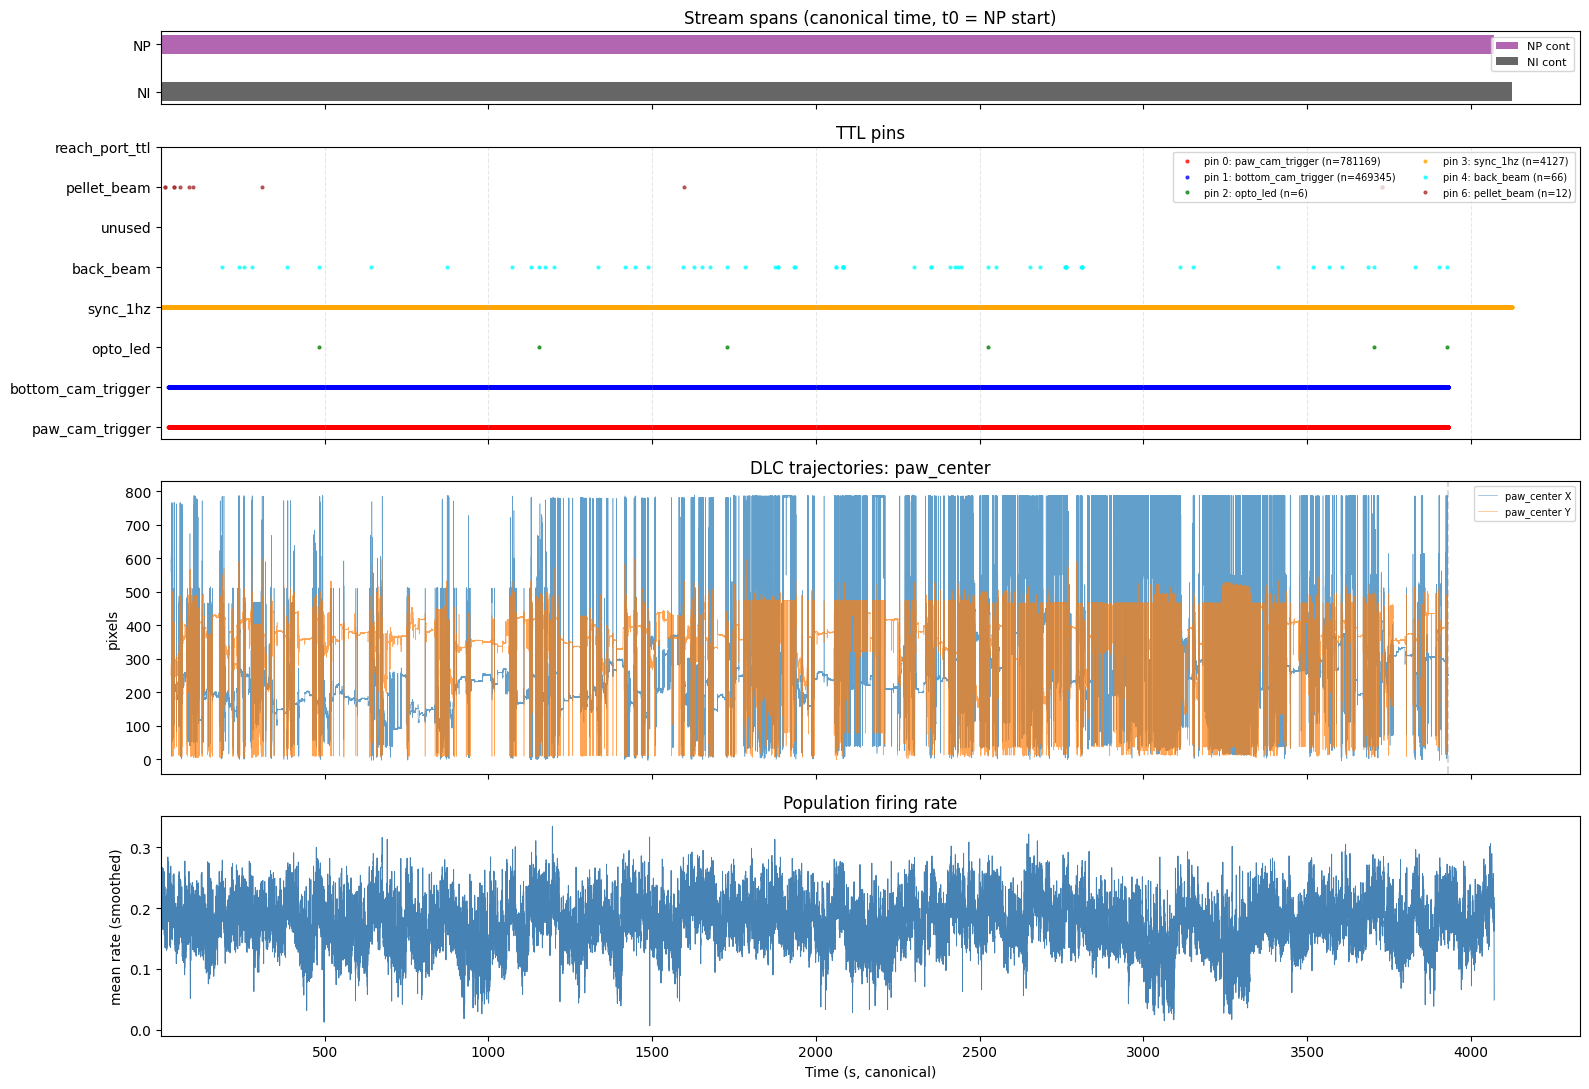


Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\sanity_overview.png

===== CELL F COMPLETE =====



In [9]:
# ============================================================
# CELL F — SANITY PLOTS (PORTABLE)
# ============================================================
# One figure with: TTL pins raster, DLC trajectory,
# NP/NI spans, population firing rate.
# Loads only from analysis_folder/ — no raw data needed.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
 
print("\n===== CELL F — SANITY PLOTS =====")
 
# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
PLOT_BODYPARTS = ["paw_center"]   # must match DLC bodypart names
# ------------------------------------------------------------
 
if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")
 
with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
with open(analysis_folder / "metadata" / "np_ni_alignment.json") as f:
    align_meta = json.load(f)
 
pin_labels = session["pin_labels"]
rec_dur    = session["recording_duration_s"]
ni_start   = align_meta["ni_start_rel"]
ni_end     = align_meta["ni_end_rel"]
 
# Load all TTL pins
ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}
for pin in range(8):
    p = ttls_dir / f"TTL_Pin_{pin}.npy"
    all_pin_ttls[pin] = np.load(p) if p.exists() else np.array([])
 
# Load full-session DLC
dlc_npz = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
dlc_t = dlc_npz["canonical_time"]
 
# Load population firing-rate trace
centers     = np.load(analysis_folder / "qc" / "centers.npy")
rate_matrix = np.load(analysis_folder / "qc" / "rate_matrix.npy")
pop_rate    = rate_matrix.mean(axis=0)
 
# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True,
                         gridspec_kw={"height_ratios": [0.5, 2, 2, 1.5]})
 
# Row 0: NP / NI stream spans
ax = axes[0]
ax.barh(1, rec_dur, left=0, height=0.4, color="purple", alpha=0.6, label="NP cont")
ax.barh(0, ni_end - ni_start, left=ni_start, height=0.4, color="black", alpha=0.6, label="NI cont")
ax.set_yticks([0, 1]); ax.set_yticklabels(["NI", "NP"])
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Stream spans (canonical time, t0 = NP start)")
 
# Row 1: TTL pin raster
ax = axes[1]
colors = ['red','blue','green','orange','cyan','magenta','brown','gray']
for pin in range(8):
    t = all_pin_ttls[pin]
    if len(t) == 0:
        continue
    label = pin_labels.get(str(pin), f"pin {pin}")
    ax.scatter(t, np.full_like(t, pin), s=4, color=colors[pin], alpha=0.7,
               label=f"pin {pin}: {label} (n={len(t)})")
ax.set_yticks(range(8))
ax.set_yticklabels([pin_labels.get(str(p), f"pin {p}") for p in range(8)])
ax.legend(fontsize=7, loc="upper right", ncol=2)
ax.set_title("TTL pins")
ax.grid(True, axis="x", linestyle="--", alpha=0.3)
 
# Row 2: DLC trajectories
ax = axes[2]
for bp in PLOT_BODYPARTS:
    if f"{bp}_x" not in dlc_npz.files:
        print(f"  WARNING: bodypart '{bp}' not in DLC file. "
              f"Available: {[k.replace('_x','') for k in dlc_npz.files if k.endswith('_x')]}")
        continue
    ax.plot(dlc_t, dlc_npz[f"{bp}_x"], lw=0.4, alpha=0.7, label=f"{bp} X")
    ax.plot(dlc_t, dlc_npz[f"{bp}_y"], lw=0.4, alpha=0.7, label=f"{bp} Y")
for block in session["blocks"]:
    if not block.get("skipped", False):
        ax.axvline(block["end_canonical"], color="gray", linestyle="--", alpha=0.3)
ax.set_ylabel("pixels")
ax.legend(fontsize=7, loc="upper right")
ax.set_title(f"DLC trajectories: {', '.join(PLOT_BODYPARTS)}")
 
# Row 3: population firing rate
ax = axes[3]
ax.plot(centers, pop_rate, color="steelblue", lw=0.7)
ax.set_ylabel("mean rate (smoothed)")
ax.set_title("Population firing rate")
ax.set_xlabel("Time (s, canonical)")
 
plt.tight_layout()
 
out_dir  = analysis_folder / "qc"
out_path = out_dir / "sanity_overview.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"sanity_overview_{i}.png"; i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")
print("\n===== CELL F COMPLETE =====\n")


===== CELL G — PERI-EVENT DIAGNOSTIC =====
Event pin 4 (back_beam): 66 TTLs

===== EVENT REFERENCE TABLE =====
  # |  canonical (s) | block | MP4 frame | MP4 time (s) | lookup err (ms)
---------------------------------------------------------------------------
  1 |        185.623 |     1 |     30973 |      154.865 |             2.3
  2 |        237.980 |     1 |     41450 |      207.250 |             1.8
  3 |        252.238 |     1 |     44304 |      221.520 |             0.9
  4 |        276.688 |     1 |     49197 |      245.985 |             1.0
  5 |        385.614 |     1 |     70996 |      354.980 |             2.3
  6 |        483.964 |     1 |     90678 |      453.390 |             2.4
  7 |        642.644 |     1 |    122433 |      612.165 |             0.7
  8 |        872.068 |     1 |    168346 |      841.730 |             1.3



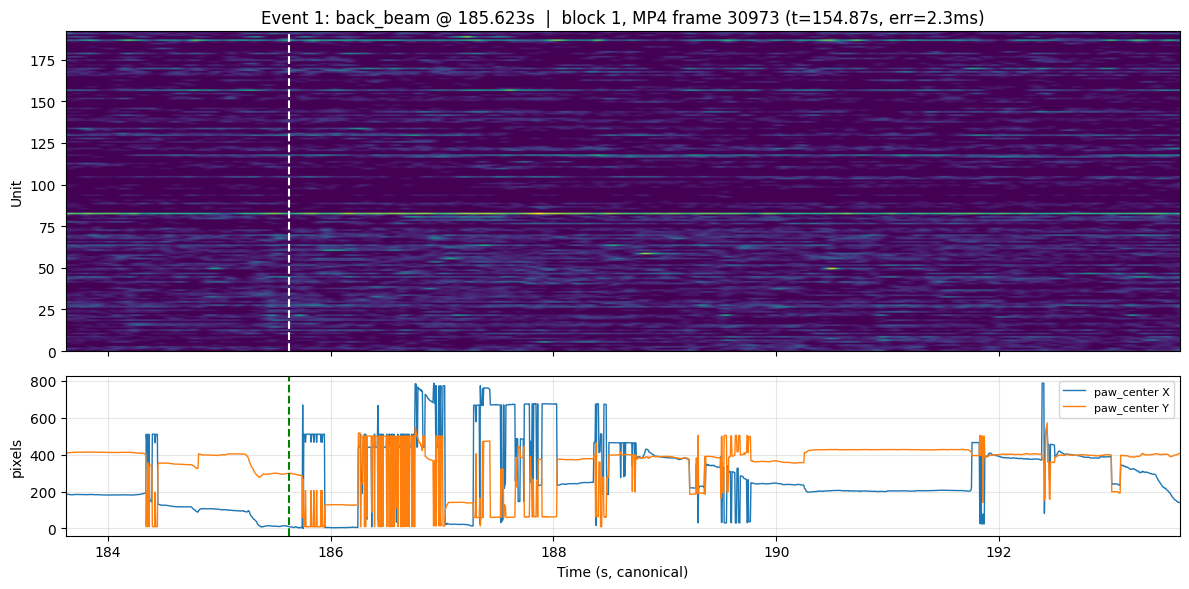

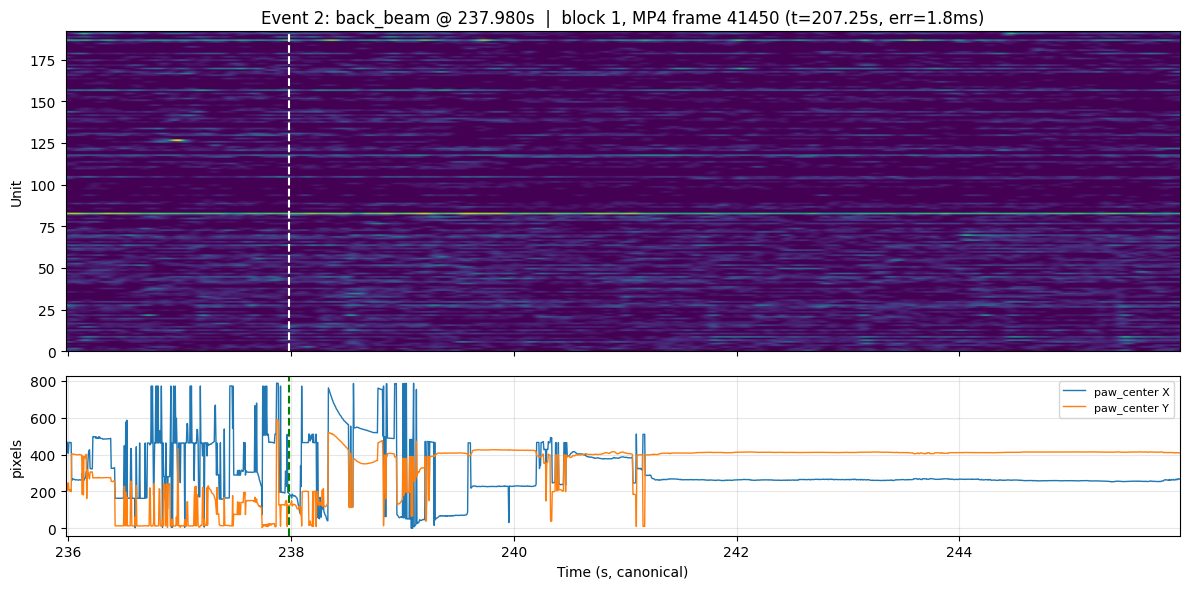

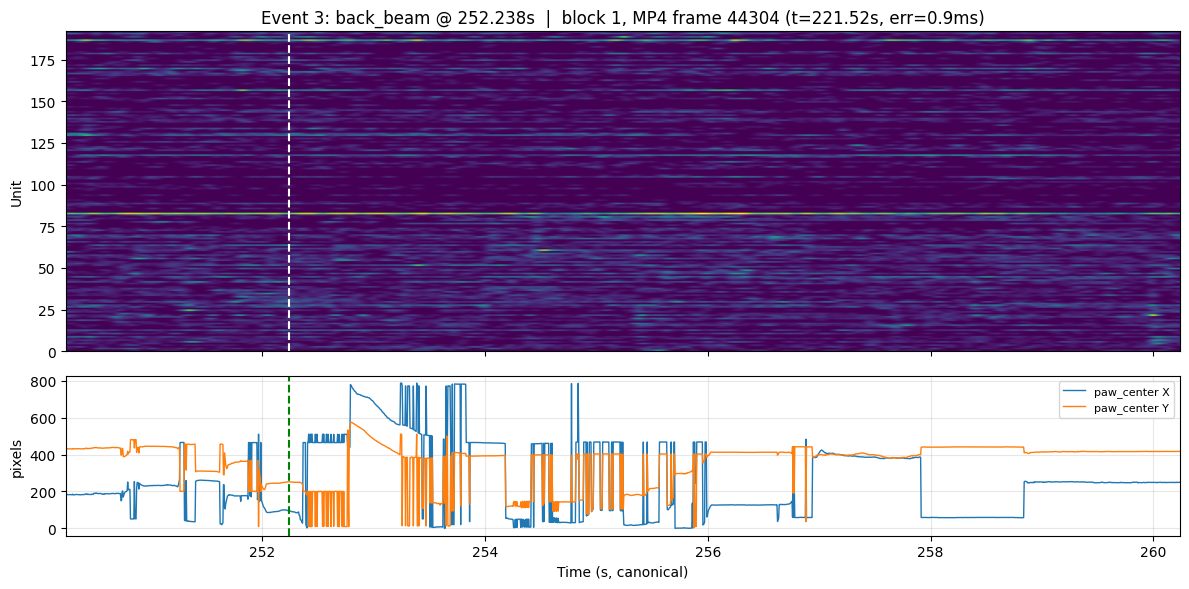

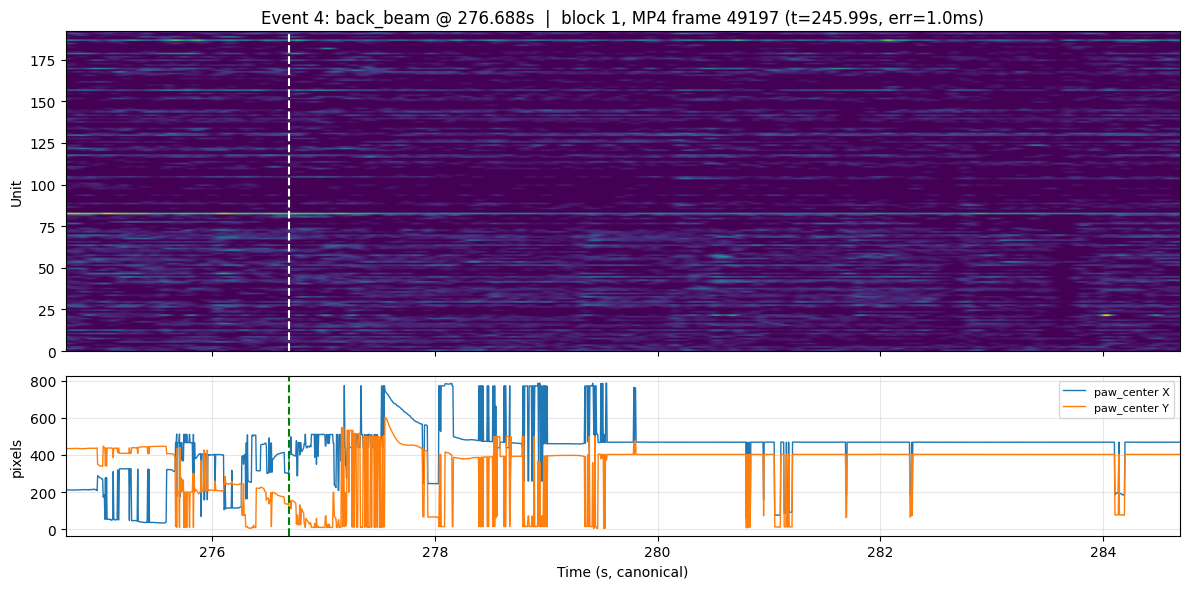

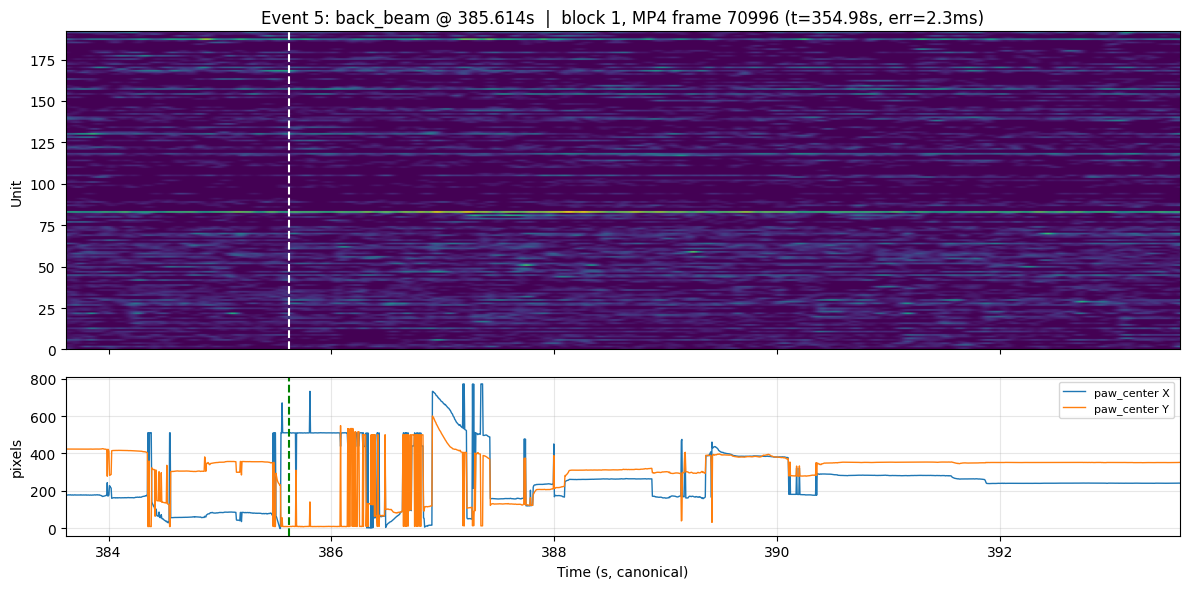

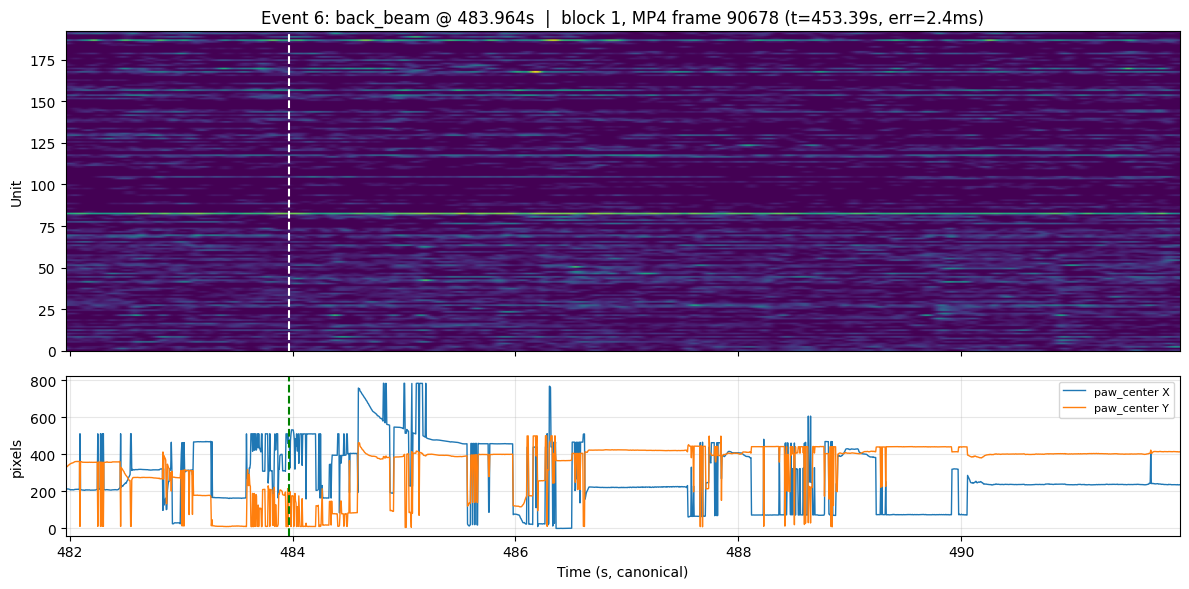

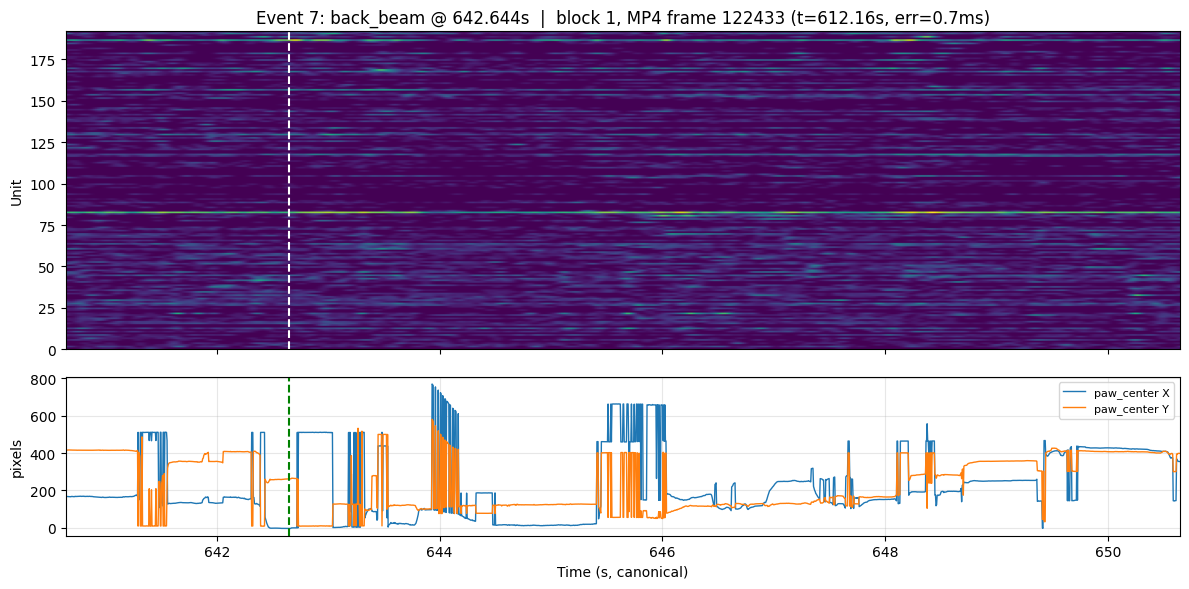

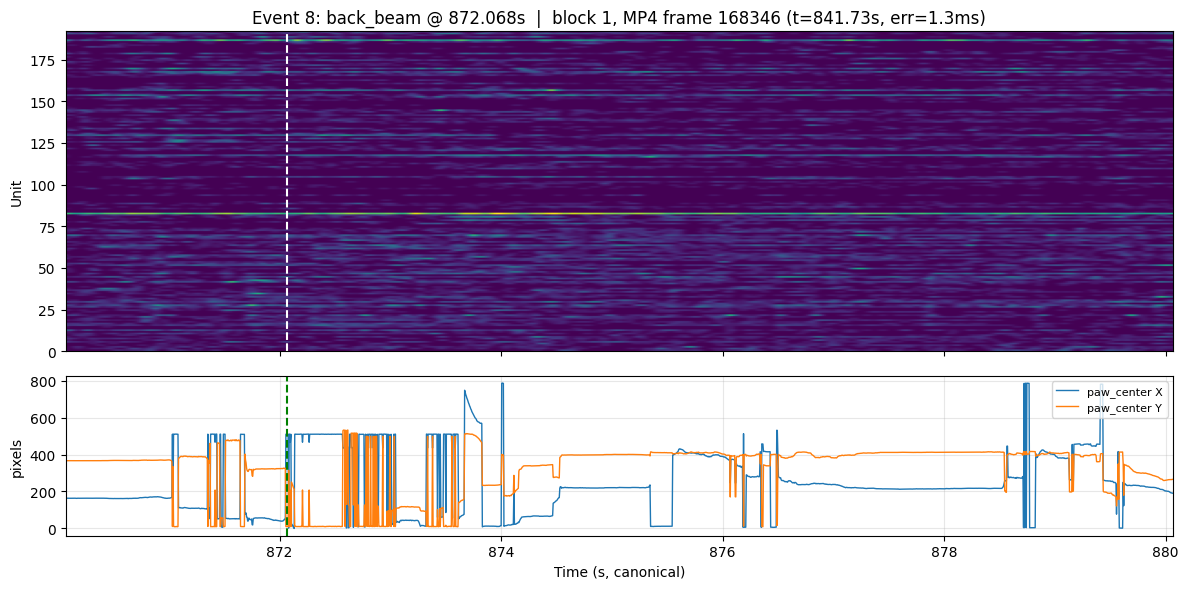


===== CELL G COMPLETE =====



In [11]:
#============================================================
# CELL G — PERI-EVENT DIAGNOSTIC (PORTABLE)
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
 
print("\n===== CELL G — PERI-EVENT DIAGNOSTIC =====")
 
# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN       = 4              # 4 = back_beam (trial start), 6 = pellet_beam
PLOT_BODYPARTS  = ["paw_center"] # must match DLC bodypart names
WIN_PRE         = 2.0            # seconds before event
WIN_POST        = 8.0            # seconds after event
MAX_EVENTS_PLOT = 8
ONE_PER_TRIAL   = False
TRIAL_PIN       = 4
VIDEO_FPS       = 200.0          # paw_angled camera runs at 200Hz
# ------------------------------------------------------------
 
if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")
 
with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
 
# Pre-load per-block frame canonical times — skip empty blocks
block_frame_times = {}
for blk in session["blocks"]:
    b = blk["block_index"]
    if blk.get("skipped", False):
        continue
    block_frame_times[b] = np.load(blk["frame_canonical_times_path"])
 
def canonical_to_video(t_canonical):
    for b, frame_t in block_frame_times.items():
        if frame_t[0] <= t_canonical <= frame_t[-1]:
            idx = np.searchsorted(frame_t, t_canonical)
            candidates = []
            if idx < len(frame_t): candidates.append(idx)
            if idx > 0:            candidates.append(idx - 1)
            best = min(candidates, key=lambda i: abs(frame_t[i] - t_canonical))
            err  = abs(frame_t[best] - t_canonical)
            return b, int(best), float(best / VIDEO_FPS), float(err)
    return None, None, None, None
 
ttls_dir    = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
print(f"Event pin {EVENT_PIN} ({event_label}): {len(event_times)} TTLs")
 
if ONE_PER_TRIAL:
    trial_times = np.load(ttls_dir / f"TTL_Pin_{TRIAL_PIN}.npy")
    kept = []
    for ts in trial_times:
        idx = np.searchsorted(event_times, ts)
        if idx < len(event_times) and event_times[idx] - ts < 25:
            kept.append(event_times[idx])
    event_times = np.array(kept)
    print(f"After 'first per trial' filter: {len(event_times)} events")
 
event_times = event_times[:MAX_EVENTS_PLOT]
 
# Reference table
print(f"\n===== EVENT REFERENCE TABLE =====")
print(f"{'#':>3} | {'canonical (s)':>14} | {'block':>5} | "
      f"{'MP4 frame':>9} | {'MP4 time (s)':>12} | {'lookup err (ms)':>15}")
print("-" * 75)
for i, t_evt in enumerate(event_times):
    b, vframe, vtime, err = canonical_to_video(t_evt)
    if b is None:
        print(f"{i+1:>3} | {t_evt:>14.3f} | {'OOB':>5} | {'—':>9} | {'—':>12} | {'—':>15}")
    else:
        flag = " ⚠ drop?" if err is not None and err > 0.030 else ""
        print(f"{i+1:>3} | {t_evt:>14.3f} | {b:>5} | {vframe:>9} | "
              f"{vtime:>12.3f} | {err*1000:>15.1f}{flag}")
print()
 
centers     = np.load(analysis_folder / "qc" / "centers.npy")
rate_matrix = np.load(analysis_folder / "qc" / "rate_matrix.npy")
good_units  = np.load(analysis_folder / "qc" / "good_units.npy")
dlc         = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
dlc_t       = dlc["canonical_time"]
 
for i, t_evt in enumerate(event_times):
    t0, t1   = t_evt - WIN_PRE, t_evt + WIN_POST
    mask_fr  = (centers >= t0) & (centers <= t1)
    mask_dlc = (dlc_t   >= t0) & (dlc_t   <= t1)
 
    b, vframe, vtime, err = canonical_to_video(t_evt)
    video_str = (f"block {b}, MP4 frame {vframe} (t={vtime:.2f}s, err={err*1000:.1f}ms)"
                 if b is not None else "outside any block")
 
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
 
    ax = axes[0]
    ax.imshow(rate_matrix[:, mask_fr], aspect="auto",
              extent=[t0, t1, 0, len(good_units)], origin="lower")
    ax.axvline(t_evt, color="white", linestyle="--", lw=1.5)
    ax.set_ylabel("Unit")
    ax.set_title(f"Event {i+1}: {event_label} @ {t_evt:.3f}s  |  {video_str}")
 
    ax = axes[1]
    for bp in PLOT_BODYPARTS:
        if f"{bp}_x" not in dlc.files:
            continue
        ax.plot(dlc_t[mask_dlc], dlc[f"{bp}_x"][mask_dlc], lw=1.0, label=f"{bp} X")
        ax.plot(dlc_t[mask_dlc], dlc[f"{bp}_y"][mask_dlc], lw=1.0, label=f"{bp} Y")
    ax.axvline(t_evt, color="green", linestyle="--", lw=1.5)
    ax.set_xlabel("Time (s, canonical)")
    ax.set_ylabel("pixels")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.show()
 
print("\n===== CELL G COMPLETE =====\n")
 


===== CELL H — UNIT MODULATION + LATENCY SORT =====
Aligning to: back_beam (pin 4), 66 events
Computing PSTHs for 192 units × 66 events × 300 bins...

Modulated: 118 / 192 units


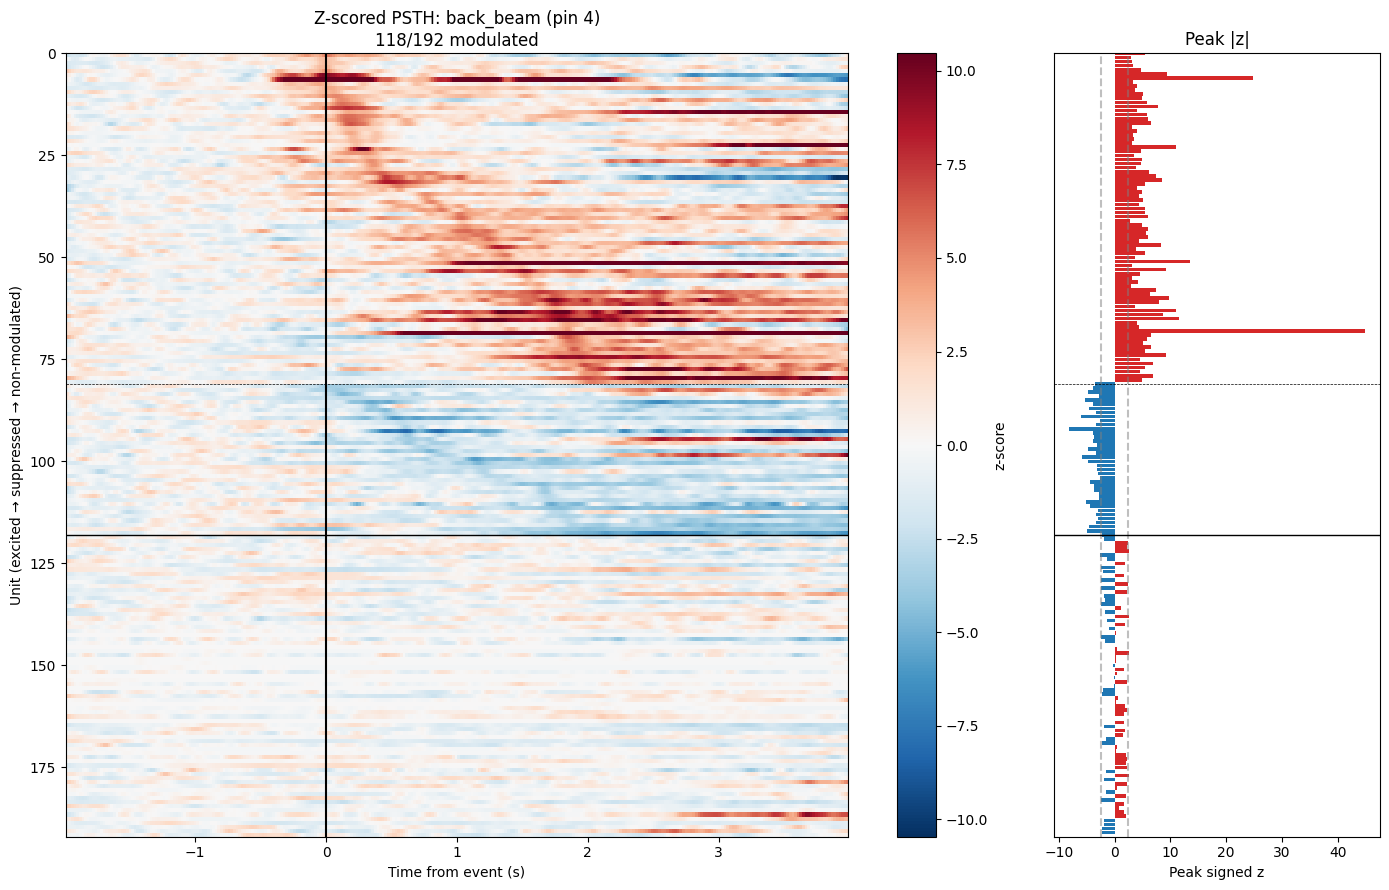


Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\modulation_pin4_back_beam.png

===== CELL H COMPLETE =====



In [12]:
# ============================================================
# CELL H — UNIT MODULATION DETECTION + LATENCY SORT (PORTABLE)
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
 
print("\n===== CELL H — UNIT MODULATION + LATENCY SORT =====")
 
# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN          = 4           # 4 = back_beam, 6 = pellet_beam
                                 # NOTE: pin 3 = 1Hz sync — do NOT use as event
EVENT_LABEL_FOR_3  = None        # unused for freely moving rig (pin 3 = sync)
WIN_PRE            = 2.0
WIN_POST           = 4.0
BASELINE_WIN       = (-2.0, -0.5)
RESPONSE_WIN       = ( 0.0,  2.0)
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
Z_THRESHOLD        = 2.5
MIN_CONSECUTIVE_MS = 60
ONE_PER_TRIAL      = False
TRIAL_PIN          = 4
# ------------------------------------------------------------
 
if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")
 
with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels  = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
 
ttls_dir    = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
 
if ONE_PER_TRIAL:
    trial_times = np.load(ttls_dir / f"TTL_Pin_{TRIAL_PIN}.npy")
    kept = []
    for ts in trial_times:
        idx = np.searchsorted(event_times, ts)
        if idx < len(event_times) and event_times[idx] - ts < 25:
            kept.append(event_times[idx])
    event_times = np.array(kept)
 
print(f"Aligning to: {event_label} (pin {EVENT_PIN}), {len(event_times)} events")
 
edges          = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers        = edges[:-1] + BIN_SIZE / 2
n_bins         = len(centers)
baseline_mask  = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
response_mask  = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
 
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
 
print(f"Computing PSTHs for {len(good_units)} units × "
      f"{len(event_times)} events × {n_bins} bins...")
 
psth_per_trial = np.zeros((len(good_units), len(event_times), n_bins))
for u_i, unit in enumerate(good_units):
    spk = np.load(spikes_dir / f"unit_{unit}.npy")
    for e_i, t_evt in enumerate(event_times):
        rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
        h, _ = np.histogram(rel, bins=edges)
        psth_per_trial[u_i, e_i] = h / BIN_SIZE
 
psth        = psth_per_trial.mean(axis=1)
psth_smooth = gaussian_filter1d(psth, sigma=SMOOTH_SIGMA_BINS, axis=1)
 
baseline_mean = psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
baseline_std  = psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
baseline_std[baseline_std < 0.5] = 0.5
z = (psth_smooth - baseline_mean) / baseline_std
 
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))
z_response      = z[:, response_mask]
 
def has_consecutive_crossing(z_row, thresh, min_consec):
    for arr in (z_row > thresh, z_row < -thresh):
        if not arr.any(): continue
        padded = np.concatenate([[False], arr, [False]])
        diffs  = np.diff(padded.astype(int))
        starts = np.where(diffs ==  1)[0]
        ends   = np.where(diffs == -1)[0]
        if (ends - starts).max() >= min_consec:
            return True
    return False
 
modulated = np.array([
    has_consecutive_crossing(z_response[i], Z_THRESHOLD, min_consec_bins)
    for i in range(len(good_units))
])
n_modulated = int(modulated.sum())
print(f"\nModulated: {n_modulated} / {len(good_units)} units")
 
peak_idx = np.argmax(np.abs(z_response), axis=1)
response_centers = centers[response_mask]
peak_lat = response_centers[peak_idx]
peak_z   = z_response[np.arange(len(good_units)), peak_idx]
 
mod_idx      = np.where(modulated)[0]
mod_peak_z   = peak_z[mod_idx]
mod_peak_lat = peak_lat[mod_idx]
exc_mask     = mod_peak_z > 0
sup_mask     = ~exc_mask
 
excited_order    = mod_idx[exc_mask][np.argsort(mod_peak_lat[exc_mask])]
suppressed_order = mod_idx[sup_mask][np.argsort(mod_peak_lat[sup_mask])]
sorted_mod_idx   = np.concatenate([excited_order, suppressed_order])
non_mod_idx      = np.where(~modulated)[0]
full_sort_idx    = np.concatenate([sorted_mod_idx, non_mod_idx])
 
fig, axes = plt.subplots(1, 2, figsize=(14, 9),
                          gridspec_kw={"width_ratios": [3, 1]})
ax   = axes[0]
vmax = max(3.0, np.percentile(np.abs(z), 99))
im   = ax.imshow(z[full_sort_idx], aspect="auto",
                 extent=[centers[0], centers[-1], len(good_units), 0],
                 cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.5)
ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("Unit (excited → suppressed → non-modulated)")
ax.set_title(f"Z-scored PSTH: {event_label} (pin {EVENT_PIN})\n"
             f"{n_modulated}/{len(good_units)} modulated")
plt.colorbar(im, ax=ax, label="z-score")
 
ax = axes[1]
peak_z_sorted = peak_z[full_sort_idx]
ax.barh(np.arange(len(good_units)), peak_z_sorted,
        color=np.where(peak_z_sorted > 0, "C3", "C0"), height=0.9)
ax.axvline( Z_THRESHOLD, color="gray", linestyle="--", alpha=0.5)
ax.axvline(-Z_THRESHOLD, color="gray", linestyle="--", alpha=0.5)
ax.axhline(len(excited_order),  color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(good_units), 0)
ax.set_xlabel("Peak signed z"); ax.set_yticks([]); ax.set_title("Peak |z|")
 
plt.tight_layout()
 
out_dir  = analysis_folder / "qc"
out_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_{i}.png"; i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")
 
np.savez(out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_arrays.npz",
         good_units=good_units, psth_smooth=psth_smooth, z=z,
         modulated=modulated, peak_latency=peak_lat, peak_z=peak_z,
         sort_order=full_sort_idx, centers=centers)
 
print("\n===== CELL H COMPLETE =====\n")



===== PROBE DEPTH VISUALIZATION =====
Columns: ['id', 'Amplitude', 'ContamPct', 'KSLabel', 'amp', 'ch', 'depth', 'fr', 'group', 'n_spikes', 'sh']
Total clusters: 375
Good units: 190

DV depth range: 49 → 3869 µm
     CFA:  87 units  FR: 0.1–30.8 Hz  (median 4.6 Hz)
      WM:  66 units  FR: 0.0–29.4 Hz  (median 7.8 Hz)
     VAL:  37 units  FR: 0.9–27.1 Hz  (median 10.2 Hz)

Rate matrix loaded: (192, 203546)


C:\Users\kkost\AppData\Local\Temp\ipykernel_5936\4171655385.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


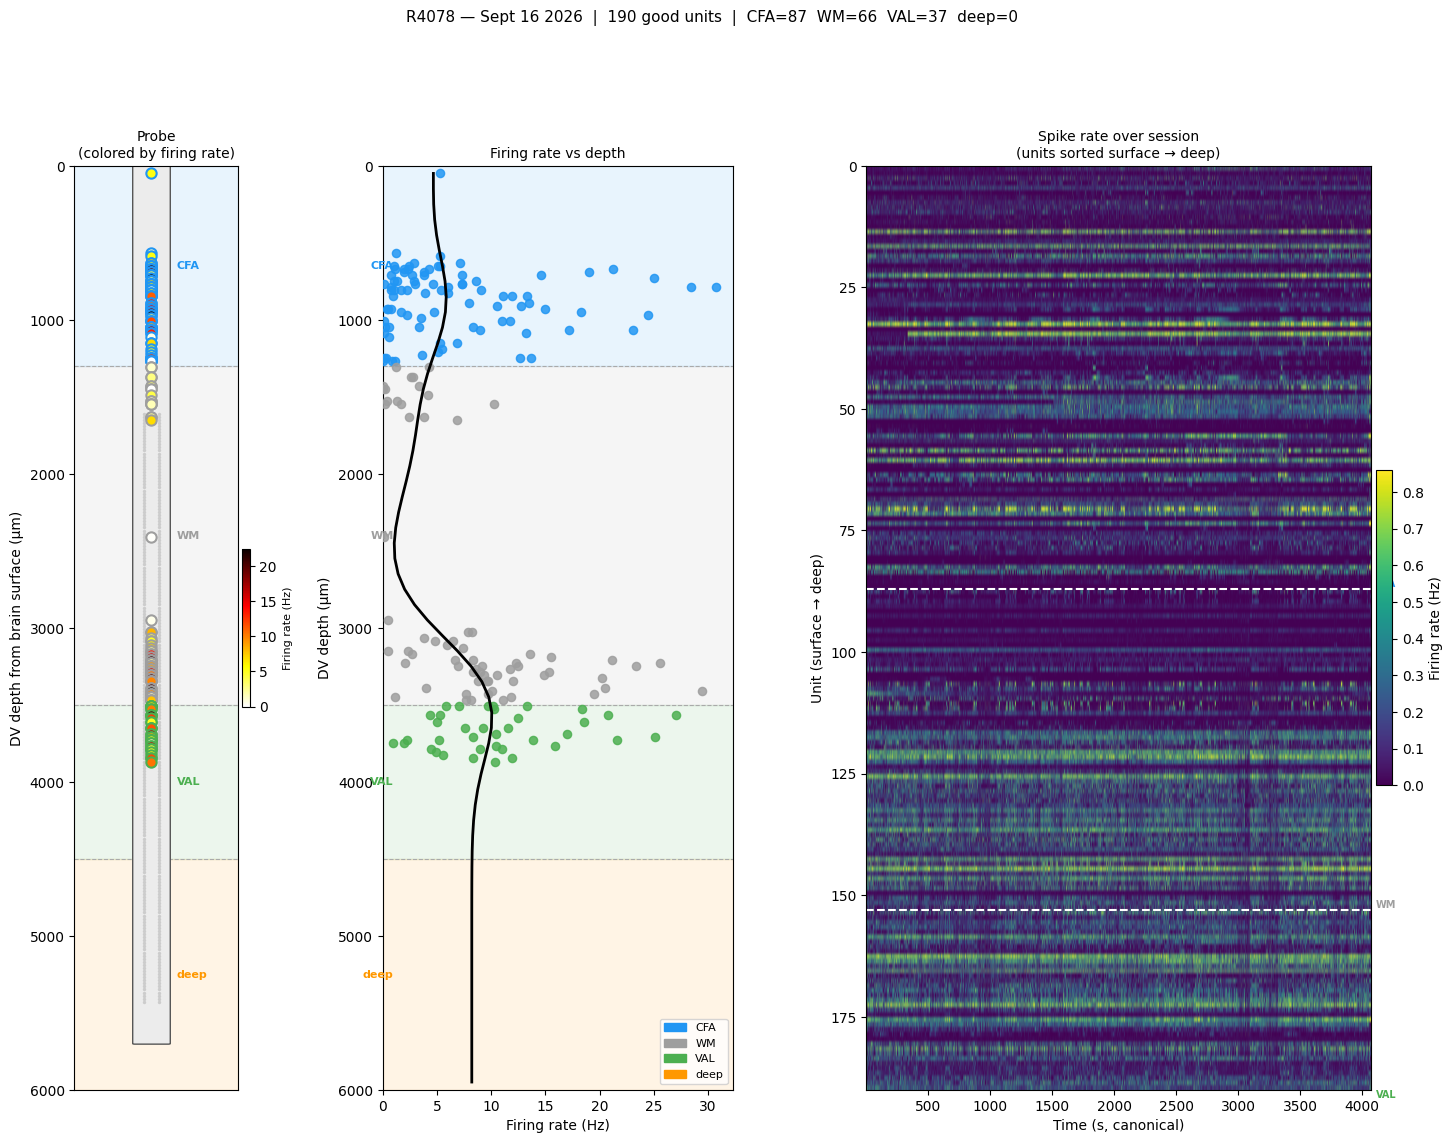


Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\probe_depth_map.png

   ID |  DV (µm) | Region |  FR (Hz) | n_spikes
------------------------------------------------
  373 |       49 |    CFA |     5.27 |    21447
  345 |      569 |    CFA |     1.19 |     4831
  350 |      589 |    CFA |     5.26 |    21415
  337 |      629 |    CFA |     2.92 |    11905
  341 |      629 |    CFA |     7.10 |    28885
  330 |      649 |    CFA |     1.05 |     4268
  336 |      649 |    CFA |     2.39 |     9723
  329 |      649 |    CFA |     5.13 |    20903
  339 |      649 |    CFA |     5.29 |    21539
  328 |      669 |    CFA |     4.25 |    17307
  338 |      669 |    CFA |     2.35 |     9586
  334 |      669 |    CFA |     1.97 |     8040
  335 |      669 |    CFA |     1.09 |     4457
  318 |      669 |    CFA |    21.25 |    86489
  325 |      689 |    CFA |     1.98 |     8074
  324 |      6

In [16]:
# ============================================================
# CELL — PROBE DEPTH VISUALIZATION
# ============================================================
# Shows which units are in CFA cortex vs white matter vs VAL
# thalamus based on their position along the probe.
#
# Three panels:
#   Left  : to-scale probe drawing, each site colored by
#           mean firing rate of the nearest unit
#   Center: firing rate vs DV depth, color-coded by region
#   Right : spike rate heatmap sorted by depth
#
# Uses cluster_info.tsv columns: id, group, depth, fr, ch
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== PROBE DEPTH VISUALIZATION =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
PROBEA_PATH = (
    r"G:\Neuropixels data-motor project\freely moving"
    r"\2026-09-16_13-21-12\Record Node 101"
    r"\experiment2\recording1\continuous"
    r"\Neuropix-PXI-100.ProbeA-AP\kilosort4"
)

# Region boundaries in DV depth (µm, surface=0, deeper=larger)
REGION_BOUNDS = {
    "CFA":  (0,    1300),
    "WM":   (1300, 3500),
    "VAL":  (3500, 4500),
    "deep": (4500, 6000),
}
REGION_COLORS = {
    "CFA":  "#2196F3",   # blue
    "WM":   "#9E9E9E",   # gray
    "VAL":  "#4CAF50",   # green
    "deep": "#FF9800",   # orange
}

TIP_DV_UM    = 5429.0    # DV depth of probe tip (µm)
DISPLAY_DEPTH = 6000     # µm of probe to show in figure
SITE_PITCH_Y  = 20.0     # µm between electrode rows (NP 1.0)
SMOOTH_SIGMA  = 3        # bins for depth profile smoothing
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# ------------------------------------------------------------
# LOAD cluster_info.tsv
# ------------------------------------------------------------
probe_dir = Path(PROBEA_PATH)
ci = pd.read_csv(probe_dir / "cluster_info.tsv", sep="\t")
print(f"Columns: {ci.columns.tolist()}")
print(f"Total clusters: {len(ci)}")

# Keep only 'good' units (Phy-curated group column)
good_ci = ci[ci["group"].str.lower() == "good"].copy()
print(f"Good units: {len(good_ci)}")

# depth column in cluster_info is Kilosort convention:
# y=0 at tip, y increases toward surface.
# DV depth = TIP_DV_UM - depth_from_tip
good_ci["depth_from_tip"] = good_ci["depth"].astype(float)
good_ci["dv_depth"]       = TIP_DV_UM - good_ci["depth_from_tip"]

# fr column is already mean firing rate in Hz from Phy
good_ci["firing_rate"] = good_ci["fr"].astype(float)

# Assign regions
def get_region(dv):
    for name, (lo, hi) in REGION_BOUNDS.items():
        if lo <= dv < hi:
            return name
    return "deep"

good_ci["region"] = good_ci["dv_depth"].apply(get_region)
good_ci = good_ci.sort_values("dv_depth").reset_index(drop=True)

print(f"\nDV depth range: {good_ci['dv_depth'].min():.0f} → "
      f"{good_ci['dv_depth'].max():.0f} µm")
for name in REGION_BOUNDS:
    n = (good_ci["region"] == name).sum()
    fr_vals = good_ci.loc[good_ci["region"] == name, "firing_rate"]
    if len(fr_vals):
        print(f"  {name:>6}: {n:>3} units  "
              f"FR: {fr_vals.min():.1f}–{fr_vals.max():.1f} Hz  "
              f"(median {fr_vals.median():.1f} Hz)")

# ------------------------------------------------------------
# LOAD RATE MATRIX FROM CELL A (for heatmap panel)
# ------------------------------------------------------------
rate_matrix_path = analysis_folder / "qc" / "rate_matrix.npy"
centers_path     = analysis_folder / "qc" / "centers.npy"
has_rate_matrix  = rate_matrix_path.exists() and centers_path.exists()

if has_rate_matrix:
    rate_matrix_all = np.load(rate_matrix_path)
    centers_all     = np.load(centers_path)
    good_units_npy  = np.load(analysis_folder / "qc" / "good_units.npy")
    uid_to_row      = {int(uid): i for i, uid in enumerate(good_units_npy)}
    print(f"\nRate matrix loaded: {rate_matrix_all.shape}")
else:
    print("\nNo rate_matrix.npy found — heatmap panel will be skipped.")

# ------------------------------------------------------------
# COLOR SCALE
# ------------------------------------------------------------
max_rate = float(np.percentile(good_ci["firing_rate"], 95))
max_rate = max(max_rate, 1.0)
norm_fr  = Normalize(vmin=0, vmax=max_rate)
cmap_fr  = plt.cm.hot_r

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(17, 12))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 2, 3], wspace=0.38)

ax_probe   = fig.add_subplot(gs[0])
ax_profile = fig.add_subplot(gs[1])
ax_heatmap = fig.add_subplot(gs[2])

# ── Panel 1: PROBE DRAWING ────────────────────────────────
SHANK_WIDTH = 70   # µm

ax_probe.set_xlim(-160, 180)
ax_probe.set_ylim(DISPLAY_DEPTH, 0)   # surface at top
ax_probe.set_ylabel("DV depth from brain surface (µm)")
ax_probe.set_title("Probe\n(colored by firing rate)", fontsize=10)
ax_probe.set_xticks([])

# Region shading
for name, (lo, hi) in REGION_BOUNDS.items():
    ax_probe.axhspan(max(lo, 0), min(hi, DISPLAY_DEPTH),
                     alpha=0.10, color=REGION_COLORS[name], zorder=0)
    mid = (max(lo, 0) + min(hi, DISPLAY_DEPTH)) / 2
    ax_probe.text(52, mid, name, fontsize=8, va="center",
                  color=REGION_COLORS[name], fontweight="bold")

# Region boundary lines
for name, (lo, hi) in REGION_BOUNDS.items():
    if 0 < lo < DISPLAY_DEPTH:
        ax_probe.axhline(lo, color="#aaa", lw=0.8, linestyle="--", zorder=0)

# Shank body
shank = mpatches.FancyBboxPatch(
    (-SHANK_WIDTH/2, 0), SHANK_WIDTH, DISPLAY_DEPTH - 300,
    boxstyle="round,pad=4", lw=1,
    edgecolor="#555", facecolor="#ececec", zorder=1
)
ax_probe.add_patch(shank)

# All electrode sites (faint background)
for site_row in range(192):   # 384 sites / 2 per row
    site_dv = TIP_DV_UM - site_row * SITE_PITCH_Y
    if 0 <= site_dv <= DISPLAY_DEPTH:
        for x_off in (-16, 16):
            ax_probe.scatter(x_off, site_dv, s=6, color="#ccc",
                             zorder=2, linewidths=0)

# Good units colored by firing rate, outlined by region color
for _, row in good_ci.iterrows():
    dv = row["dv_depth"]
    if not (0 <= dv <= DISPLAY_DEPTH):
        continue
    color   = cmap_fr(norm_fr(row["firing_rate"]))
    outline = REGION_COLORS[row["region"]]
    ax_probe.scatter(0, dv, s=55, color=color, zorder=3,
                     edgecolors=outline, linewidths=1.5)

# Colorbar
sm = ScalarMappable(cmap=cmap_fr, norm=norm_fr)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax_probe, fraction=0.045, pad=0.02)
cb.set_label("Firing rate (Hz)", fontsize=8)

# ── Panel 2: DEPTH PROFILE ────────────────────────────────
ax_profile.set_title("Firing rate vs depth", fontsize=10)
ax_profile.set_xlabel("Firing rate (Hz)")
ax_profile.set_ylabel("DV depth (µm)")
ax_profile.set_ylim(DISPLAY_DEPTH, 0)

for name, (lo, hi) in REGION_BOUNDS.items():
    ax_profile.axhspan(max(lo,0), min(hi, DISPLAY_DEPTH),
                       alpha=0.10, color=REGION_COLORS[name])
for name, (lo, hi) in REGION_BOUNDS.items():
    if 0 < lo < DISPLAY_DEPTH:
        ax_profile.axhline(lo, color="#aaa", lw=0.8, linestyle="--")
    mid = (max(lo,0) + min(hi, DISPLAY_DEPTH)) / 2
    ax_profile.text(ax_profile.get_xlim()[1] if ax_profile.get_xlim()[1] > 0 else 1,
                    mid, name, fontsize=8, va="center",
                    color=REGION_COLORS[name], fontweight="bold",
                    ha="right")

# Individual units
for _, row in good_ci.iterrows():
    ax_profile.scatter(row["firing_rate"], row["dv_depth"],
                       color=REGION_COLORS[row["region"]],
                       s=35, alpha=0.85, zorder=3)

# Smoothed mean profile
depth_bins = np.arange(0, DISPLAY_DEPTH + 100, 100)
depth_ctr  = depth_bins[:-1] + 50
mean_rate  = np.full(len(depth_ctr), np.nan)
for i, (d0, d1) in enumerate(zip(depth_bins[:-1], depth_bins[1:])):
    m = (good_ci["dv_depth"] >= d0) & (good_ci["dv_depth"] < d1)
    if m.sum() >= 1:
        mean_rate[i] = good_ci.loc[m, "firing_rate"].mean()

valid = ~np.isnan(mean_rate)
if valid.sum() > 3:
    interp  = np.interp(depth_ctr, depth_ctr[valid], mean_rate[valid])
    smoothed = gaussian_filter1d(interp, sigma=SMOOTH_SIGMA)
    ax_profile.plot(smoothed, depth_ctr, color="black", lw=2.0,
                    zorder=4, label="mean (smoothed)")

ax_profile.set_xlim(left=0)
legend_patches = [mpatches.Patch(color=REGION_COLORS[r], label=r)
                  for r in REGION_BOUNDS]
ax_profile.legend(handles=legend_patches, fontsize=8, loc="lower right")

# ── Panel 3: RATE HEATMAP SORTED BY DEPTH ────────────────
ax_heatmap.set_title("Spike rate over session\n"
                      "(units sorted surface → deep)", fontsize=10)

if has_rate_matrix:
    rows_sorted   = []
    dv_sorted     = []
    region_sorted = []

    for _, row in good_ci.iterrows():
        uid = int(row["id"])
        if uid in uid_to_row:
            rows_sorted.append(uid_to_row[uid])
            dv_sorted.append(row["dv_depth"])
            region_sorted.append(row["region"])

    if rows_sorted:
        hmap  = rate_matrix_all[rows_sorted, :]
        vmax_h = float(np.percentile(hmap, 98))

        im = ax_heatmap.imshow(
            hmap, aspect="auto", origin="upper",
            extent=[centers_all[0], centers_all[-1],
                    len(rows_sorted), 0],
            cmap="viridis", vmin=0, vmax=vmax_h
        )
        ax_heatmap.set_xlabel("Time (s, canonical)")
        ax_heatmap.set_ylabel("Unit (surface → deep)")

        # Region boundary lines + labels on heatmap
        prev_reg = region_sorted[0]
        for i, reg in enumerate(region_sorted):
            if reg != prev_reg:
                ax_heatmap.axhline(i, color="white", lw=1.5, linestyle="--")
                # label at boundary
                ax_heatmap.text(
                    centers_all[-1] + (centers_all[-1] - centers_all[0]) * 0.01,
                    i, prev_reg, fontsize=7, va="bottom",
                    color=REGION_COLORS[prev_reg], fontweight="bold",
                    clip_on=False
                )
                prev_reg = reg
        # label last region
        ax_heatmap.text(
            centers_all[-1] + (centers_all[-1] - centers_all[0]) * 0.01,
            len(rows_sorted), prev_reg, fontsize=7, va="top",
            color=REGION_COLORS[prev_reg], fontweight="bold", clip_on=False
        )

        plt.colorbar(im, ax=ax_heatmap, label="Firing rate (Hz)",
                     fraction=0.03, pad=0.01)
    else:
        ax_heatmap.text(0.5, 0.5,
                        "No unit IDs matched between\ncluster_info and good_units.npy",
                        ha="center", va="center",
                        transform=ax_heatmap.transAxes, color="gray")
else:
    ax_heatmap.text(0.5, 0.5,
                    "rate_matrix.npy not found\nRun Cell A first",
                    ha="center", va="center",
                    transform=ax_heatmap.transAxes, fontsize=11, color="gray")

# ── Title and save ────────────────────────────────────────
n_by_region = {r: (good_ci["region"] == r).sum() for r in REGION_BOUNDS}
fig.suptitle(
    f"R4078 — Sept 16 2026  |  {len(good_ci)} good units  |  "
    + "  ".join(f"{r}={n_by_region[r]}" for r in REGION_BOUNDS),
    fontsize=11, y=1.01
)
plt.tight_layout()

out_path = analysis_folder / "qc" / "probe_depth_map.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path}")

# Text summary
print(f"\n{'ID':>5} | {'DV (µm)':>8} | {'Region':>6} | {'FR (Hz)':>8} | {'n_spikes':>8}")
print("-" * 48)
for _, row in good_ci.iterrows():
    print(f"{int(row['id']):>5} | {row['dv_depth']:>8.0f} | "
          f"{row['region']:>6} | {row['firing_rate']:>8.2f} | "
          f"{int(row['n_spikes']):>8}")

print("\n===== PROBE DEPTH VISUALIZATION COMPLETE =====\n")


===== CELL J — REACH DETECTION (absolute pixel) =====
Loaded 780495 frames, FPS=200.0
Available bodyparts: ['paw_center', 'digit1', 'digit2', 'digit3', 'left_paw', 'nose', 'pellet', 'wrist']
Trials: 66
IR beam breaks (pin 6): 12
  paw_center: 4506 frames in zone (0.58%)
  digit2: 5647 frames in zone (0.72%)

Total frames in zone (any marker): 6202 (0.79%)
After ≥5-frame filter: 5841 frames in zone, 163 separate runs

Detected reaches: 163
Bouts: 66

Saved reaches → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\peak_detection\reaches.npz
Saved bouts   → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\peak_detection\bouts.npz


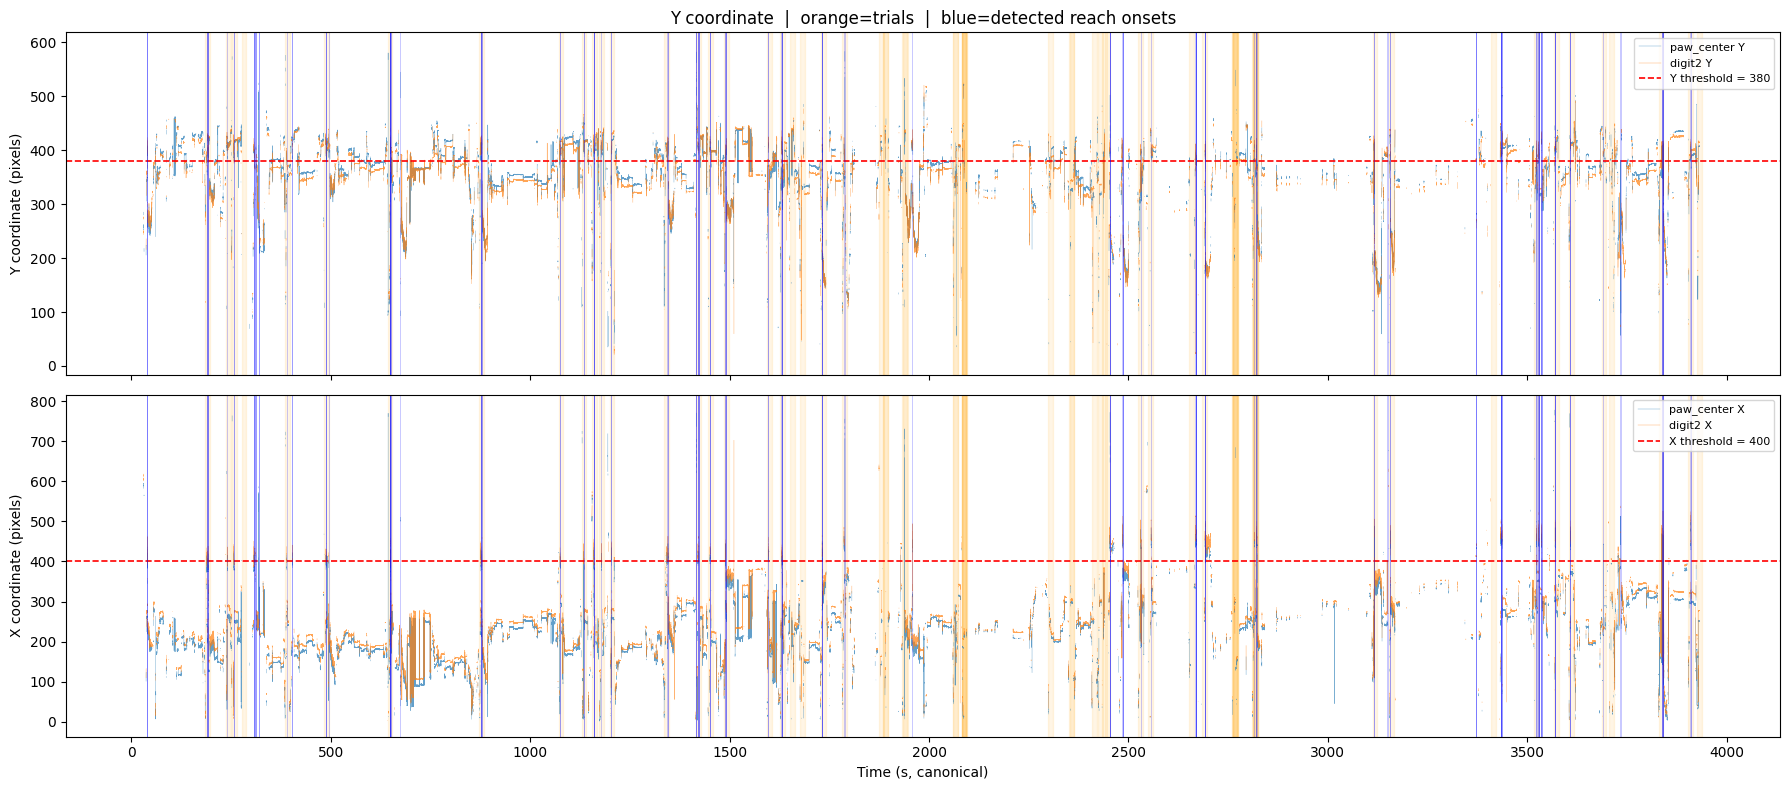

Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\reach_detection_overview.png


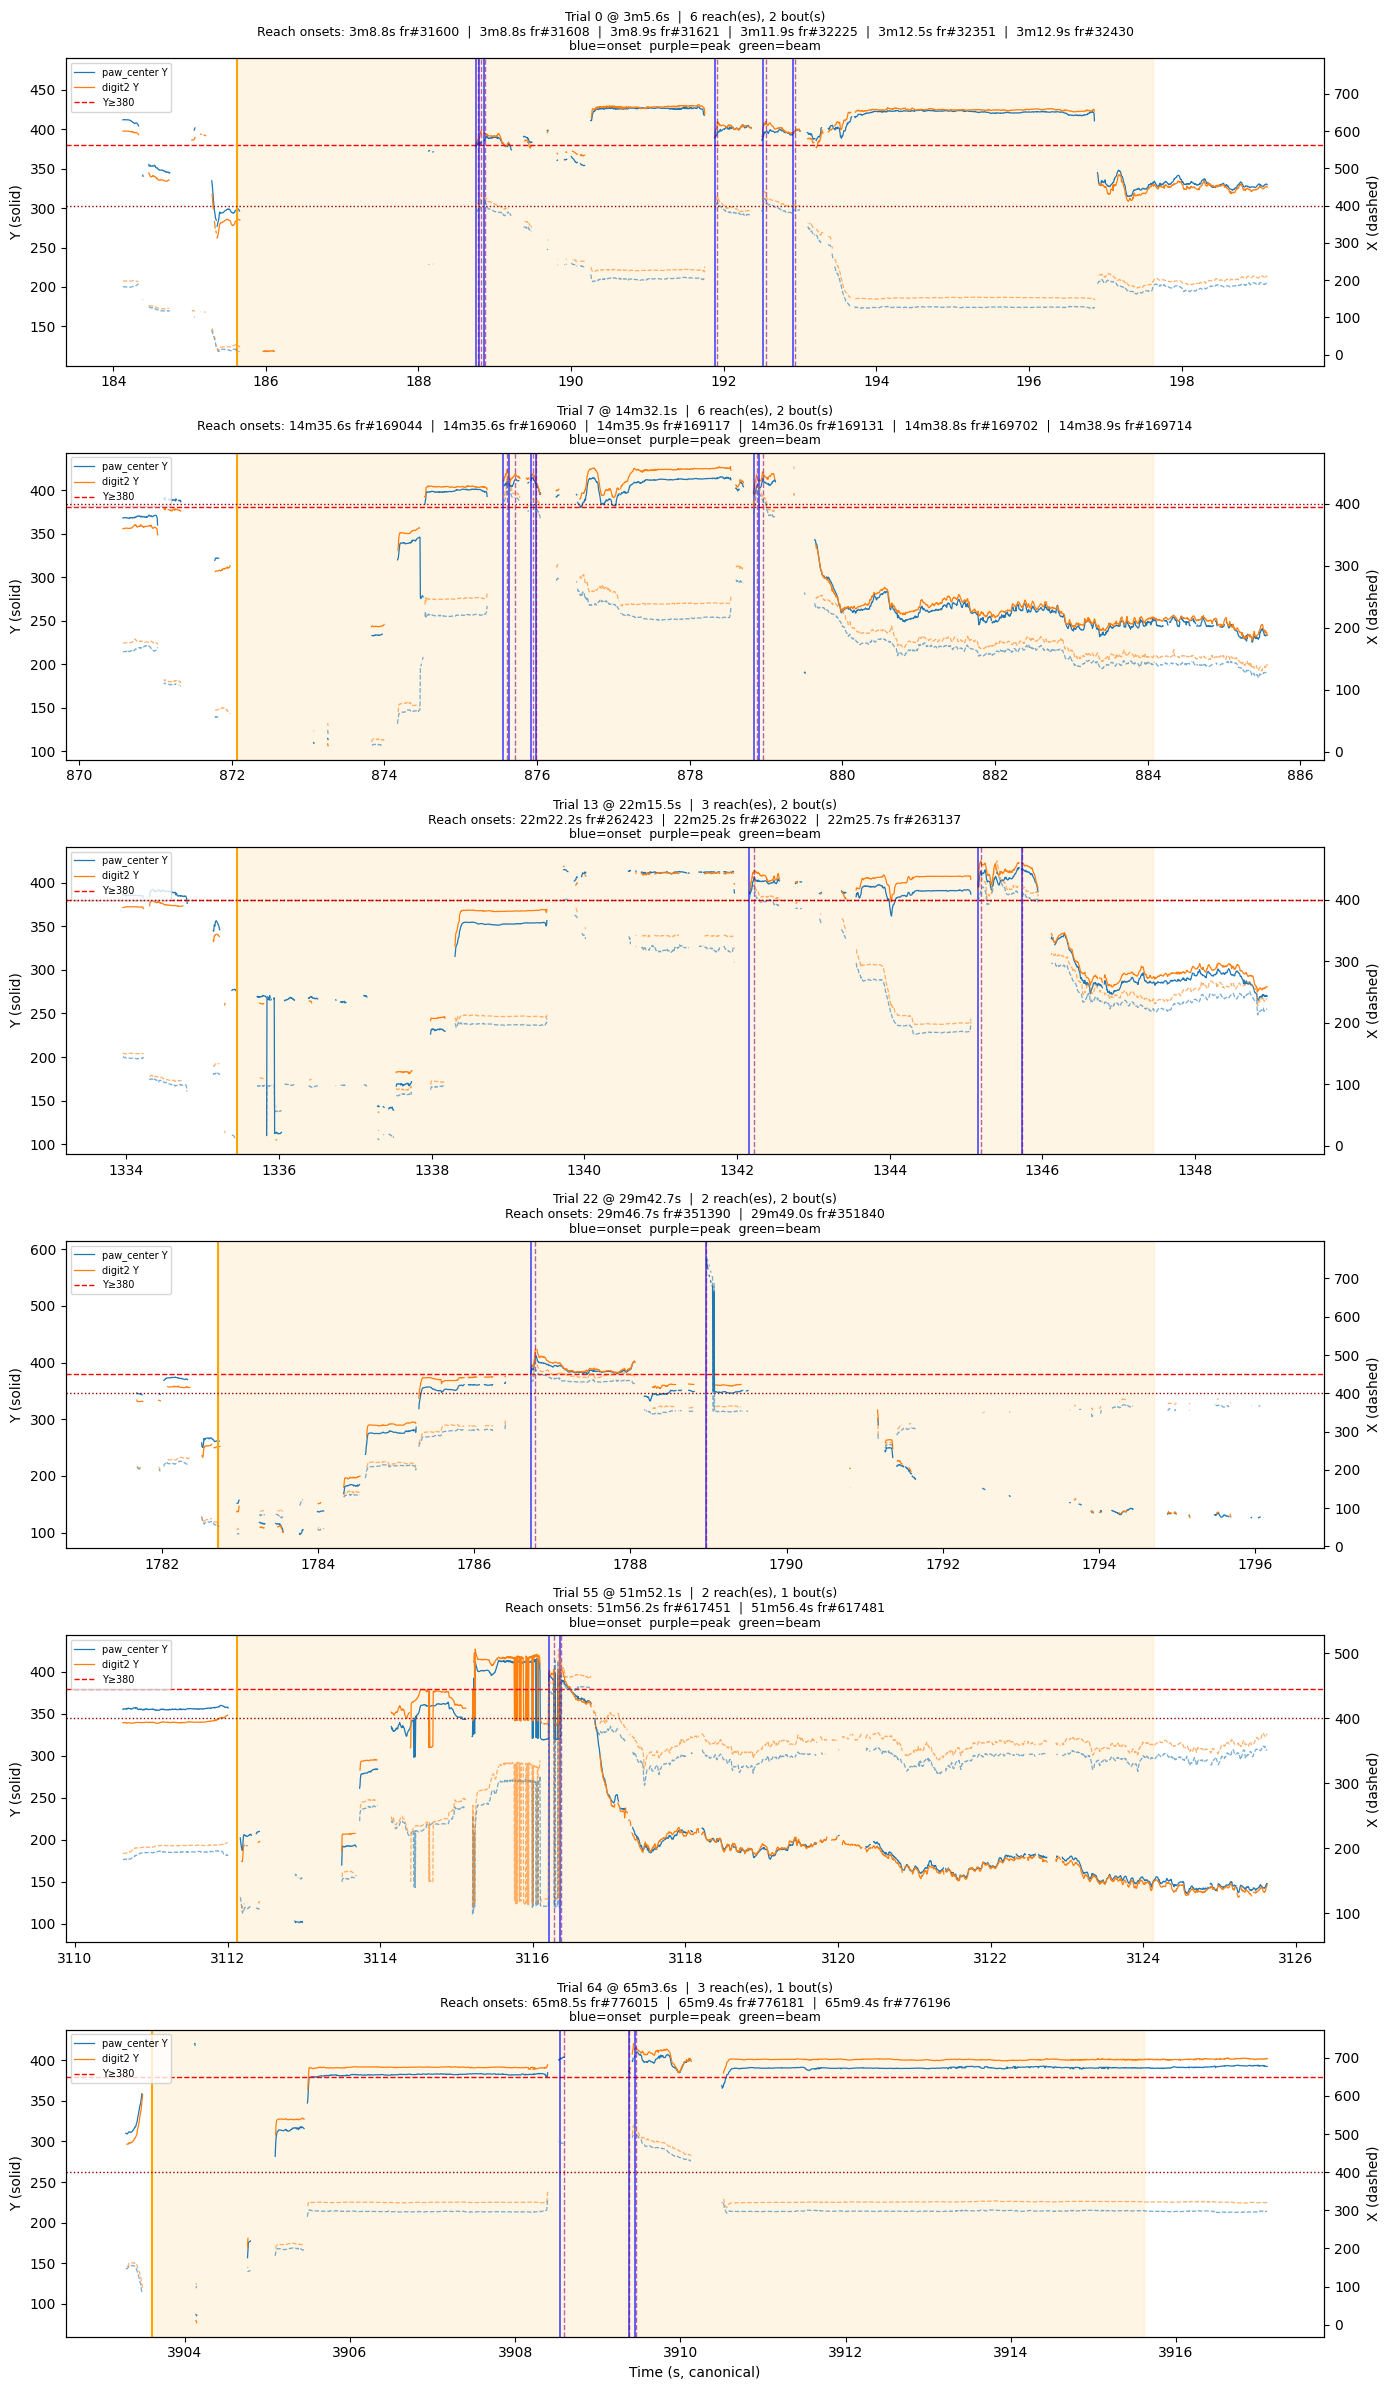

Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\reach_detection_trials.png

===== SUMMARY =====
  Reach zone:            Y > 380  AND  X > 400
  Min frames in zone:    5 (~25ms)
  Total reaches:         163
  Bouts:                 66
  In-trial bouts:        47 / 66 trials
  Trials with ≥1 reach:  33 / 66
  Out-of-trial bouts:    19
  Beam-breaking bouts:   1

Adjust REACH_Y_MIN / REACH_X_MIN and rerun if counts look wrong.

===== CELL J COMPLETE =====



In [24]:
# ============================================================
# CELL J — REACH DETECTION (PORTABLE) — absolute pixel v1
# ============================================================
# Reach criterion (from video inspection):
#   paw_center OR digit2 must be in the reach zone:
#     y > REACH_Y_MIN  (paw elevated)
#     x > REACH_X_MIN  (paw forward toward pellet)
#   Both x and y conditions must hold simultaneously.
#   At least MIN_FRAMES_IN_ZONE consecutive frames required
#   to count as a real reach (filters single-frame noise).
#
# Trial structure (freely moving rig):
#   - trial_start = back beam break (pin 4)
#   - trial_end   = trial_start + TRIAL_WINDOW_S
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL J — REACH DETECTION (absolute pixel) =====")

# ------------------------------------------------------------
# USER EDIT — reach zone in pixel coordinates
# ------------------------------------------------------------
REACH_Y_MIN = 380
REACH_X_MIN = 400

MARKERS = ["paw_center", "digit2"]

PAW_LIKELIHOOD_MIN = 0.50
MIN_FRAMES_IN_ZONE = 5    # ~25ms at 200Hz
MERGE_WINDOW_S     = 0.8

BACK_BEAM_PIN  = 4
IR_BEAM_PIN    = 6
TRIAL_WINDOW_S = 12.0
IR_BEAM_TOL_S  = 0.5
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# ------------------------------------------------------------
# LOAD DLC
# ------------------------------------------------------------
dlc      = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
frame_t  = dlc["canonical_time"]
n_frames = len(frame_t)
fps      = 1.0 / float(np.median(np.diff(frame_t)))
print(f"Loaded {n_frames} frames, FPS={fps:.1f}")

available_bps = [k.replace("_x", "") for k in dlc.files if k.endswith("_x")]
print(f"Available bodyparts: {available_bps}")

# ------------------------------------------------------------
# LOAD EVENTS
# ------------------------------------------------------------
ttls_dir    = analysis_folder / "ttls"
back_beam_t = np.load(ttls_dir / f"TTL_Pin_{BACK_BEAM_PIN}.npy")
beam_t      = np.load(ttls_dir / f"TTL_Pin_{IR_BEAM_PIN}.npy")

trial_starts = back_beam_t
trial_ends   = back_beam_t + TRIAL_WINDOW_S
print(f"Trials: {len(trial_starts)}")
print(f"IR beam breaks (pin {IR_BEAM_PIN}): {len(beam_t)}")

# ------------------------------------------------------------
# BUILD IN-ZONE MASK
# ------------------------------------------------------------
in_zone     = np.zeros(n_frames, dtype=bool)
marker_data = {}

for bp in MARKERS:
    x_key   = f"{bp}_x"
    y_key   = f"{bp}_y"
    lik_key = f"{bp}_likelihood"

    if x_key not in dlc.files:
        print(f"  WARNING: '{bp}' not in DLC file — skipping.")
        continue

    x   = dlc[x_key].astype(float)
    y   = dlc[y_key].astype(float)
    lik = dlc[lik_key].astype(float)

    good_lik   = lik >= PAW_LIKELIHOOD_MIN
    in_zone_bp = good_lik & (x > REACH_X_MIN) & (y > REACH_Y_MIN)
    in_zone   |= in_zone_bp

    n_in = int(in_zone_bp.sum())
    print(f"  {bp}: {n_in} frames in zone ({100.0*n_in/n_frames:.2f}%)")
    marker_data[bp] = {"x": x, "y": y, "lik": lik, "in_zone": in_zone_bp}

print(f"\nTotal frames in zone (any marker): {in_zone.sum()} "
      f"({100*in_zone.sum()/n_frames:.2f}%)")

# ------------------------------------------------------------
# REQUIRE MIN_FRAMES_IN_ZONE CONSECUTIVE FRAMES
# ------------------------------------------------------------
padded = np.concatenate([[False], in_zone, [False]])
diffs  = np.diff(padded.astype(int))
run_starts_raw = np.where(diffs ==  1)[0]
run_ends_raw   = np.where(diffs == -1)[0] - 1

in_zone_filtered = np.zeros(n_frames, dtype=bool)
for rs, re in zip(run_starts_raw, run_ends_raw):
    if (re - rs + 1) >= MIN_FRAMES_IN_ZONE:
        in_zone_filtered[rs : re + 1] = True

padded2 = np.concatenate([[False], in_zone_filtered, [False]])
diffs2  = np.diff(padded2.astype(int))
run_starts = np.where(diffs2 ==  1)[0]
run_ends   = np.where(diffs2 == -1)[0] - 1

print(f"After ≥{MIN_FRAMES_IN_ZONE}-frame filter: "
      f"{in_zone_filtered.sum()} frames in zone, "
      f"{len(run_starts)} separate runs")

# ------------------------------------------------------------
# EXTRACT ONE REACH PER RUN
# ------------------------------------------------------------
reach_onset_t     = []
reach_peak_t      = []
reach_frame_onset = []
reach_frame_peak  = []
reach_max_y       = []

for rs, re in zip(run_starts, run_ends):
    onset_idx = rs
    best_y = np.full(re - rs + 1, -np.inf)
    for bp, d in marker_data.items():
        good        = d["lik"][rs:re+1] >= PAW_LIKELIHOOD_MIN
        y_seg       = d["y"][rs:re+1]
        y_seg_masked = np.where(good, y_seg, -np.inf)
        best_y      = np.maximum(best_y, y_seg_masked)
    peak_local = int(np.argmax(best_y))
    peak_idx   = rs + peak_local

    reach_onset_t.append(float(frame_t[onset_idx]))
    reach_peak_t.append(float(frame_t[peak_idx]))
    reach_frame_onset.append(int(onset_idx))
    reach_frame_peak.append(int(peak_idx))
    reach_max_y.append(float(best_y[peak_local]))

reach_onset_t     = np.array(reach_onset_t)
reach_peak_t      = np.array(reach_peak_t)
reach_frame_onset = np.array(reach_frame_onset, dtype=int)
reach_frame_peak  = np.array(reach_frame_peak, dtype=int)
reach_max_y       = np.array(reach_max_y)
print(f"\nDetected reaches: {len(reach_onset_t)}")

# ------------------------------------------------------------
# BOUT CLUSTERING
# ------------------------------------------------------------
if len(reach_onset_t) > 1:
    bout_id = np.zeros(len(reach_onset_t), dtype=int)
    for i in range(1, len(reach_onset_t)):
        if reach_onset_t[i] - reach_peak_t[i-1] <= MERGE_WINDOW_S:
            bout_id[i] = bout_id[i-1]
        else:
            bout_id[i] = bout_id[i-1] + 1
    n_bouts = int(bout_id.max()) + 1
elif len(reach_onset_t) == 1:
    bout_id = np.array([0], dtype=int)
    n_bouts = 1
else:
    bout_id = np.array([], dtype=int)
    n_bouts = 0
print(f"Bouts: {n_bouts}")

# ------------------------------------------------------------
# TRIAL TAGGING
# ------------------------------------------------------------
reach_trial_id = np.full(len(reach_onset_t), -1, dtype=int)
for t_i, (ts, te) in enumerate(zip(trial_starts, trial_ends)):
    m = (reach_onset_t >= ts) & (reach_onset_t <= te)
    reach_trial_id[m] = t_i

# ------------------------------------------------------------
# BEAM TAGGING
# ------------------------------------------------------------
reach_broke_beam = np.zeros(len(reach_peak_t), dtype=bool)
for i, t_pk in enumerate(reach_peak_t):
    if len(beam_t) and np.any(np.abs(beam_t - t_pk) < IR_BEAM_TOL_S):
        reach_broke_beam[i] = True

# ------------------------------------------------------------
# BOUT SUMMARY
# ------------------------------------------------------------
bout_onset_t    = np.zeros(n_bouts)
bout_peak_t     = np.zeros(n_bouts)
bout_max_amp    = np.zeros(n_bouts)
bout_n_reaches  = np.zeros(n_bouts, dtype=int)
bout_trial_id   = np.full(n_bouts, -1, dtype=int)
bout_broke_beam = np.zeros(n_bouts, dtype=bool)

for b in range(n_bouts):
    m = bout_id == b
    bout_onset_t[b]    = reach_onset_t[m].min()
    bout_max_amp[b]    = reach_max_y[m].max()
    bout_peak_t[b]     = reach_peak_t[m][np.argmax(reach_max_y[m])]
    bout_n_reaches[b]  = int(m.sum())
    bout_trial_id[b]   = reach_trial_id[m][0]
    bout_broke_beam[b] = bool(reach_broke_beam[m].any())

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
out_dir = analysis_folder / "peak_detection"
out_dir.mkdir(exist_ok=True)

np.savez(out_dir / "reaches.npz",
         onset_t=reach_onset_t,
         peak_t=reach_peak_t,
         max_y=reach_max_y,
         frame_onset=reach_frame_onset,
         frame_peak=reach_frame_peak,
         bout_id=bout_id,
         trial_id=reach_trial_id,
         broke_beam=reach_broke_beam)

np.savez(out_dir / "bouts.npz",
         onset_t=bout_onset_t,
         peak_t=bout_peak_t,
         max_amplitude=bout_max_amp,
         n_reaches=bout_n_reaches,
         trial_id=bout_trial_id,
         broke_beam=bout_broke_beam)

np.save(out_dir / "in_zone_mask.npy", in_zone_filtered)

frame_valid = np.zeros(n_frames, dtype=bool)
for bp, d in marker_data.items():
    frame_valid |= d["lik"] >= PAW_LIKELIHOOD_MIN
np.save(out_dir / "frame_valid.npy", frame_valid)

if "paw_center" in marker_data:
    np.save(out_dir / "running_baseline.npy",
            marker_data["paw_center"]["x"].astype(float))
else:
    first_bp = list(marker_data.keys())[0]
    np.save(out_dir / "running_baseline.npy",
            marker_data[first_bp]["x"].astype(float))

import json as _json
trials_with_reaches = np.unique(reach_trial_id[reach_trial_id >= 0])
meta = {
    "method":              "absolute_pixel_threshold",
    "reach_y_min":         int(REACH_Y_MIN),
    "reach_x_min":         int(REACH_X_MIN),
    "markers":             MARKERS,
    "likelihood_min":      float(PAW_LIKELIHOOD_MIN),
    "min_frames_in_zone":  int(MIN_FRAMES_IN_ZONE),
    "merge_window_s":      float(MERGE_WINDOW_S),
    "trial_window_s":      float(TRIAL_WINDOW_S),
    "back_beam_pin":       int(BACK_BEAM_PIN),
    "ir_beam_pin":         int(IR_BEAM_PIN),
    "n_reaches":           int(len(reach_onset_t)),
    "n_bouts":             int(n_bouts),
    "n_in_trial":          int((reach_trial_id >= 0).sum()),
    "n_out_of_trial":      int((reach_trial_id == -1).sum()),
    "n_beam_breaking":     int(reach_broke_beam.sum()),
    "n_bouts_in_trial":    int((bout_trial_id >= 0).sum()),
    "trial_count":         int(len(trial_starts)),
    "trials_with_reaches": int(len(trials_with_reaches)),
}
with open(out_dir / "reaches_meta.json", "w") as f:
    _json.dump(meta, f, indent=2)

print(f"\nSaved reaches → {out_dir / 'reaches.npz'}")
print(f"Saved bouts   → {out_dir / 'bouts.npz'}")

# ------------------------------------------------------------
# HELPER: format canonical time as Xm Y.Ys
# ------------------------------------------------------------
def fmt_time(t):
    mins = int(t // 60)
    secs = t % 60
    return f"{mins}m{secs:.1f}s"

# ------------------------------------------------------------
# DIAGNOSTIC PLOT 1: full session overview
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

ax = axes[0]
for bp, d in marker_data.items():
    y_masked = d["y"].copy().astype(float)
    y_masked[d["lik"] < PAW_LIKELIHOOD_MIN] = np.nan
    ax.plot(frame_t, y_masked, lw=0.3, alpha=0.7, label=f"{bp} Y")
ax.axhline(REACH_Y_MIN, color="red", lw=1.2, linestyle="--",
           label=f"Y threshold = {REACH_Y_MIN}")
for ts, te in zip(trial_starts, trial_ends):
    ax.axvspan(ts, te, alpha=0.10, color="orange")
for t in reach_onset_t:
    ax.axvline(t, color="blue", alpha=0.3, lw=0.5)
ax.set_ylabel("Y coordinate (pixels)")
ax.set_title("Y coordinate  |  orange=trials  |  blue=detected reach onsets")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
for bp, d in marker_data.items():
    x_masked = d["x"].copy().astype(float)
    x_masked[d["lik"] < PAW_LIKELIHOOD_MIN] = np.nan
    ax.plot(frame_t, x_masked, lw=0.3, alpha=0.7, label=f"{bp} X")
ax.axhline(REACH_X_MIN, color="red", lw=1.2, linestyle="--",
           label=f"X threshold = {REACH_X_MIN}")
for ts, te in zip(trial_starts, trial_ends):
    ax.axvspan(ts, te, alpha=0.10, color="orange")
for t in reach_onset_t:
    ax.axvline(t, color="blue", alpha=0.3, lw=0.5)
ax.set_ylabel("X coordinate (pixels)")
ax.set_xlabel("Time (s, canonical)")
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
out_path = analysis_folder / "qc" / "reach_detection_overview.png"
fig.savefig(out_path, dpi=150)
plt.show()
print(f"Saved → {out_path}")

# ------------------------------------------------------------
# DIAGNOSTIC PLOT 2: zoom on individual trials
# ------------------------------------------------------------
n_plot = min(6, len(trials_with_reaches))
if n_plot > 0:
    plot_t_idx = trials_with_reaches[
        np.linspace(0, len(trials_with_reaches) - 1, n_plot).astype(int)
    ]
    fig, axes = plt.subplots(n_plot, 1,
                             figsize=(14, 4.0 * n_plot), sharey=False)
    if n_plot == 1:
        axes = [axes]

    for ax, t_i in zip(axes, plot_t_idx):
        ts, te = trial_starts[t_i], trial_ends[t_i]
        pad = 1.5
        zm  = (frame_t >= ts - pad) & (frame_t <= te + pad)
        ax2 = ax.twinx()

        for bp, d in marker_data.items():
            y_m = d["y"].copy().astype(float)
            x_m = d["x"].copy().astype(float)
            y_m[d["lik"] < PAW_LIKELIHOOD_MIN] = np.nan
            x_m[d["lik"] < PAW_LIKELIHOOD_MIN] = np.nan
            ax.plot(frame_t[zm], y_m[zm], lw=0.9, label=f"{bp} Y")
            ax2.plot(frame_t[zm], x_m[zm], lw=0.9, linestyle="--",
                     alpha=0.6, label=f"{bp} X")

        ax.axhline(REACH_Y_MIN, color="red", lw=1.0, linestyle="--",
                   label=f"Y≥{REACH_Y_MIN}")
        ax2.axhline(REACH_X_MIN, color="darkred", lw=1.0, linestyle=":",
                    label=f"X≥{REACH_X_MIN}")
        ax.axvspan(ts, te, alpha=0.10, color="orange")
        ax.axvline(ts, color="orange", lw=1.5)

        in_t = reach_trial_id == t_i
        for t_on, f_on in zip(reach_onset_t[in_t], reach_frame_onset[in_t]):
            ax.axvline(t_on, color="blue", lw=1.2, alpha=0.7)
        for t_pk, f_pk in zip(reach_peak_t[in_t], reach_frame_peak[in_t]):
            ax.axvline(t_pk, color="purple", lw=1.0, linestyle="--", alpha=0.6)
        for bt in beam_t[(beam_t >= ts - pad) & (beam_t <= te + pad)]:
            ax.axvline(bt, color="green", lw=1.0, alpha=0.5)

        # Build reach info string: time as Xm Y.Ys + frame number
        in_t_onsets = reach_onset_t[in_t]
        in_t_frames = reach_frame_onset[in_t]
        reach_strs  = [f"{fmt_time(t)} fr#{f}"
                       for t, f in zip(in_t_onsets, in_t_frames)]
        reach_info  = "  |  ".join(reach_strs) if reach_strs else "none"

        n_r       = int(in_t.sum())
        bout_in_t = np.where(bout_trial_id == t_i)[0]

        ax.set_title(
            f"Trial {t_i} @ {fmt_time(ts)}  |  "
            f"{n_r} reach(es), {len(bout_in_t)} bout(s)\n"
            f"Reach onsets: {reach_info}\n"
            f"blue=onset  purple=peak  green=beam",
            fontsize=9
        )
        ax.set_ylabel("Y (solid)")
        ax2.set_ylabel("X (dashed)")
        ax.legend(fontsize=7, loc="upper left")

    axes[-1].set_xlabel("Time (s, canonical)")
    plt.tight_layout()
    out_path2 = analysis_folder / "qc" / "reach_detection_trials.png"
    fig.savefig(out_path2, dpi=150)
    plt.show()
    print(f"Saved → {out_path2}")

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
print("\n===== SUMMARY =====")
print(f"  Reach zone:            Y > {REACH_Y_MIN}  AND  X > {REACH_X_MIN}")
print(f"  Min frames in zone:    {MIN_FRAMES_IN_ZONE} (~{1000*MIN_FRAMES_IN_ZONE/fps:.0f}ms)")
print(f"  Total reaches:         {len(reach_onset_t)}")
print(f"  Bouts:                 {n_bouts}")
print(f"  In-trial bouts:        {(bout_trial_id >= 0).sum()} / {len(trial_starts)} trials")
print(f"  Trials with ≥1 reach:  {len(trials_with_reaches)} / {len(trial_starts)}")
print(f"  Out-of-trial bouts:    {(bout_trial_id == -1).sum()}")
print(f"  Beam-breaking bouts:   {bout_broke_beam.sum()}")
print()
print("Adjust REACH_Y_MIN / REACH_X_MIN and rerun if counts look wrong.")
print("\n===== CELL J COMPLETE =====\n")


===== CELL L v4 — REACH-LOCKED PETH (CFA vs VAL) =====
Subset: in_trial  |  N events: 47
Eligible units: 174  (CFA=78, VAL=37, WM=59)

Building null (200 shuffles)...
  50/200
  100/200
  150/200
  200/200
Calibrated Z threshold: 2.75  (shuffled FPR = 6.9%)

Computing real PSTHs (47 events)...
Modulated: 123 / 174
  CFA: 55 / 78
  VAL: 27 / 37


C:\Users\kkost\AppData\Local\Temp\ipykernel_5936\1318124036.py:392: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


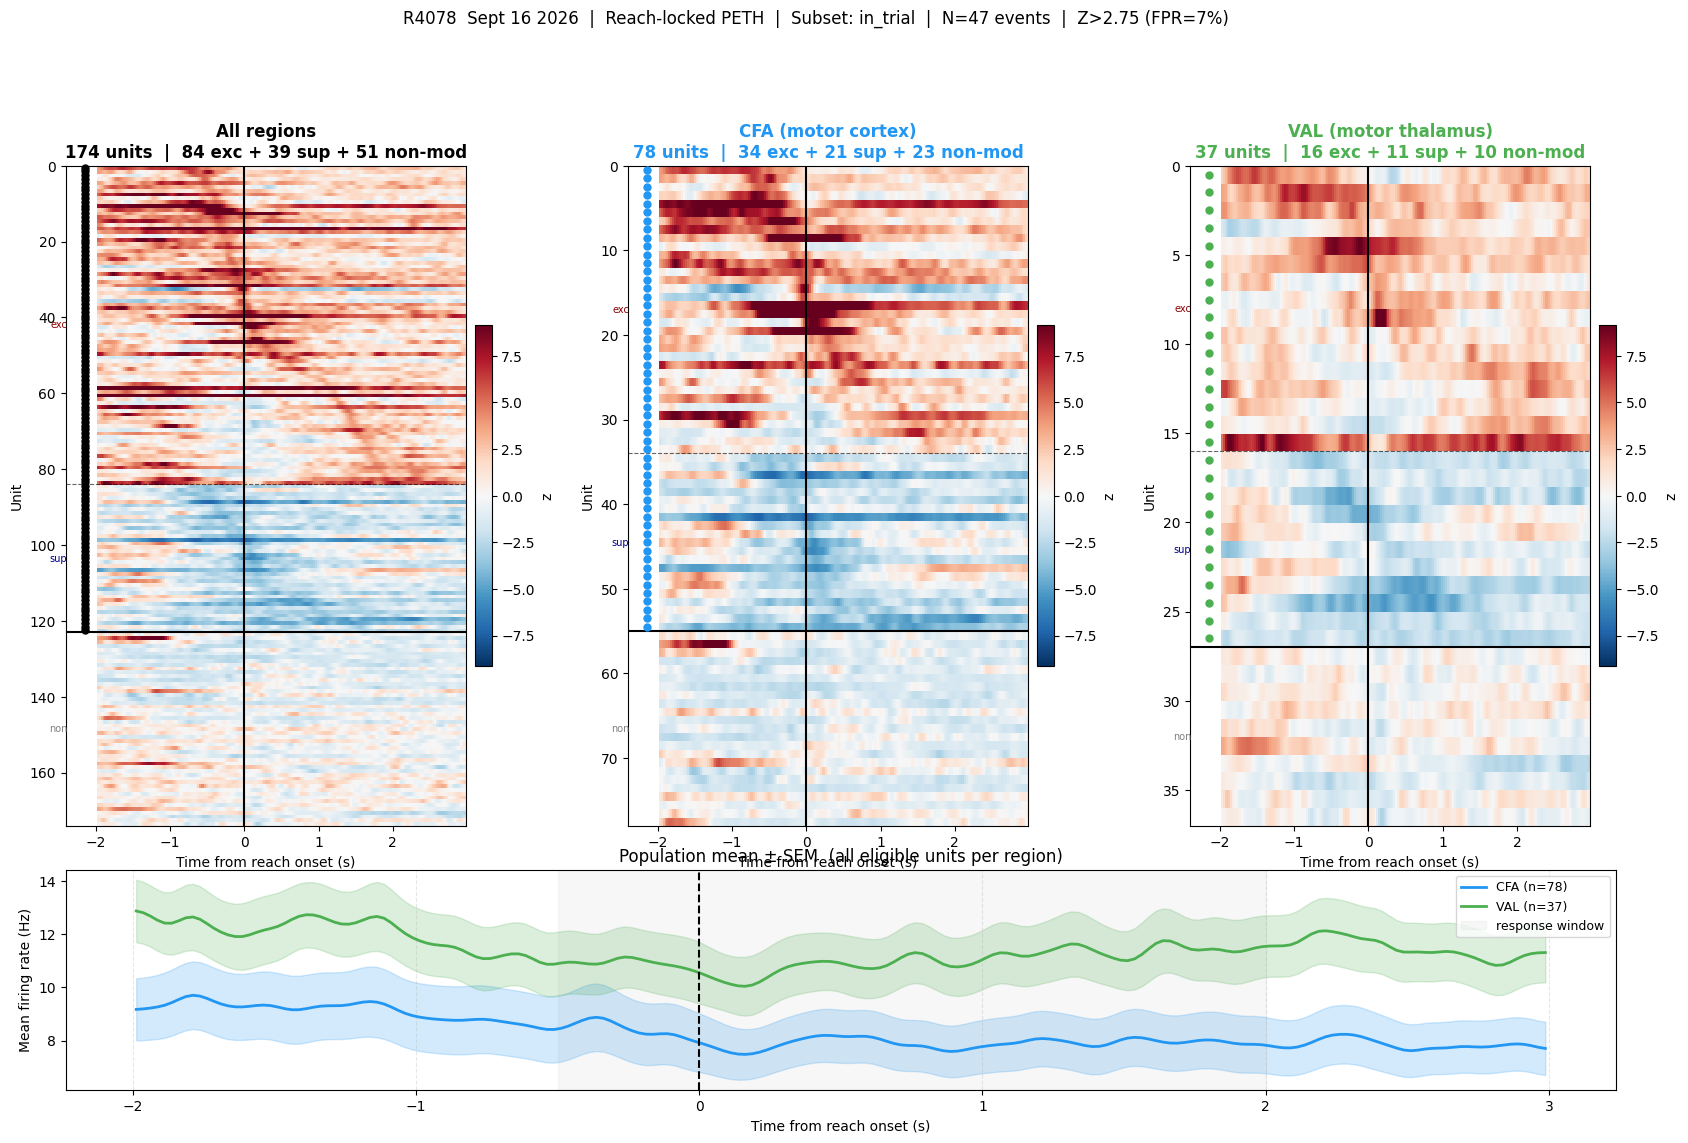


Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\reach_PETH_CFA_VAL_in_trial_v4.png
Saved arrays → reach_good_in_trial_arrays.npz

===== SUMMARY =====
  N reach events:            47
  Eligible units:            174
    CFA:                     78
    VAL:                     37
  Z threshold:               2.75
  Shuffled FPR:              6.9%
  Modulated CFA:             55 / 78
    excited:                 34
    suppressed:              21
  Modulated VAL:             27 / 37
    excited:                 16
    suppressed:              11

===== CELL L v4 COMPLETE =====



In [25]:
# ============================================================
# CELL L — REACH-LOCKED PETH WITH REGION SPLIT (PORTABLE) v4
# ============================================================
# Sort order per panel:
#   1. Excited modulated units — sorted by peak latency (earliest first)
#   2. Suppressed modulated units — sorted by peak latency
#   3. Non-modulated units — sorted by depth (surface → deep)
#
# Dashed line between excited/suppressed.
# Solid line between modulated/non-modulated.
#
# Subset: all in-trial reaches.
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL L v4 — REACH-LOCKED PETH (CFA vs VAL) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
PROBEA_PATH = (
    r"G:\Neuropixels data-motor project\freely moving"
    r"\2026-09-16_13-21-12\Record Node 101"
    r"\experiment2\recording1\continuous"
    r"\Neuropix-PXI-100.ProbeA-AP\kilosort4"
)

SUBSET_NAME        = "in_trial"
WIN_PRE            = 2.0
WIN_POST           = 3.0
RESPONSE_WIN       = (-0.5, 2.0)
BIN_SIZE           = 0.025
SMOOTH_SIGMA_BINS  = 2
MIN_CONSECUTIVE_MS = 80
MIN_BASELINE_HZ    = 0.5
CONSISTENCY_FRAC   = 0.25
N_SHUFFLES_CALIB   = 200
TARGET_FPR         = 0.10
RANDOM_SEED        = 42

TIP_DV_UM = 5429.0
REGION_BOUNDS = {
    "CFA": (0,    1300),
    "WM":  (1300, 3500),
    "VAL": (3500, 4500),
}
REGION_COLORS = {"CFA": "#2196F3", "VAL": "#4CAF50", "WM": "#9E9E9E"}

EXCLUDE_UNITS = [130, 343]
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD REGION ASSIGNMENTS
# ------------------------------------------------------------
ci = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
good_ci = ci[ci["group"].str.lower() == "good"].copy()
good_ci["dv_depth"] = TIP_DV_UM - good_ci["depth"].astype(float)

def get_region(dv):
    for name, (lo, hi) in REGION_BOUNDS.items():
        if lo <= dv < hi:
            return name
    return "deep"

good_ci["region"] = good_ci["dv_depth"].apply(get_region)
uid_to_region = dict(zip(good_ci["id"].astype(int), good_ci["region"]))
uid_to_dv     = dict(zip(good_ci["id"].astype(int), good_ci["dv_depth"]))

# ------------------------------------------------------------
# LOAD BOUT EVENTS
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t  = bouts["onset_t"]
bout_trial_id = bouts["trial_id"]

if SUBSET_NAME == "in_trial":
    mask = bout_trial_id >= 0
elif SUBSET_NAME == "in_trial_first":
    mask = np.zeros(len(bout_onset_t), dtype=bool)
    for t_i in np.unique(bout_trial_id):
        if t_i == -1:
            continue
        ii = np.where(bout_trial_id == t_i)[0]
        mask[ii[np.argmin(bout_onset_t[ii])]] = True
elif SUBSET_NAME == "all":
    mask = np.ones(len(bout_onset_t), dtype=bool)
else:
    raise ValueError(f"Unknown SUBSET_NAME: {SUBSET_NAME}")

event_times = np.sort(bout_onset_t[mask])
n_events    = len(event_times)
print(f"Subset: {SUBSET_NAME}  |  N events: {n_events}")
if n_events < 5:
    raise RuntimeError(f"Too few events ({n_events}) — check Cell J output.")

# ------------------------------------------------------------
# LOAD UNITS + ASSIGN REGIONS
# ------------------------------------------------------------
good_units_all = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir     = analysis_folder / "spikes"

all_spikes  = {}
unit_dv     = {}
unit_region = {}

for u in good_units_all:
    uid = int(u)
    if uid in EXCLUDE_UNITS:
        continue
    spk_path = spikes_dir / f"unit_{uid}.npy"
    if not spk_path.exists():
        continue
    spk  = np.load(spk_path)
    rate = len(spk) / recording_duration
    if rate < MIN_BASELINE_HZ:
        continue
    all_spikes[uid]  = spk
    unit_region[uid] = uid_to_region.get(uid, "deep")
    unit_dv[uid]     = uid_to_dv.get(uid, 9999.0)

# Sort eligible units by DV depth
eligible_units = np.array(sorted(all_spikes.keys()))
eligible_units = eligible_units[
    np.argsort([unit_dv.get(u, 9999) for u in eligible_units])
]

cfa_mask = np.array([unit_region.get(int(u)) == "CFA" for u in eligible_units])
val_mask = np.array([unit_region.get(int(u)) == "VAL" for u in eligible_units])
wm_mask  = np.array([unit_region.get(int(u)) == "WM"  for u in eligible_units])

n_cfa = int(cfa_mask.sum())
n_val = int(val_mask.sum())
print(f"Eligible units: {len(eligible_units)}  "
      f"(CFA={n_cfa}, VAL={n_val}, WM={int(wm_mask.sum())})")

# ------------------------------------------------------------
# PSTH HELPERS
# ------------------------------------------------------------
edges   = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins  = len(centers)
response_mask   = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))
rng = np.random.default_rng(RANDOM_SEED)

def compute_psth_mean(events):
    out = np.zeros((len(eligible_units), n_bins))
    for u_i, u in enumerate(eligible_units):
        spk   = all_spikes[int(u)]
        h_sum = np.zeros(n_bins)
        for t_evt in events:
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            h_sum += h / BIN_SIZE
        out[u_i] = h_sum / len(events)
    return gaussian_filter1d(out, sigma=SMOOTH_SIGMA_BINS, axis=1)

def count_modulated(z_mat, z_thresh):
    z_r = z_mat[:, response_mask]
    out = np.zeros(len(eligible_units), dtype=bool)
    for i in range(len(eligible_units)):
        for arr in (z_r[i] > z_thresh, z_r[i] < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            d = np.diff(padded.astype(int))
            s = np.where(d ==  1)[0]
            e = np.where(d == -1)[0]
            if (e - s).max() >= min_consec_bins:
                out[i] = True
                break
    return out

# ------------------------------------------------------------
# NULL DISTRIBUTION
# ------------------------------------------------------------
print(f"\nBuilding null ({N_SHUFFLES_CALIB} shuffles)...")
t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0
shuffled_psths = np.zeros((N_SHUFFLES_CALIB, len(eligible_units), n_bins))

for s in range(N_SHUFFLES_CALIB):
    fake = np.sort(rng.uniform(t_min, t_max, size=n_events))
    shuffled_psths[s] = compute_psth_mean(fake)
    if (s + 1) % 50 == 0:
        print(f"  {s+1}/{N_SHUFFLES_CALIB}")

null_mean = shuffled_psths.mean(axis=0)
null_std  = shuffled_psths.std(axis=0)
null_std  = np.maximum(null_std, null_mean * 0.01 + 0.05)

# ------------------------------------------------------------
# CALIBRATE Z THRESHOLD
# ------------------------------------------------------------
z_thresh_grid = np.arange(1.5, 5.01, 0.25)
shuffled_fpr  = np.zeros((N_SHUFFLES_CALIB, len(z_thresh_grid)))
for s in range(N_SHUFFLES_CALIB):
    z_s = (shuffled_psths[s] - null_mean) / null_std
    for j, thr in enumerate(z_thresh_grid):
        shuffled_fpr[s, j] = count_modulated(z_s, thr).mean()

mean_fpr = shuffled_fpr.mean(axis=0)
viable   = np.where(mean_fpr <= TARGET_FPR)[0]
z_thresh = float(z_thresh_grid[viable[0]] if len(viable) else z_thresh_grid[-1])
calibrated_fpr = float(mean_fpr[np.argmin(np.abs(z_thresh_grid - z_thresh))])
print(f"Calibrated Z threshold: {z_thresh:.2f}  "
      f"(shuffled FPR = {calibrated_fpr*100:.1f}%)")

# ------------------------------------------------------------
# REAL PSTHs + Z-SCORE
# ------------------------------------------------------------
print(f"\nComputing real PSTHs ({n_events} events)...")
real_psth = compute_psth_mean(event_times)
real_z    = (real_psth - null_mean) / null_std

modulated = count_modulated(real_z, z_thresh)

# Peak z and latency
z_resp   = real_z[:, response_mask]
peak_idx = np.argmax(np.abs(z_resp), axis=1)
peak_lat = centers[response_mask][peak_idx]
peak_z   = z_resp[np.arange(len(eligible_units)), peak_idx]

print(f"Modulated: {modulated.sum()} / {len(eligible_units)}")
print(f"  CFA: {(modulated & cfa_mask).sum()} / {n_cfa}")
print(f"  VAL: {(modulated & val_mask).sum()} / {n_val}")

# ------------------------------------------------------------
# SORT FUNCTION
# Excited modulated (by latency) → suppressed modulated (by latency)
# → non-modulated (by depth, already in eligible_units order)
# ------------------------------------------------------------
def make_sort_order(unit_mask):
    """Returns sorted local indices into eligible_units[unit_mask]."""
    idx = np.where(unit_mask)[0]   # global indices into eligible_units

    mod_here    = modulated[idx]
    exc_here    = mod_here & (peak_z[idx] > 0)
    sup_here    = mod_here & (peak_z[idx] <= 0)
    nonmod_here = ~mod_here

    exc_local    = np.where(exc_here)[0]
    sup_local    = np.where(sup_here)[0]
    nonmod_local = np.where(nonmod_here)[0]

    resp_ctrs = centers[response_mask]

    # Sort excited by peak latency
    if len(exc_local) > 0:
        lat_exc = resp_ctrs[np.argmax(np.abs(z_resp[idx[exc_local]]), axis=1)]
        exc_order = exc_local[np.argsort(lat_exc)]
    else:
        exc_order = exc_local

    # Sort suppressed by peak latency
    if len(sup_local) > 0:
        lat_sup = resp_ctrs[np.argmax(np.abs(z_resp[idx[sup_local]]), axis=1)]
        sup_order = sup_local[np.argsort(lat_sup)]
    else:
        sup_order = sup_local

    # Non-modulated stay in depth order (already sorted)
    final_local = np.concatenate([exc_order, sup_order, nonmod_local])
    return idx[final_local], len(exc_order), len(sup_order)

# ------------------------------------------------------------
# DRAW HEATMAP
# ------------------------------------------------------------
vmax = max(3.0, float(np.percentile(np.abs(real_z), 98)))

def draw_heatmap(ax, unit_mask, title, color, region_label):
    if unit_mask.sum() == 0:
        ax.text(0.5, 0.5, f"No {region_label} units",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    final_idx, n_exc, n_sup = make_sort_order(unit_mask)
    n_mod    = n_exc + n_sup
    n_total  = len(final_idx)
    z_sub    = real_z[final_idx]

    im = ax.imshow(z_sub, aspect="auto",
                   extent=[centers[0], centers[-1], n_total, 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.5)

    # Dashed line between excited and suppressed
    if n_exc > 0 and n_sup > 0:
        ax.axhline(n_exc, color="black", lw=0.8, linestyle="--", alpha=0.6)

    # Solid line between modulated and non-modulated
    if 0 < n_mod < n_total:
        ax.axhline(n_mod, color="black", lw=1.5)

    # Colored dots for modulated units
    if n_mod > 0:
        ax.scatter(
            np.full(n_mod, centers[0] - WIN_PRE * 0.08),
            np.arange(n_mod) + 0.5,
            s=25, color=color, marker="o", zorder=5, clip_on=False
        )

    # Region block labels on left
    if n_exc > 0:
        ax.text(centers[0] - WIN_PRE * 0.20, n_exc / 2,
                "exc", fontsize=7, va="center", ha="right",
                color="darkred", clip_on=False)
    if n_sup > 0:
        ax.text(centers[0] - WIN_PRE * 0.20, n_exc + n_sup / 2,
                "sup", fontsize=7, va="center", ha="right",
                color="darkblue", clip_on=False)
    if n_total - n_mod > 0:
        ax.text(centers[0] - WIN_PRE * 0.20, n_mod + (n_total - n_mod) / 2,
                "non", fontsize=7, va="center", ha="right",
                color="gray", clip_on=False)

    ax.set_xlabel("Time from reach onset (s)")
    ax.set_ylabel("Unit")
    ax.set_title(
        f"{title}\n"
        f"{n_total} units  |  "
        f"{n_exc} exc + {n_sup} sup + {n_total-n_mod} non-mod",
        color=color, fontweight="bold"
    )
    plt.colorbar(im, ax=ax, label="z", fraction=0.04, pad=0.02)

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, height_ratios=[3, 1],
                       hspace=0.10, wspace=0.32)

ax_all = fig.add_subplot(gs[0, 0])
ax_cfa = fig.add_subplot(gs[0, 1])
ax_val = fig.add_subplot(gs[0, 2])
ax_pop = fig.add_subplot(gs[1, :])

draw_heatmap(ax_all, np.ones(len(eligible_units), dtype=bool),
             "All regions", "black", "any")
draw_heatmap(ax_cfa, cfa_mask,
             "CFA (motor cortex)", REGION_COLORS["CFA"], "CFA")
draw_heatmap(ax_val, val_mask,
             "VAL (motor thalamus)", REGION_COLORS["VAL"], "VAL")

# Population mean ± SEM traces
def mean_sem(mask):
    sub = real_psth[mask]
    m   = sub.mean(axis=0)
    s   = sub.std(axis=0) / max(np.sqrt(mask.sum()), 1)
    return m, s

for mask, label, color in [
    (cfa_mask, f"CFA (n={n_cfa})", REGION_COLORS["CFA"]),
    (val_mask, f"VAL (n={n_val})", REGION_COLORS["VAL"]),
]:
    if mask.sum() == 0:
        continue
    m, s = mean_sem(mask)
    ax_pop.plot(centers, m, color=color, lw=2.0, label=label)
    ax_pop.fill_between(centers, m - s, m + s, color=color, alpha=0.20)

ax_pop.axvline(0, color="black", lw=1.5, linestyle="--")
ax_pop.axvspan(RESPONSE_WIN[0], RESPONSE_WIN[1],
               alpha=0.06, color="gray", label="response window")
ax_pop.set_xlabel("Time from reach onset (s)")
ax_pop.set_ylabel("Mean firing rate (Hz)")
ax_pop.set_title("Population mean ± SEM  (all eligible units per region)")
ax_pop.legend(fontsize=9, loc="upper right")
ax_pop.grid(True, axis="x", linestyle="--", alpha=0.3)

fig.suptitle(
    f"R4078  Sept 16 2026  |  Reach-locked PETH  |  "
    f"Subset: {SUBSET_NAME}  |  N={n_events} events  |  "
    f"Z>{z_thresh:.2f} (FPR={calibrated_fpr*100:.0f}%)",
    fontsize=12, y=1.01
)
plt.tight_layout()

out_path = analysis_folder / "qc" / f"reach_PETH_CFA_VAL_{SUBSET_NAME}_v4.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / \
               f"reach_PETH_CFA_VAL_{SUBSET_NAME}_v4_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE ARRAYS
# ------------------------------------------------------------
out_dir = analysis_folder / "qc"
np.savez(out_dir / f"reach_good_{SUBSET_NAME}_arrays.npz",
         units=eligible_units,
         z_mean=real_z,
         modulated=modulated,
         peak_latency=peak_lat,
         peak_z=peak_z,
         centers=centers,
         cfa_mask=cfa_mask,
         val_mask=val_mask,
         wm_mask=wm_mask,
         z_threshold=z_thresh,
         event_times=event_times,
         null_mean=null_mean,
         null_std=null_std)

print(f"Saved arrays → reach_good_{SUBSET_NAME}_arrays.npz")

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
print("\n===== SUMMARY =====")
print(f"  N reach events:            {n_events}")
print(f"  Eligible units:            {len(eligible_units)}")
print(f"    CFA:                     {n_cfa}")
print(f"    VAL:                     {n_val}")
print(f"  Z threshold:               {z_thresh:.2f}")
print(f"  Shuffled FPR:              {calibrated_fpr*100:.1f}%")
print(f"  Modulated CFA:             {(modulated & cfa_mask).sum()} / {n_cfa}")
print(f"    excited:                 {(modulated & cfa_mask & (peak_z > 0)).sum()}")
print(f"    suppressed:              {(modulated & cfa_mask & (peak_z <= 0)).sum()}")
print(f"  Modulated VAL:             {(modulated & val_mask).sum()} / {n_val}")
print(f"    excited:                 {(modulated & val_mask & (peak_z > 0)).sum()}")
print(f"    suppressed:              {(modulated & val_mask & (peak_z <= 0)).sum()}")
print("\n===== CELL L v4 COMPLETE =====\n")


===== CELL J (UNTRIALIZED) — DLC REACH DETECTION =====
Loaded 780495 frames, FPS=200.0
Available bodyparts: ['paw_center', 'digit1', 'digit2', 'digit3', 'left_paw', 'nose', 'pellet', 'wrist']
IR beam breaks (pin 6): 12  (sanity check only)
  paw_center: 4506 frames in zone (0.58%)
  digit2: 5647 frames in zone (0.72%)

Total frames in zone (any marker): 6202 (0.79%)
After ≥5-frame filter: 5841 frames in zone, 163 separate runs
Detected reaches: 163
Bouts: 66

Saved reaches → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\peak_detection\reaches.npz
Saved bouts   → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\peak_detection\bouts.npz


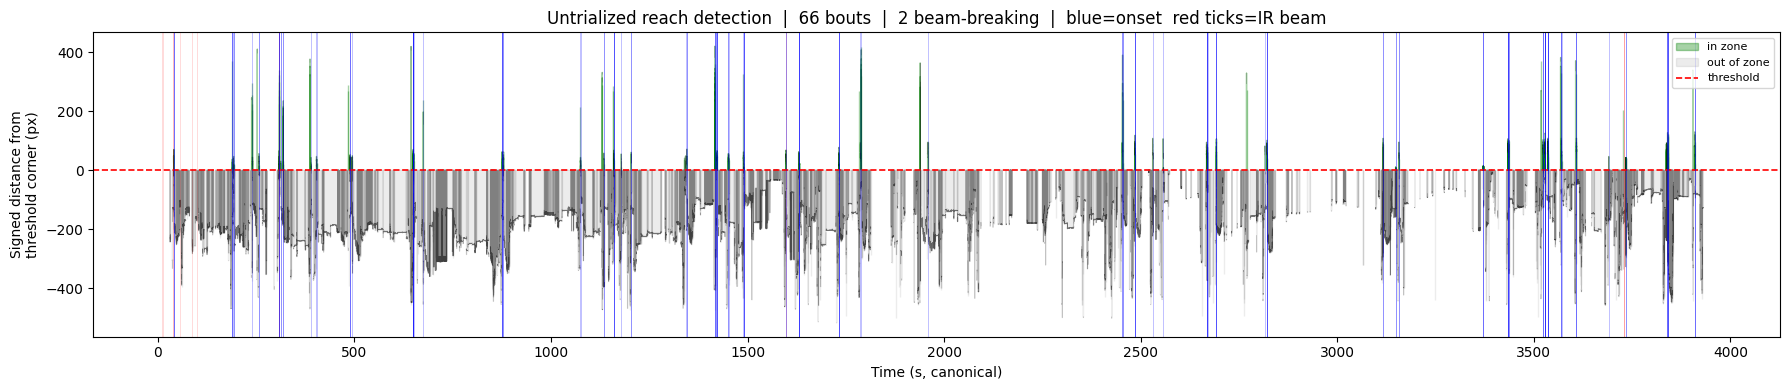

Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\reach_detection_untrialized_overview.png


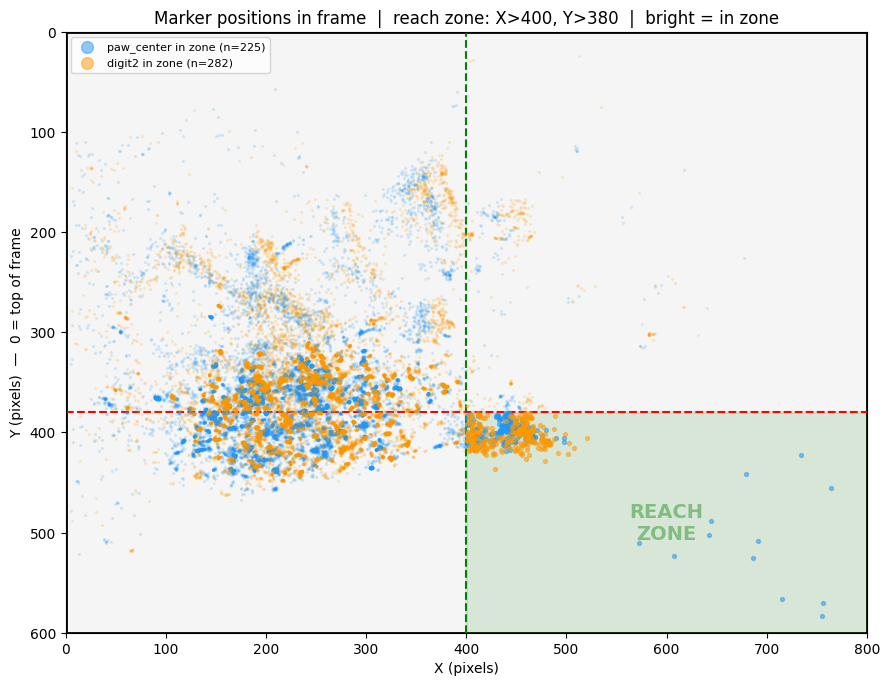

Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\reach_zone_positions_untrialized.png


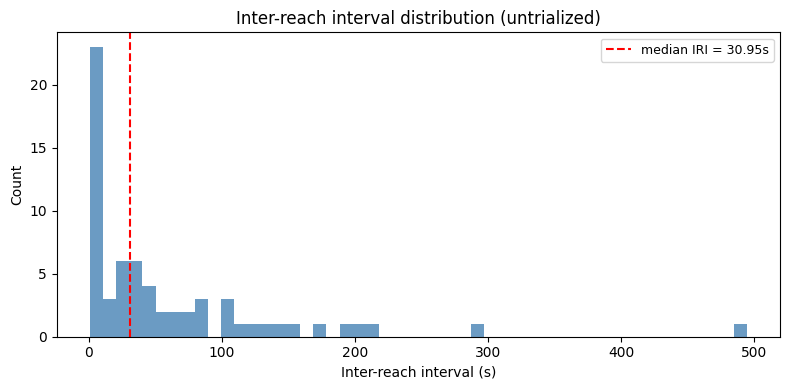

Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\reach_IRI_untrialized.png

===== SUMMARY =====
  Reach zone:          Y > 380  AND  X > 400
  Min frames in zone:  5 (~25ms)
  Total reaches:       163
  Bouts:               66
  Beam-breaking bouts: 1 (1.5%)
  Median IRI:          30.95s

===== CELL J (UNTRIALIZED) COMPLETE =====



In [28]:
# ============================================================
# CELL J (UNTRIALIZED) — REACH DETECTION FROM DLC ONLY
# ============================================================
# No trial structure. Every contiguous in-zone run of
# >= MIN_FRAMES_IN_ZONE frames is a detected reach.
#
# Reach zone: paw_center OR digit2 with
#   x > REACH_X_MIN  AND  y > REACH_Y_MIN
#   AND likelihood >= PAW_LIKELIHOOD_MIN
#
# Saves identical output files to the trial-based Cell J so
# downstream cells (Cell L etc.) work without modification.
# trial_id is set to -1 for all reaches (unused).
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

print("\n===== CELL J (UNTRIALIZED) — DLC REACH DETECTION =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
REACH_Y_MIN        = 380
REACH_X_MIN        = 400
MARKERS            = ["paw_center", "digit2"]
PAW_LIKELIHOOD_MIN = 0.50
MIN_FRAMES_IN_ZONE = 5      # ~25ms at 200Hz
MERGE_WINDOW_S     = 0.8
IR_BEAM_PIN        = 6      # sanity check only
IR_BEAM_TOL_S      = 0.5
FRAME_W            = 800
FRAME_H            = 600
SUBSAMPLE_VIZ      = 20     # subsample factor for scatter plot
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# ------------------------------------------------------------
# LOAD DLC
# ------------------------------------------------------------
dlc      = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
frame_t  = dlc["canonical_time"]
n_frames = len(frame_t)
fps      = 1.0 / float(np.median(np.diff(frame_t)))
print(f"Loaded {n_frames} frames, FPS={fps:.1f}")

available_bps = [k.replace("_x", "") for k in dlc.files if k.endswith("_x")]
print(f"Available bodyparts: {available_bps}")

# ------------------------------------------------------------
# LOAD IR BEAM (sanity check only — not used for detection)
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
beam_t   = np.load(ttls_dir / f"TTL_Pin_{IR_BEAM_PIN}.npy")
print(f"IR beam breaks (pin {IR_BEAM_PIN}): {len(beam_t)}  (sanity check only)")

# ------------------------------------------------------------
# BUILD IN-ZONE MASK
# ------------------------------------------------------------
in_zone     = np.zeros(n_frames, dtype=bool)
marker_data = {}

for bp in MARKERS:
    x_key   = f"{bp}_x"
    y_key   = f"{bp}_y"
    lik_key = f"{bp}_likelihood"

    if x_key not in dlc.files:
        print(f"  WARNING: '{bp}' not in DLC file — skipping.")
        continue

    x   = dlc[x_key].astype(float)
    y   = dlc[y_key].astype(float)
    lik = dlc[lik_key].astype(float)

    good_lik   = lik >= PAW_LIKELIHOOD_MIN
    in_zone_bp = good_lik & (x > REACH_X_MIN) & (y > REACH_Y_MIN)
    in_zone   |= in_zone_bp

    n_in = int(in_zone_bp.sum())
    print(f"  {bp}: {n_in} frames in zone ({100.0*n_in/n_frames:.2f}%)")
    marker_data[bp] = {"x": x, "y": y, "lik": lik, "in_zone": in_zone_bp}

print(f"\nTotal frames in zone (any marker): {in_zone.sum()} "
      f"({100*in_zone.sum()/n_frames:.2f}%)")

# ------------------------------------------------------------
# SIGNED DISTANCE FROM THRESHOLD CORNER (for visualization)
# ------------------------------------------------------------
best_sdist = np.full(n_frames, np.nan)
for bp, d in marker_data.items():
    dx   = d["x"] - REACH_X_MIN
    dy   = d["y"] - REACH_Y_MIN
    dist = np.sqrt(dx**2 + dy**2)
    sign = np.where((d["x"] > REACH_X_MIN) & (d["y"] > REACH_Y_MIN), 1.0, -1.0)
    sd   = dist * sign
    sd[d["lik"] < PAW_LIKELIHOOD_MIN] = np.nan
    better = np.where(
        ~np.isnan(sd) & (np.isnan(best_sdist) | (sd > best_sdist)),
        sd, best_sdist
    )
    best_sdist = better

# ------------------------------------------------------------
# REQUIRE MIN_FRAMES_IN_ZONE CONSECUTIVE FRAMES
# ------------------------------------------------------------
padded = np.concatenate([[False], in_zone, [False]])
diffs  = np.diff(padded.astype(int))
run_starts_raw = np.where(diffs ==  1)[0]
run_ends_raw   = np.where(diffs == -1)[0] - 1

in_zone_filtered = np.zeros(n_frames, dtype=bool)
for rs, re in zip(run_starts_raw, run_ends_raw):
    if (re - rs + 1) >= MIN_FRAMES_IN_ZONE:
        in_zone_filtered[rs : re + 1] = True

padded2 = np.concatenate([[False], in_zone_filtered, [False]])
diffs2  = np.diff(padded2.astype(int))
run_starts = np.where(diffs2 ==  1)[0]
run_ends   = np.where(diffs2 == -1)[0] - 1

print(f"After ≥{MIN_FRAMES_IN_ZONE}-frame filter: "
      f"{in_zone_filtered.sum()} frames in zone, "
      f"{len(run_starts)} separate runs")

# ------------------------------------------------------------
# EXTRACT ONE REACH PER RUN
# ------------------------------------------------------------
reach_onset_t     = []
reach_peak_t      = []
reach_frame_onset = []
reach_frame_peak  = []
reach_max_y       = []

for rs, re in zip(run_starts, run_ends):
    best_y = np.full(re - rs + 1, -np.inf)
    for bp, d in marker_data.items():
        good         = d["lik"][rs:re+1] >= PAW_LIKELIHOOD_MIN
        y_seg_masked = np.where(good, d["y"][rs:re+1], -np.inf)
        best_y       = np.maximum(best_y, y_seg_masked)
    peak_local = int(np.argmax(best_y))
    peak_idx   = rs + peak_local

    reach_onset_t.append(float(frame_t[rs]))
    reach_peak_t.append(float(frame_t[peak_idx]))
    reach_frame_onset.append(int(rs))
    reach_frame_peak.append(int(peak_idx))
    reach_max_y.append(float(best_y[peak_local]))

reach_onset_t     = np.array(reach_onset_t)
reach_peak_t      = np.array(reach_peak_t)
reach_frame_onset = np.array(reach_frame_onset, dtype=int)
reach_frame_peak  = np.array(reach_frame_peak, dtype=int)
reach_max_y       = np.array(reach_max_y)
print(f"Detected reaches: {len(reach_onset_t)}")

# ------------------------------------------------------------
# BOUT CLUSTERING
# ------------------------------------------------------------
if len(reach_onset_t) > 1:
    bout_id = np.zeros(len(reach_onset_t), dtype=int)
    for i in range(1, len(reach_onset_t)):
        if reach_onset_t[i] - reach_peak_t[i-1] <= MERGE_WINDOW_S:
            bout_id[i] = bout_id[i-1]
        else:
            bout_id[i] = bout_id[i-1] + 1
    n_bouts = int(bout_id.max()) + 1
elif len(reach_onset_t) == 1:
    bout_id = np.array([0], dtype=int)
    n_bouts = 1
else:
    bout_id = np.array([], dtype=int)
    n_bouts = 0
print(f"Bouts: {n_bouts}")

# ------------------------------------------------------------
# BEAM TAGGING (sanity check)
# ------------------------------------------------------------
reach_broke_beam = np.zeros(len(reach_peak_t), dtype=bool)
for i, t_pk in enumerate(reach_peak_t):
    if len(beam_t) and np.any(np.abs(beam_t - t_pk) < IR_BEAM_TOL_S):
        reach_broke_beam[i] = True

# ------------------------------------------------------------
# BOUT SUMMARY
# all trial_id = -1 (no trial structure)
# ------------------------------------------------------------
bout_onset_t    = np.zeros(n_bouts)
bout_peak_t     = np.zeros(n_bouts)
bout_max_amp    = np.zeros(n_bouts)
bout_n_reaches  = np.zeros(n_bouts, dtype=int)
bout_trial_id   = np.full(n_bouts, -1, dtype=int)   # always -1
bout_broke_beam = np.zeros(n_bouts, dtype=bool)

for b in range(n_bouts):
    m = bout_id == b
    bout_onset_t[b]    = reach_onset_t[m].min()
    bout_max_amp[b]    = reach_max_y[m].max()
    bout_peak_t[b]     = reach_peak_t[m][np.argmax(reach_max_y[m])]
    bout_n_reaches[b]  = int(m.sum())
    bout_broke_beam[b] = bool(reach_broke_beam[m].any())

# ------------------------------------------------------------
# SAVE — same file names as trial-based Cell J
# ------------------------------------------------------------
out_dir = analysis_folder / "peak_detection"
out_dir.mkdir(exist_ok=True)

np.savez(out_dir / "reaches.npz",
         onset_t=reach_onset_t,
         peak_t=reach_peak_t,
         max_y=reach_max_y,
         frame_onset=reach_frame_onset,
         frame_peak=reach_frame_peak,
         bout_id=bout_id,
         trial_id=np.full(len(reach_onset_t), -1, dtype=int),
         broke_beam=reach_broke_beam)

np.savez(out_dir / "bouts.npz",
         onset_t=bout_onset_t,
         peak_t=bout_peak_t,
         max_amplitude=bout_max_amp,
         n_reaches=bout_n_reaches,
         trial_id=bout_trial_id,
         broke_beam=bout_broke_beam)

np.save(out_dir / "in_zone_mask.npy", in_zone_filtered)

frame_valid = np.zeros(n_frames, dtype=bool)
for bp, d in marker_data.items():
    frame_valid |= d["lik"] >= PAW_LIKELIHOOD_MIN
np.save(out_dir / "frame_valid.npy", frame_valid)

if "paw_center" in marker_data:
    np.save(out_dir / "running_baseline.npy",
            marker_data["paw_center"]["x"].astype(float))
else:
    np.save(out_dir / "running_baseline.npy",
            marker_data[list(marker_data.keys())[0]]["x"].astype(float))

import json as _json
meta = {
    "method":             "absolute_pixel_threshold_untrialized",
    "reach_y_min":        int(REACH_Y_MIN),
    "reach_x_min":        int(REACH_X_MIN),
    "markers":            MARKERS,
    "likelihood_min":     float(PAW_LIKELIHOOD_MIN),
    "min_frames_in_zone": int(MIN_FRAMES_IN_ZONE),
    "merge_window_s":     float(MERGE_WINDOW_S),
    "trial_structure":    "none",
    "n_reaches":          int(len(reach_onset_t)),
    "n_bouts":            int(n_bouts),
    "n_beam_breaking":    int(reach_broke_beam.sum()),
    "beam_breaking_frac": float(reach_broke_beam.mean()) if len(reach_broke_beam) else 0.0,
}
with open(out_dir / "reaches_meta.json", "w") as f:
    _json.dump(meta, f, indent=2)

print(f"\nSaved reaches → {out_dir / 'reaches.npz'}")
print(f"Saved bouts   → {out_dir / 'bouts.npz'}")

# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------
def fmt_time(t):
    return f"{int(t//60)}m{t%60:.1f}s"

# ------------------------------------------------------------
# PLOT 1: full session signed distance
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 4))

ax.fill_between(frame_t, best_sdist, 0,
                where=(~np.isnan(best_sdist)) & (best_sdist >= 0),
                color="green", alpha=0.35, label="in zone")
ax.fill_between(frame_t, best_sdist, 0,
                where=(~np.isnan(best_sdist)) & (best_sdist < 0),
                color="gray", alpha=0.15, label="out of zone")
ax.plot(frame_t, best_sdist, lw=0.25, color="black", alpha=0.5)
ax.axhline(0, color="red", lw=1.2, linestyle="--", label="threshold")

for t in reach_onset_t:
    ax.axvline(t, color="blue", alpha=0.35, lw=0.5)
for bt in beam_t:
    ax.axvline(bt, color="red", alpha=0.20, lw=0.5)

ax.set_ylabel("Signed distance from\nthreshold corner (px)")
ax.set_xlabel("Time (s, canonical)")
ax.set_title(
    f"Untrialized reach detection  |  {n_bouts} bouts  |  "
    f"{reach_broke_beam.sum()} beam-breaking  |  "
    f"blue=onset  red ticks=IR beam"
)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
out_path = analysis_folder / "qc" / "reach_detection_untrialized_overview.png"
fig.savefig(out_path, dpi=150)
plt.show()
print(f"Saved → {out_path}")

# ------------------------------------------------------------
# PLOT 2: scatter of all marker positions in frame space
# colored by in-zone vs out-of-zone
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))

frame_rect = mpatches.Rectangle(
    (0, 0), FRAME_W, FRAME_H,
    lw=2, edgecolor="black", facecolor="#f5f5f5", zorder=0
)
ax.add_patch(frame_rect)

zone_rect = mpatches.Rectangle(
    (REACH_X_MIN, REACH_Y_MIN),
    FRAME_W - REACH_X_MIN, FRAME_H - REACH_Y_MIN,
    lw=2, edgecolor="green", facecolor="green",
    alpha=0.12, zorder=1
)
ax.add_patch(zone_rect)

ax.axvline(REACH_X_MIN, color="green", lw=1.5, linestyle="--")
ax.axhline(REACH_Y_MIN, color="red",   lw=1.5, linestyle="--")

colors_bp = {"paw_center": "#2196F3", "digit2": "#FF9800"}
idx_sub   = np.arange(0, n_frames, SUBSAMPLE_VIZ)

for bp in MARKERS:
    if bp not in marker_data:
        continue
    d   = marker_data[bp]
    x_s = d["x"][idx_sub]
    y_s = d["y"][idx_sub]
    l_s = d["lik"][idx_sub]
    good = l_s >= PAW_LIKELIHOOD_MIN
    in_z = good & (x_s > REACH_X_MIN) & (y_s > REACH_Y_MIN)
    out_z = good & ~in_z

    ax.scatter(x_s[out_z], y_s[out_z], s=2, alpha=0.12,
               color=colors_bp.get(bp, "gray"), zorder=2)
    ax.scatter(x_s[in_z], y_s[in_z], s=8, alpha=0.5,
               color=colors_bp.get(bp, "gray"), zorder=3,
               label=f"{bp} in zone (n={in_z.sum()})")

ax.text(REACH_X_MIN + (FRAME_W - REACH_X_MIN)/2,
        REACH_Y_MIN + (FRAME_H - REACH_Y_MIN)/2,
        "REACH\nZONE", ha="center", va="center",
        fontsize=14, color="green", fontweight="bold", alpha=0.4)

ax.set_xlim(0, FRAME_W)
ax.set_ylim(0, FRAME_H)
ax.invert_yaxis()
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)  —  0 = top of frame")
ax.set_title(
    f"Marker positions in frame  |  "
    f"reach zone: X>{REACH_X_MIN}, Y>{REACH_Y_MIN}  |  "
    f"bright = in zone"
)
ax.legend(fontsize=8, loc="upper left", markerscale=3)
ax.set_aspect("equal")
plt.tight_layout()
out_path2 = analysis_folder / "qc" / "reach_zone_positions_untrialized.png"
fig.savefig(out_path2, dpi=200)
plt.show()
print(f"Saved → {out_path2}")

# ------------------------------------------------------------
# PLOT 3: inter-reach interval distribution
# ------------------------------------------------------------
if n_bouts > 1:
    iris = np.diff(bout_onset_t)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(iris, bins=50, color="steelblue", alpha=0.8)
    ax.axvline(np.median(iris), color="red", lw=1.5, linestyle="--",
               label=f"median IRI = {np.median(iris):.2f}s")
    ax.set_xlabel("Inter-reach interval (s)")
    ax.set_ylabel("Count")
    ax.set_title("Inter-reach interval distribution (untrialized)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    out_path3 = analysis_folder / "qc" / "reach_IRI_untrialized.png"
    fig.savefig(out_path3, dpi=150)
    plt.show()
    print(f"Saved → {out_path3}")

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
print("\n===== SUMMARY =====")
print(f"  Reach zone:          Y > {REACH_Y_MIN}  AND  X > {REACH_X_MIN}")
print(f"  Min frames in zone:  {MIN_FRAMES_IN_ZONE} (~{1000*MIN_FRAMES_IN_ZONE/fps:.0f}ms)")
print(f"  Total reaches:       {len(reach_onset_t)}")
print(f"  Bouts:               {n_bouts}")
print(f"  Beam-breaking bouts: {bout_broke_beam.sum()} "
      f"({100*bout_broke_beam.mean():.1f}%)")
if n_bouts > 1:
    print(f"  Median IRI:          {np.median(np.diff(bout_onset_t)):.2f}s")
print("\n===== CELL J (UNTRIALIZED) COMPLETE =====\n")

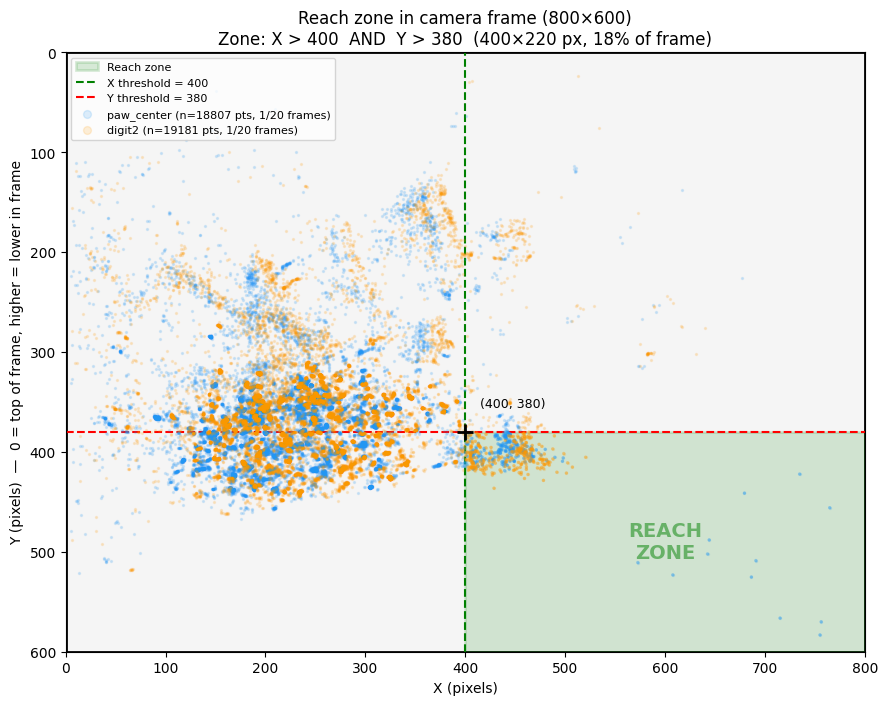

Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\reach_zone_frame.png


In [27]:
# ============================================================
# REACH ZONE VISUALIZER
# Shows where the threshold square sits in the camera frame.
# Scatter all valid paw_center and digit2 positions on top.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ------------------------------------------------------------
# USER EDIT — must match Cell J
# ------------------------------------------------------------
REACH_X_MIN        = 400
REACH_Y_MIN        = 380
FRAME_W            = 800
FRAME_H            = 600
PAW_LIKELIHOOD_MIN = 0.50
MARKERS            = ["paw_center", "digit2"]

# Subsample for speed — plot every Nth frame
SUBSAMPLE = 20
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

dlc     = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
frame_t = dlc["canonical_time"]
n_frames = len(frame_t)

fig, ax = plt.subplots(figsize=(9, 7))

# Draw frame boundary
frame_rect = mpatches.Rectangle(
    (0, 0), FRAME_W, FRAME_H,
    linewidth=2, edgecolor="black", facecolor="#f5f5f5", zorder=0
)
ax.add_patch(frame_rect)

# Draw reach zone (top-right quadrant from threshold corner)
zone_w = FRAME_W - REACH_X_MIN
zone_h = FRAME_H - REACH_Y_MIN
zone_rect = mpatches.Rectangle(
    (REACH_X_MIN, REACH_Y_MIN), zone_w, zone_h,
    linewidth=2, edgecolor="green", facecolor="green",
    alpha=0.15, zorder=1, label="Reach zone"
)
ax.add_patch(zone_rect)

# Threshold lines
ax.axvline(REACH_X_MIN, color="green", lw=1.5, linestyle="--", zorder=2,
           label=f"X threshold = {REACH_X_MIN}")
ax.axhline(REACH_Y_MIN, color="red",   lw=1.5, linestyle="--", zorder=2,
           label=f"Y threshold = {REACH_Y_MIN}")

# Threshold corner marker
ax.scatter(REACH_X_MIN, REACH_Y_MIN, s=120, color="black",
           zorder=5, marker="+", linewidths=2)
ax.annotate(f"({REACH_X_MIN}, {REACH_Y_MIN})",
            (REACH_X_MIN, REACH_Y_MIN),
            xytext=(REACH_X_MIN + 15, REACH_Y_MIN - 25),
            fontsize=9, color="black")

# Scatter marker positions (subsampled)
colors_bp = {"paw_center": "#2196F3", "digit2": "#FF9800"}
idx_sub   = np.arange(0, n_frames, SUBSAMPLE)

for bp in MARKERS:
    x_key   = f"{bp}_x"
    y_key   = f"{bp}_y"
    lik_key = f"{bp}_likelihood"
    if x_key not in dlc.files:
        continue
    x   = dlc[x_key][idx_sub].astype(float)
    y   = dlc[y_key][idx_sub].astype(float)
    lik = dlc[lik_key][idx_sub].astype(float)
    good = lik >= PAW_LIKELIHOOD_MIN
    ax.scatter(x[good], y[good], s=2, alpha=0.15,
               color=colors_bp.get(bp, "gray"),
               label=f"{bp} (n={good.sum()} pts, 1/{SUBSAMPLE} frames)",
               zorder=3)
    # Highlight in-zone points
    in_z = good & (x > REACH_X_MIN) & (y > REACH_Y_MIN)
    if in_z.any():
        ax.scatter(x[in_z], y[in_z], s=6, alpha=0.4,
                   color=colors_bp.get(bp, "gray"),
                   edgecolors="none", zorder=4)

# Zone label
ax.text(REACH_X_MIN + zone_w / 2, REACH_Y_MIN + zone_h / 2,
        "REACH\nZONE", ha="center", va="center",
        fontsize=14, color="green", fontweight="bold",
        alpha=0.5, zorder=2)

ax.set_xlim(0, FRAME_W)
ax.set_ylim(0, FRAME_H)
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)  —  0 = top of frame, higher = lower in frame")
ax.set_title(
    f"Reach zone in camera frame ({FRAME_W}×{FRAME_H})\n"
    f"Zone: X > {REACH_X_MIN}  AND  Y > {REACH_Y_MIN}  "
    f"({zone_w}×{zone_h} px, "
    f"{100*zone_w*zone_h/(FRAME_W*FRAME_H):.0f}% of frame)"
)
ax.legend(fontsize=8, loc="upper left", markerscale=4)
ax.set_aspect("equal")
ax.invert_yaxis()   # match image convention: y=0 at top

plt.tight_layout()
out_path = analysis_folder / "qc" / "reach_zone_frame.png"
plt.savefig(out_path, dpi=200)
plt.show()
print(f"Saved → {out_path}")


===== CELL L v4 (UNTRIALIZED) — REACH-LOCKED PETH (CFA vs VAL) =====
All bouts: 66 events
Time range: 40.04 → 3908.54 s
Eligible units: 174  (CFA=78, VAL=37, WM=59)

Building null (200 shuffles)...
  50/200
  100/200
  150/200
  200/200
Calibrated Z threshold: 2.75  (shuffled FPR = 6.6%)

Computing real PSTHs (66 events)...
Modulated: 125 / 174
  CFA: 58 / 78
  VAL: 23 / 37


C:\Users\kkost\AppData\Local\Temp\ipykernel_5936\3914917478.py:355: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


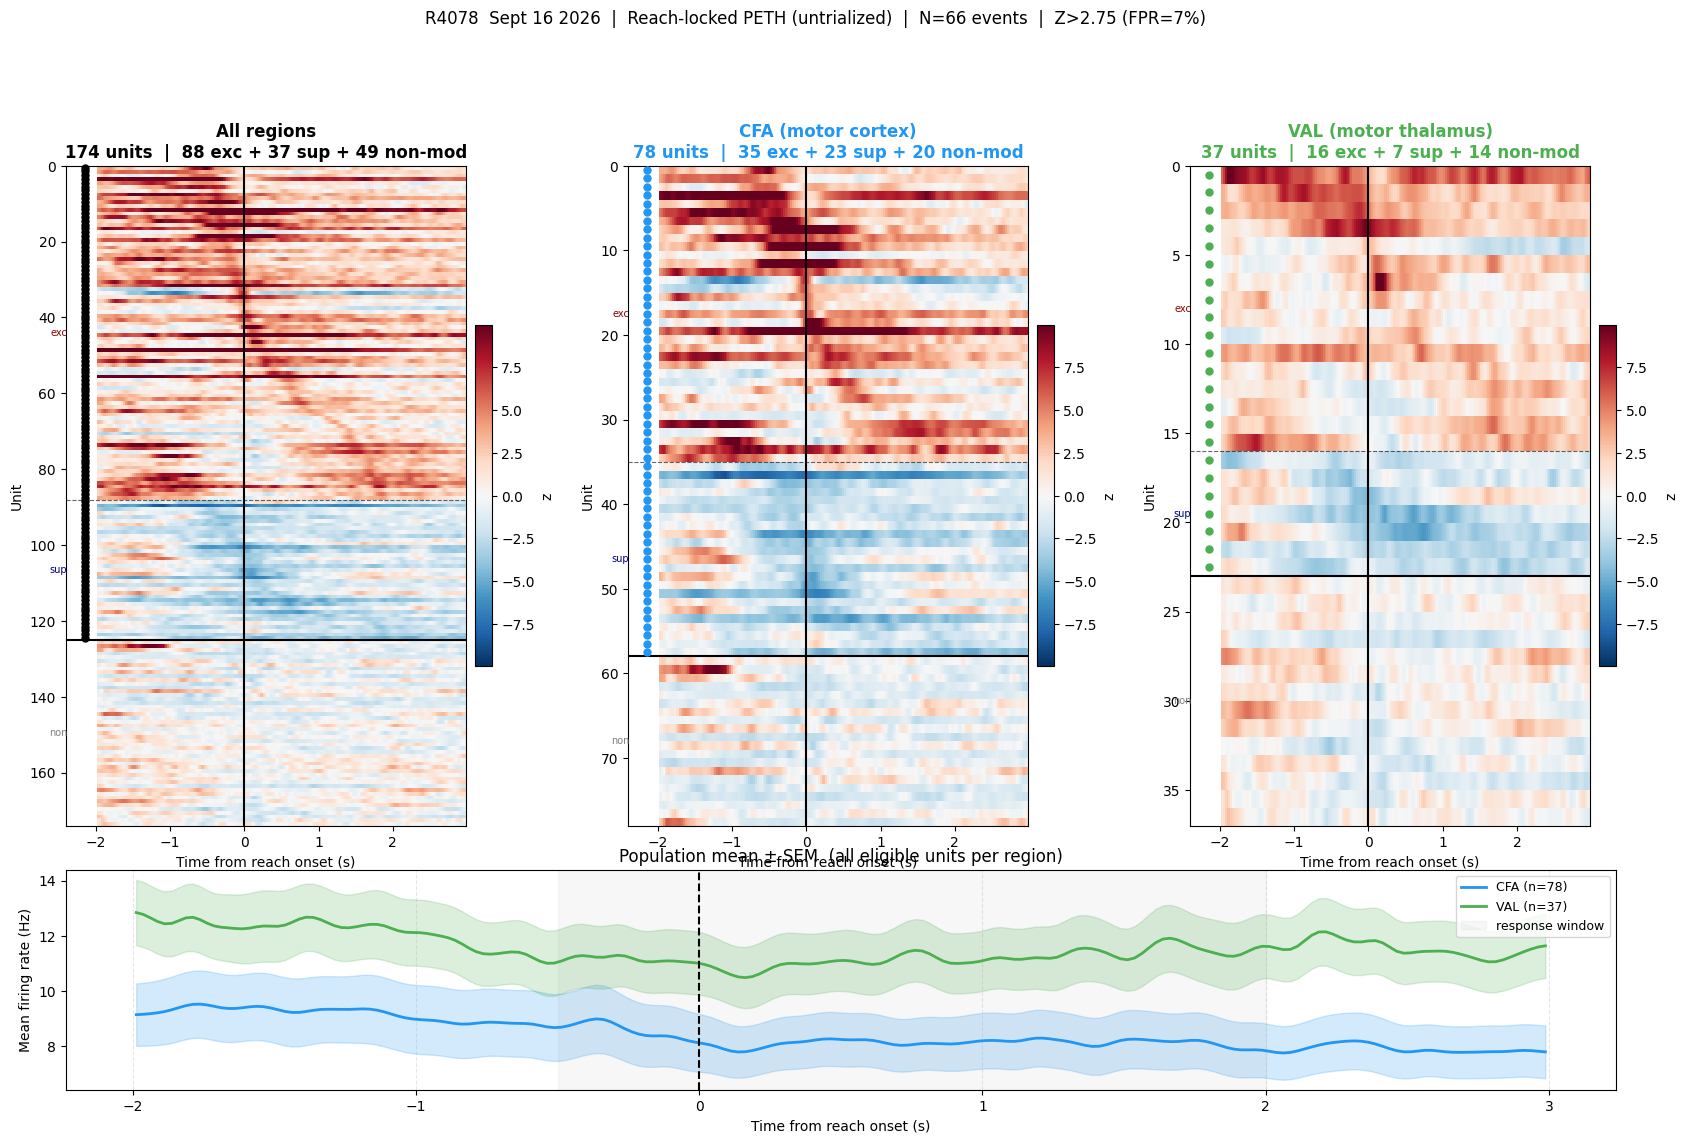


Saved → G:\Neuropixels data-motor project\freely moving\2026-09-16_13-21-12\Record Node 101\2026-09-16_13-21-12_experiment2_recording1_analysis\qc\reach_PETH_CFA_VAL_untrialized_v4.png
Saved arrays → reach_good_untrialized_arrays.npz

===== SUMMARY =====
  N reach events:            66
  Eligible units:            174
    CFA:                     78
    VAL:                     37
  Z threshold:               2.75
  Shuffled FPR:              6.6%
  Modulated CFA:             58 / 78
    excited:                 35
    suppressed:              23
  Modulated VAL:             23 / 37
    excited:                 16
    suppressed:              7

===== CELL L v4 (UNTRIALIZED) COMPLETE =====



In [30]:
# ============================================================
# CELL L — REACH-LOCKED PETH WITH REGION SPLIT (PORTABLE) v4
# ============================================================
# Sort order per panel:
#   1. Excited modulated units — sorted by peak latency (earliest first)
#   2. Suppressed modulated units — sorted by peak latency
#   3. Non-modulated units — sorted by depth (surface → deep)
#
# Dashed line between excited/suppressed.
# Solid line between modulated/non-modulated.
#
# Subset: all detected bouts (untrialized — use with Cell J untrialized).
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL L v4 (UNTRIALIZED) — REACH-LOCKED PETH (CFA vs VAL) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
PROBEA_PATH = (
    r"G:\Neuropixels data-motor project\freely moving"
    r"\2026-09-16_13-21-12\Record Node 101"
    r"\experiment2\recording1\continuous"
    r"\Neuropix-PXI-100.ProbeA-AP\kilosort4"
)

WIN_PRE            = 2.0
WIN_POST           = 3.0
RESPONSE_WIN       = (-0.5, 2.0)
BIN_SIZE           = 0.025
SMOOTH_SIGMA_BINS  = 2
MIN_CONSECUTIVE_MS = 80
MIN_BASELINE_HZ    = 0.5
N_SHUFFLES_CALIB   = 200
TARGET_FPR         = 0.10
RANDOM_SEED        = 42

TIP_DV_UM = 5429.0
REGION_BOUNDS = {
    "CFA": (0,    1300),
    "WM":  (1300, 3500),
    "VAL": (3500, 4500),
}
REGION_COLORS = {"CFA": "#2196F3", "VAL": "#4CAF50", "WM": "#9E9E9E"}

EXCLUDE_UNITS = [130, 343]
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD REGION ASSIGNMENTS
# ------------------------------------------------------------
ci = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
good_ci = ci[ci["group"].str.lower() == "good"].copy()
good_ci["dv_depth"] = TIP_DV_UM - good_ci["depth"].astype(float)

def get_region(dv):
    for name, (lo, hi) in REGION_BOUNDS.items():
        if lo <= dv < hi:
            return name
    return "deep"

good_ci["region"] = good_ci["dv_depth"].apply(get_region)
uid_to_region = dict(zip(good_ci["id"].astype(int), good_ci["region"]))
uid_to_dv     = dict(zip(good_ci["id"].astype(int), good_ci["dv_depth"]))

# ------------------------------------------------------------
# LOAD ALL BOUTS — no trial filter
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
event_times = np.sort(bouts["onset_t"])
n_events    = len(event_times)
print(f"All bouts: {n_events} events")
print(f"Time range: {event_times[0]:.2f} → {event_times[-1]:.2f} s")
if n_events < 5:
    raise RuntimeError(f"Too few events ({n_events}) — check Cell J output.")

# ------------------------------------------------------------
# LOAD UNITS + ASSIGN REGIONS
# ------------------------------------------------------------
good_units_all = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir     = analysis_folder / "spikes"

all_spikes  = {}
unit_dv     = {}
unit_region = {}

for u in good_units_all:
    uid = int(u)
    if uid in EXCLUDE_UNITS:
        continue
    spk_path = spikes_dir / f"unit_{uid}.npy"
    if not spk_path.exists():
        continue
    spk  = np.load(spk_path)
    rate = len(spk) / recording_duration
    if rate < MIN_BASELINE_HZ:
        continue
    all_spikes[uid]  = spk
    unit_region[uid] = uid_to_region.get(uid, "deep")
    unit_dv[uid]     = uid_to_dv.get(uid, 9999.0)

eligible_units = np.array(sorted(all_spikes.keys()))
eligible_units = eligible_units[
    np.argsort([unit_dv.get(u, 9999) for u in eligible_units])
]

cfa_mask = np.array([unit_region.get(int(u)) == "CFA" for u in eligible_units])
val_mask = np.array([unit_region.get(int(u)) == "VAL" for u in eligible_units])
wm_mask  = np.array([unit_region.get(int(u)) == "WM"  for u in eligible_units])

n_cfa = int(cfa_mask.sum())
n_val = int(val_mask.sum())
print(f"Eligible units: {len(eligible_units)}  "
      f"(CFA={n_cfa}, VAL={n_val}, WM={int(wm_mask.sum())})")

# ------------------------------------------------------------
# PSTH HELPERS
# ------------------------------------------------------------
edges   = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins  = len(centers)
response_mask   = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))
rng = np.random.default_rng(RANDOM_SEED)

def compute_psth_mean(events):
    out = np.zeros((len(eligible_units), n_bins))
    for u_i, u in enumerate(eligible_units):
        spk   = all_spikes[int(u)]
        h_sum = np.zeros(n_bins)
        for t_evt in events:
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            h_sum += h / BIN_SIZE
        out[u_i] = h_sum / len(events)
    return gaussian_filter1d(out, sigma=SMOOTH_SIGMA_BINS, axis=1)

def count_modulated(z_mat, z_thresh):
    z_r = z_mat[:, response_mask]
    out = np.zeros(len(eligible_units), dtype=bool)
    for i in range(len(eligible_units)):
        for arr in (z_r[i] > z_thresh, z_r[i] < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            d = np.diff(padded.astype(int))
            s = np.where(d ==  1)[0]
            e = np.where(d == -1)[0]
            if (e - s).max() >= min_consec_bins:
                out[i] = True
                break
    return out

# ------------------------------------------------------------
# NULL DISTRIBUTION
# ------------------------------------------------------------
print(f"\nBuilding null ({N_SHUFFLES_CALIB} shuffles)...")
t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0
shuffled_psths = np.zeros((N_SHUFFLES_CALIB, len(eligible_units), n_bins))

for s in range(N_SHUFFLES_CALIB):
    fake = np.sort(rng.uniform(t_min, t_max, size=n_events))
    shuffled_psths[s] = compute_psth_mean(fake)
    if (s + 1) % 50 == 0:
        print(f"  {s+1}/{N_SHUFFLES_CALIB}")

null_mean = shuffled_psths.mean(axis=0)
null_std  = shuffled_psths.std(axis=0)
null_std  = np.maximum(null_std, null_mean * 0.01 + 0.05)

# ------------------------------------------------------------
# CALIBRATE Z THRESHOLD
# ------------------------------------------------------------
z_thresh_grid = np.arange(1.5, 5.01, 0.25)
shuffled_fpr  = np.zeros((N_SHUFFLES_CALIB, len(z_thresh_grid)))
for s in range(N_SHUFFLES_CALIB):
    z_s = (shuffled_psths[s] - null_mean) / null_std
    for j, thr in enumerate(z_thresh_grid):
        shuffled_fpr[s, j] = count_modulated(z_s, thr).mean()

mean_fpr = shuffled_fpr.mean(axis=0)
viable   = np.where(mean_fpr <= TARGET_FPR)[0]
z_thresh = float(z_thresh_grid[viable[0]] if len(viable) else z_thresh_grid[-1])
calibrated_fpr = float(mean_fpr[np.argmin(np.abs(z_thresh_grid - z_thresh))])
print(f"Calibrated Z threshold: {z_thresh:.2f}  "
      f"(shuffled FPR = {calibrated_fpr*100:.1f}%)")

# ------------------------------------------------------------
# REAL PSTHs + Z-SCORE
# ------------------------------------------------------------
print(f"\nComputing real PSTHs ({n_events} events)...")
real_psth = compute_psth_mean(event_times)
real_z    = (real_psth - null_mean) / null_std

modulated = count_modulated(real_z, z_thresh)

z_resp   = real_z[:, response_mask]
peak_idx = np.argmax(np.abs(z_resp), axis=1)
peak_lat = centers[response_mask][peak_idx]
peak_z   = z_resp[np.arange(len(eligible_units)), peak_idx]

print(f"Modulated: {modulated.sum()} / {len(eligible_units)}")
print(f"  CFA: {(modulated & cfa_mask).sum()} / {n_cfa}")
print(f"  VAL: {(modulated & val_mask).sum()} / {n_val}")

# ------------------------------------------------------------
# SORT: excited (by latency) → suppressed (by latency) → non-mod (by depth)
# ------------------------------------------------------------
def make_sort_order(unit_mask):
    idx = np.where(unit_mask)[0]

    exc_local    = np.where( modulated[idx] & (peak_z[idx] > 0))[0]
    sup_local    = np.where( modulated[idx] & (peak_z[idx] <= 0))[0]
    nonmod_local = np.where(~modulated[idx])[0]

    resp_ctrs = centers[response_mask]

    if len(exc_local) > 0:
        lat_exc   = resp_ctrs[np.argmax(np.abs(z_resp[idx[exc_local]]), axis=1)]
        exc_order = exc_local[np.argsort(lat_exc)]
    else:
        exc_order = exc_local

    if len(sup_local) > 0:
        lat_sup   = resp_ctrs[np.argmax(np.abs(z_resp[idx[sup_local]]), axis=1)]
        sup_order = sup_local[np.argsort(lat_sup)]
    else:
        sup_order = sup_local

    final_local = np.concatenate([exc_order, sup_order, nonmod_local])
    return idx[final_local], len(exc_order), len(sup_order)

# ------------------------------------------------------------
# DRAW HEATMAP
# ------------------------------------------------------------
vmax = max(3.0, float(np.percentile(np.abs(real_z), 98)))

def draw_heatmap(ax, unit_mask, title, color, region_label):
    if unit_mask.sum() == 0:
        ax.text(0.5, 0.5, f"No {region_label} units",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    final_idx, n_exc, n_sup = make_sort_order(unit_mask)
    n_mod   = n_exc + n_sup
    n_total = len(final_idx)
    z_sub   = real_z[final_idx]

    im = ax.imshow(z_sub, aspect="auto",
                   extent=[centers[0], centers[-1], n_total, 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.5)

    if n_exc > 0 and n_sup > 0:
        ax.axhline(n_exc, color="black", lw=0.8, linestyle="--", alpha=0.6)
    if 0 < n_mod < n_total:
        ax.axhline(n_mod, color="black", lw=1.5)

    if n_mod > 0:
        ax.scatter(
            np.full(n_mod, centers[0] - WIN_PRE * 0.08),
            np.arange(n_mod) + 0.5,
            s=25, color=color, marker="o", zorder=5, clip_on=False
        )

    if n_exc > 0:
        ax.text(centers[0] - WIN_PRE * 0.20, n_exc / 2,
                "exc", fontsize=7, va="center", ha="right",
                color="darkred", clip_on=False)
    if n_sup > 0:
        ax.text(centers[0] - WIN_PRE * 0.20, n_exc + n_sup / 2,
                "sup", fontsize=7, va="center", ha="right",
                color="darkblue", clip_on=False)
    if n_total - n_mod > 0:
        ax.text(centers[0] - WIN_PRE * 0.20, n_mod + (n_total - n_mod) / 2,
                "non", fontsize=7, va="center", ha="right",
                color="gray", clip_on=False)

    ax.set_xlabel("Time from reach onset (s)")
    ax.set_ylabel("Unit")
    ax.set_title(
        f"{title}\n"
        f"{n_total} units  |  "
        f"{n_exc} exc + {n_sup} sup + {n_total-n_mod} non-mod",
        color=color, fontweight="bold"
    )
    plt.colorbar(im, ax=ax, label="z", fraction=0.04, pad=0.02)

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, height_ratios=[3, 1],
                       hspace=0.10, wspace=0.32)

ax_all = fig.add_subplot(gs[0, 0])
ax_cfa = fig.add_subplot(gs[0, 1])
ax_val = fig.add_subplot(gs[0, 2])
ax_pop = fig.add_subplot(gs[1, :])

draw_heatmap(ax_all, np.ones(len(eligible_units), dtype=bool),
             "All regions", "black", "any")
draw_heatmap(ax_cfa, cfa_mask,
             "CFA (motor cortex)", REGION_COLORS["CFA"], "CFA")
draw_heatmap(ax_val, val_mask,
             "VAL (motor thalamus)", REGION_COLORS["VAL"], "VAL")

def mean_sem(mask):
    sub = real_psth[mask]
    m   = sub.mean(axis=0)
    s   = sub.std(axis=0) / max(np.sqrt(mask.sum()), 1)
    return m, s

for mask, label, color in [
    (cfa_mask, f"CFA (n={n_cfa})", REGION_COLORS["CFA"]),
    (val_mask, f"VAL (n={n_val})", REGION_COLORS["VAL"]),
]:
    if mask.sum() == 0:
        continue
    m, s = mean_sem(mask)
    ax_pop.plot(centers, m, color=color, lw=2.0, label=label)
    ax_pop.fill_between(centers, m - s, m + s, color=color, alpha=0.20)

ax_pop.axvline(0, color="black", lw=1.5, linestyle="--")
ax_pop.axvspan(RESPONSE_WIN[0], RESPONSE_WIN[1],
               alpha=0.06, color="gray", label="response window")
ax_pop.set_xlabel("Time from reach onset (s)")
ax_pop.set_ylabel("Mean firing rate (Hz)")
ax_pop.set_title("Population mean ± SEM  (all eligible units per region)")
ax_pop.legend(fontsize=9, loc="upper right")
ax_pop.grid(True, axis="x", linestyle="--", alpha=0.3)

fig.suptitle(
    f"R4078  Sept 16 2026  |  Reach-locked PETH (untrialized)  |  "
    f"N={n_events} events  |  "
    f"Z>{z_thresh:.2f} (FPR={calibrated_fpr*100:.0f}%)",
    fontsize=12, y=1.01
)
plt.tight_layout()

out_path = analysis_folder / "qc" / "reach_PETH_CFA_VAL_untrialized_v4.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"reach_PETH_CFA_VAL_untrialized_v4_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE ARRAYS
# ------------------------------------------------------------
out_dir = analysis_folder / "qc"
np.savez(out_dir / "reach_good_untrialized_arrays.npz",
         units=eligible_units,
         z_mean=real_z,
         modulated=modulated,
         peak_latency=peak_lat,
         peak_z=peak_z,
         centers=centers,
         cfa_mask=cfa_mask,
         val_mask=val_mask,
         wm_mask=wm_mask,
         z_threshold=z_thresh,
         event_times=event_times,
         null_mean=null_mean,
         null_std=null_std)

print("Saved arrays → reach_good_untrialized_arrays.npz")

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
print("\n===== SUMMARY =====")
print(f"  N reach events:            {n_events}")
print(f"  Eligible units:            {len(eligible_units)}")
print(f"    CFA:                     {n_cfa}")
print(f"    VAL:                     {n_val}")
print(f"  Z threshold:               {z_thresh:.2f}")
print(f"  Shuffled FPR:              {calibrated_fpr*100:.1f}%")
print(f"  Modulated CFA:             {(modulated & cfa_mask).sum()} / {n_cfa}")
print(f"    excited:                 {(modulated & cfa_mask & (peak_z > 0)).sum()}")
print(f"    suppressed:              {(modulated & cfa_mask & (peak_z <= 0)).sum()}")
print(f"  Modulated VAL:             {(modulated & val_mask).sum()} / {n_val}")
print(f"    excited:                 {(modulated & val_mask & (peak_z > 0)).sum()}")
print(f"    suppressed:              {(modulated & val_mask & (peak_z <= 0)).sum()}")
print("\n===== CELL L v4 (UNTRIALIZED) COMPLETE =====\n")